## FashionPulse AI — Sales Trends, Customer Behavior & Predictive Intelligence

# 1. Install the required libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost lightgbm joblib openpyxl

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# FASHIONPULSE AI
# MASTER LIBRARY IMPORTS
# ============================================================

# -------------------------
# 1. Core Python Libraries
# -------------------------
import os
import sys
import warnings
import json
import joblib

warnings.filterwarnings("ignore")

# -------------------------
# 2. Data Manipulation
# -------------------------
import numpy as np
import pandas as pd

# -------------------------
# 3. Visualization
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 4. Statistical Analysis
# -------------------------
from scipy import stats

# -------------------------
# 5. Scikit-Learn
# -------------------------
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder,
    MinMaxScaler
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

# Regression
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

# Classification
from sklearn.linear_model import LogisticRegression

# Clustering
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    silhouette_score
)

# Model interpretation
from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# -------------------------
# 6. XGBoost
# -------------------------
from xgboost import (
    XGBRegressor,
    XGBClassifier
)

# -------------------------
# 7. LightGBM
# -------------------------
from lightgbm import (
    LGBMRegressor,
    LGBMClassifier
)

# -------------------------
# 8. Display Settings
# -------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# -------------------------
# 9. Project Information
# -------------------------
print("=" * 70)
print("🚀 FASHIONPULSE AI")
print("=" * 70)

print("Python Version :", sys.version.split()[0])
print("Pandas Version :", pd.__version__)
print("NumPy Version  :", np.__version__)

try:
    import sklearn
    print("Scikit-Learn   :", sklearn.__version__)
except:
    print("Scikit-Learn   : Loaded")

try:
    import xgboost
    print("XGBoost         :", xgboost.__version__)
except:
    print("XGBoost         : Not Available")

try:
    import lightgbm
    print("LightGBM        :", lightgbm.__version__)
except:
    print("LightGBM        : Not Available")

print("=" * 70)
print("✅ All major libraries imported successfully!")
print("=" * 70)


🚀 FASHIONPULSE AI
Python Version : 3.13.9
Pandas Version : 2.3.3
NumPy Version  : 2.3.5
Scikit-Learn   : 1.7.2
XGBoost         : 3.4.1
LightGBM        : 4.7.0
✅ All major libraries imported successfully!


# Step 2: Data Loading & Initial Audit for FashionPulse AI

Cell 2 — Load the dataset

In [3]:
# ============================================================
# FASHIONPULSE AI — STEP 2
# LOAD DATASET
# ============================================================

DATA_PATH = "women_clothing_50k.csv"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

df.head()

DATASET LOADED SUCCESSFULLY
Rows    : 50,000
Columns : 15


,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07


Cell 3 — Dataset structure

In [4]:
# ============================================================
# DATASET STRUCTURE
# ============================================================

print("Column Names:")
print("-" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")

print("\nDataset Shape:", df.shape)

Column Names:
--------------------------------------------------
 1. product_id
 2. category
 3. subcategory
 4. material
 5. color
 6. size
 7. season
 8. style
 9. price_usd
10. discount_percent
11. rating
12. review_count
13. stock_quantity
14. units_sold
15. return_rate

Dataset Shape: (50000, 15)


Cell 4 — Data types

In [5]:
# ============================================================
# DATA TYPES
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        50000 non-null  object 
 1   category          50000 non-null  object 
 2   subcategory       50000 non-null  object 
 3   material          50000 non-null  object 
 4   color             50000 non-null  object 
 5   size              50000 non-null  object 
 6   season            50000 non-null  object 
 7   style             50000 non-null  object 
 8   price_usd         50000 non-null  float64
 9   discount_percent  50000 non-null  int64  
 10  rating            50000 non-null  float64
 11  review_count      50000 non-null  int64  
 12  stock_quantity    50000 non-null  int64  
 13  units_sold        50000 non-null  int64  
 14  return_rate       50000 non-null  float64
dtypes: float64(3), int64(4), object(8)
memory usage: 5.7+ MB


Cell 5 — Missing-value audit

In [6]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing_Count",
    ascending=False
)

missing

,Missing_Count,Missing_Percentage
product_id,0,0.0
category,0,0.0
subcategory,0,0.0
material,0,0.0
color,0,0.0
size,0,0.0
season,0,0.0
style,0,0.0
price_usd,0,0.0
discount_percent,0,0.0


Cell 6 — Duplicate audit

In [7]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)
print("Duplicate Percentage :", round(
    duplicate_count / len(df) * 100, 2
), "%")

Total Duplicate Rows: 0
Duplicate Percentage : 0.0 %


Cell 7 — Unique-value analysis

In [8]:
# ============================================================
# UNIQUE VALUE ANALYSIS
# ============================================================

unique_summary = pd.DataFrame({
    "Column": df.columns,
    "Unique_Values": [df[col].nunique() for col in df.columns],
    "Data_Type": [df[col].dtype for col in df.columns]
})

unique_summary

,Column,Unique_Values,Data_Type
0,product_id,50000,object
1,category,15,object
2,subcategory,55,object
3,material,10,object
4,color,12,object
5,size,6,object
6,season,5,object
7,style,8,object
8,price_usd,12893,float64
9,discount_percent,9,int64


Cell 8 — Statistical summary

In [9]:
# ============================================================
# NUMERICAL STATISTICAL SUMMARY
# ============================================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_usd,50000.0,61.858053,36.067137,12.0,34.89,53.75,80.03,275.56
discount_percent,50000.0,9.617800,12.369801,0.0,0.00,0.00,15.00,50.00
rating,50000.0,3.056088,1.905743,0.0,0.00,3.90,4.40,5.00
review_count,50000.0,9.767320,32.783376,0.0,0.00,2.00,8.00,1639.00
stock_quantity,50000.0,37.515080,39.945939,0.0,9.00,25.00,53.00,531.00
units_sold,50000.0,185.190660,530.180836,0.0,21.00,59.00,163.00,31215.00
return_rate,50000.0,0.107761,0.031606,0.0,0.08,0.11,0.13,0.23


Cell 9 — Categorical summary

In [10]:
# ============================================================
# CATEGORICAL DATA SUMMARY
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

for col in categorical_columns:
    print("\n" + "=" * 60)
    print(f"{col.upper()}")
    print("=" * 60)
    print(df[col].value_counts().head(15))

Categorical Columns:
['product_id', 'category', 'subcategory', 'material', 'color', 'size', 'season', 'style']

PRODUCT_ID
product_id
WC000001    1
WC033351    1
WC033329    1
WC033330    1
WC033331    1
WC033332    1
WC033333    1
WC033334    1
WC033335    1
WC033336    1
WC033337    1
WC033338    1
WC033339    1
WC033340    1
WC033341    1
Name: count, dtype: int64

CATEGORY
category
Dresses       6133
Tops          5909
T-Shirts      4520
Jeans         4467
Blouses       4016
Sweaters      3511
Trousers      3505
Skirts        3040
Jackets       3030
Activewear    2828
Loungewear    2460
Coats         1980
Cardigans     1571
Sets          1562
Jumpsuits     1468
Name: count, dtype: int64

SUBCATEGORY
subcategory
Basic T-Shirt       1523
Graphic T-Shirt     1521
Bodysuit            1509
Crop Top            1478
V-Neck T-Shirt      1476
Long Sleeve Top     1462
Tank Top            1460
Peplum Blouse       1353
Wrap Blouse         1333
Button-Up Blouse    1330
Lounge Set          1309


Cell 10 — Automated data-quality report

In [11]:
# ============================================================
# AUTOMATED DATA QUALITY REPORT
# ============================================================

quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Count": df.isnull().sum().values,
    "Missing_%": (
        df.isnull().sum().values / len(df) * 100
    ).round(2),
    "Unique_Values": [
        df[col].nunique() for col in df.columns
    ]
})

quality_report

,Column,Data_Type,Missing_Count,Missing_%,Unique_Values
0,product_id,object,0,0.0,50000
1,category,object,0,0.0,15
2,subcategory,object,0,0.0,55
3,material,object,0,0.0,10
4,color,object,0,0.0,12
5,size,object,0,0.0,6
6,season,object,0,0.0,5
7,style,object,0,0.0,8
8,price_usd,float64,0,0.0,12893
9,discount_percent,int64,0,0.0,9


Cell 11 — Basic validation

In [12]:
# ============================================================
# BASIC DATA VALIDATION
# ============================================================

print("=" * 70)
print("DATA VALIDATION")
print("=" * 70)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print(f"Missing values: {df.isnull().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nNegative numeric values:")

numeric_columns = df.select_dtypes(
    include=np.number
).columns

for col in numeric_columns:
    negative_count = (df[col] < 0).sum()
    
    if negative_count > 0:
        print(f"⚠️ {col}: {negative_count}")
    else:
        print(f"✅ {col}: 0")

print("\n" + "=" * 70)
print("AUDIT COMPLETE")
print("=" * 70)

DATA VALIDATION
Rows: 50,000
Columns: 15
Missing values: 0
Duplicate rows: 0

Negative numeric values:
✅ price_usd: 0
✅ discount_percent: 0
✅ rating: 0
✅ review_count: 0
✅ stock_quantity: 0
✅ units_sold: 0
✅ return_rate: 0

AUDIT COMPLETE


Cell 12 — Create a clean working copy

In [13]:
# ============================================================
# CREATE WORKING DATAFRAME
# ============================================================

df_clean = df.copy()

print("Original shape :", df.shape)
print("Working shape  :", df_clean.shape)
print("✅ Working dataframe created.")

Original shape : (50000, 15)
Working shape  : (50000, 15)
✅ Working dataframe created.


# Step 3: Exploratory Data Analysis (EDA)

Cell 13 — Identify numerical columns

In [14]:
# ============================================================
# EDA — NUMERICAL COLUMNS
# ============================================================

numeric_columns = df_clean.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Columns:")
for col in numeric_columns:
    print("•", col)

Numerical Columns:
• price_usd
• discount_percent
• rating
• review_count
• stock_quantity
• units_sold
• return_rate


Cell 14 — Distribution of key business variables

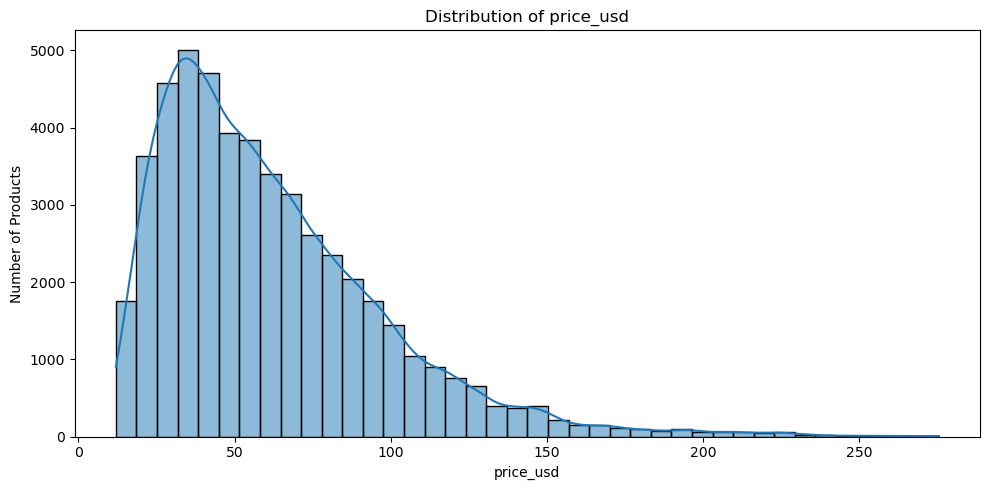

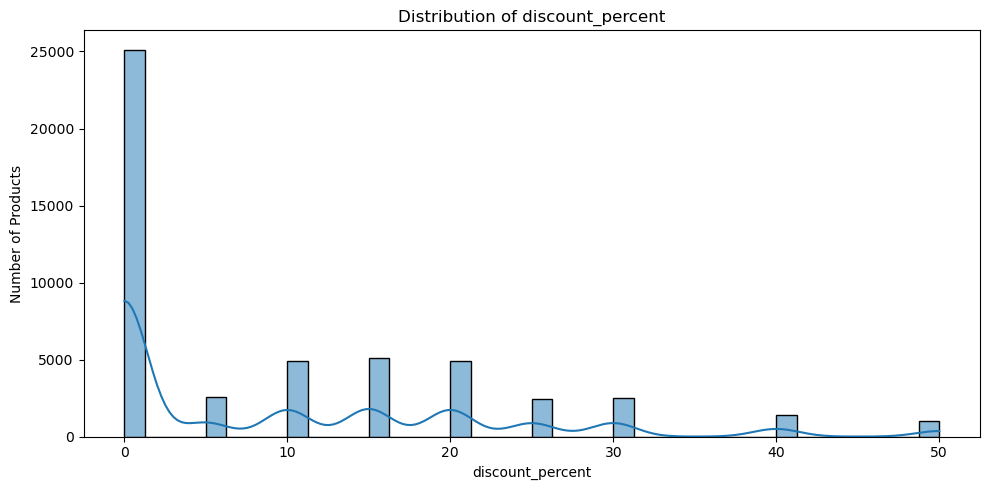

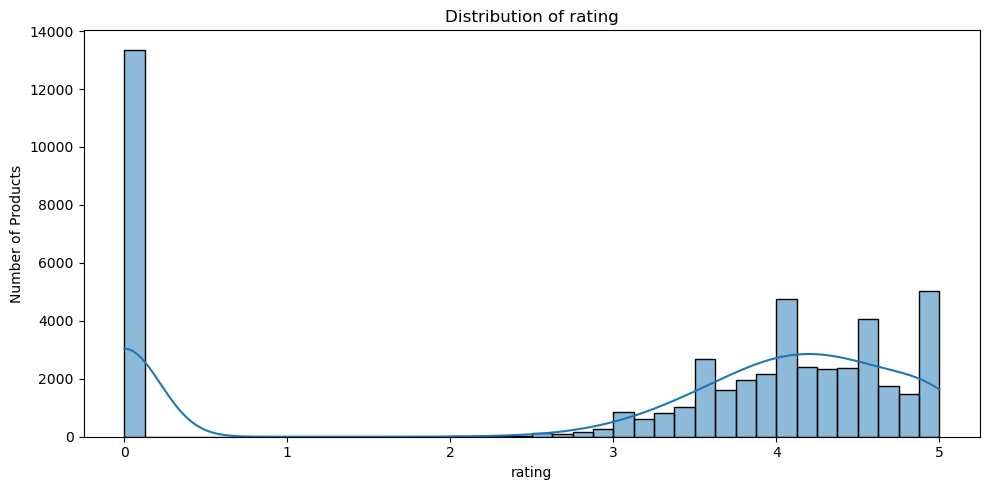

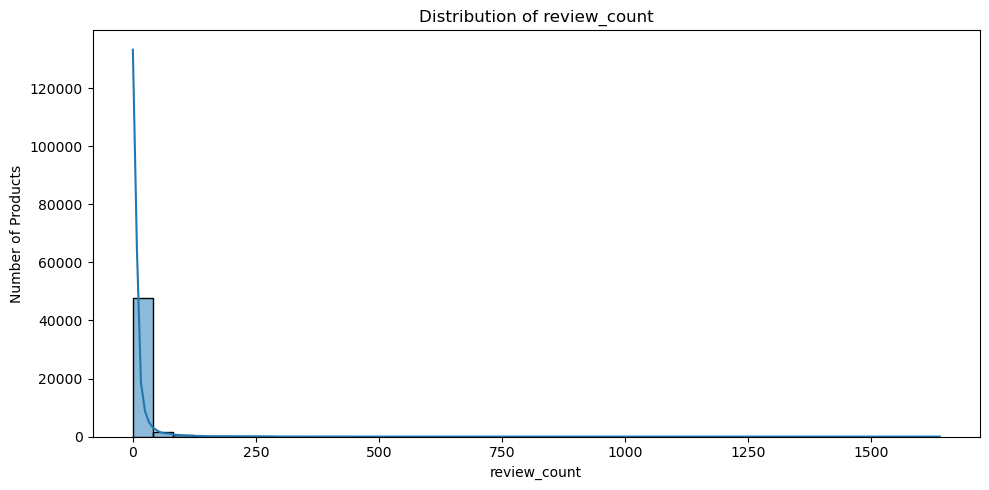

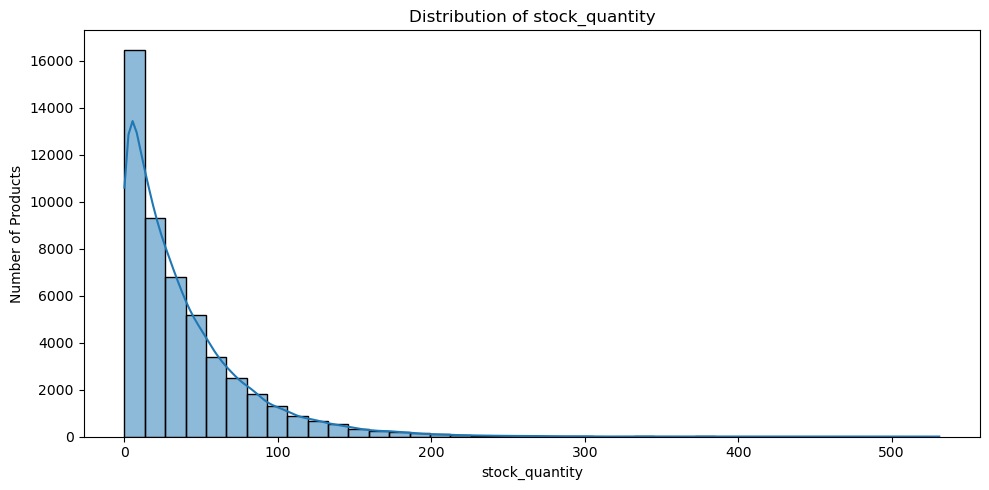

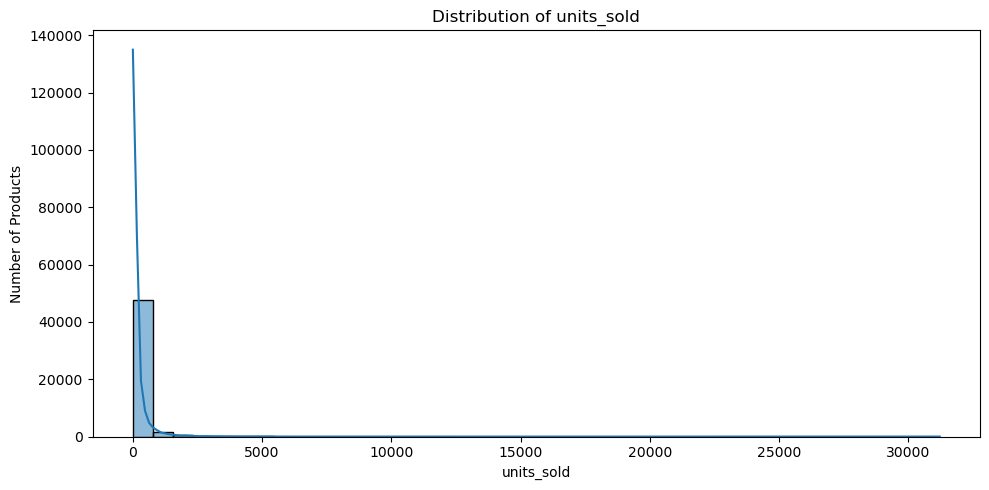

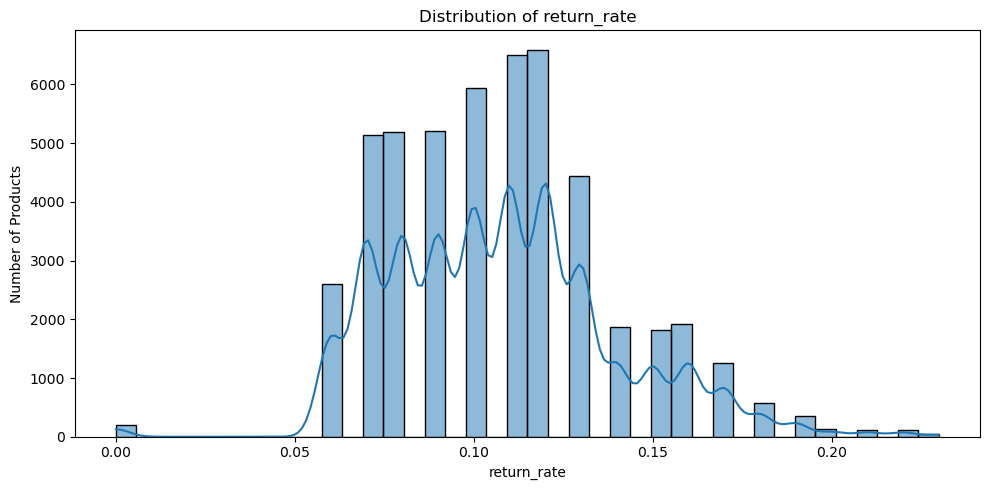

In [15]:
# ============================================================
# KEY NUMERICAL DISTRIBUTIONS
# ============================================================

eda_columns = [
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]

for col in eda_columns:
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        df_clean[col],
        bins=40,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Products")
    plt.tight_layout()
    plt.show()

Cell 15 — Boxplots for outlier detection

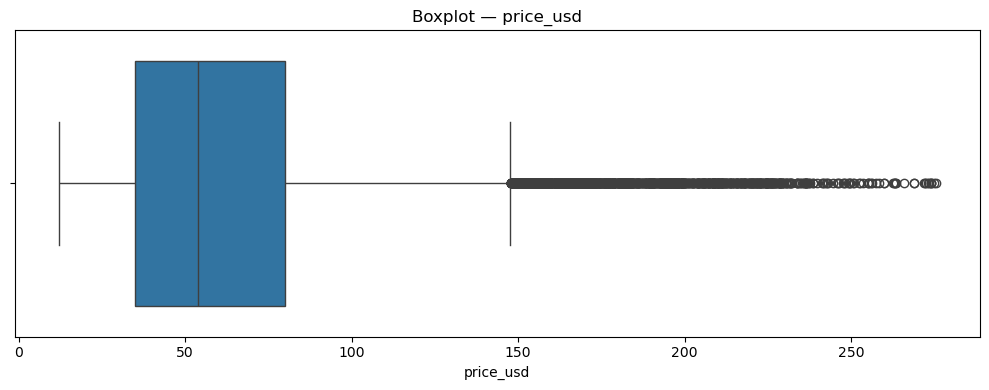

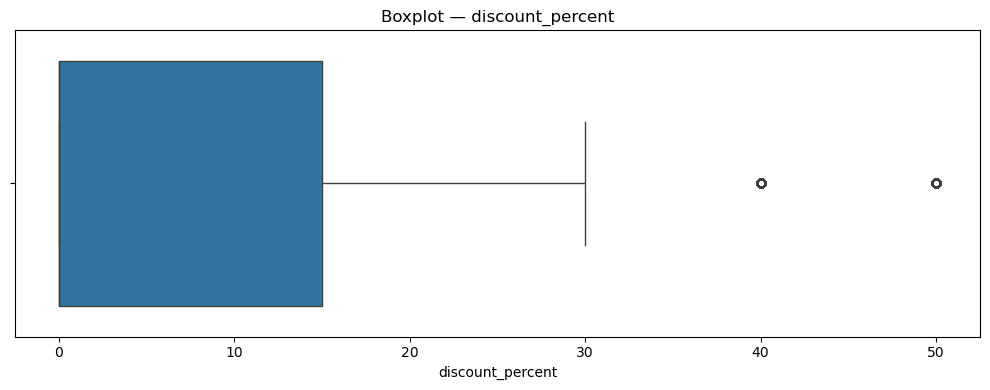

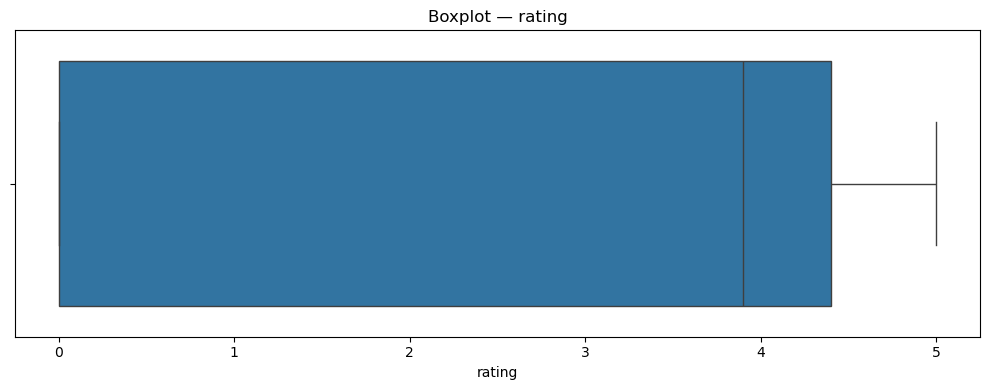

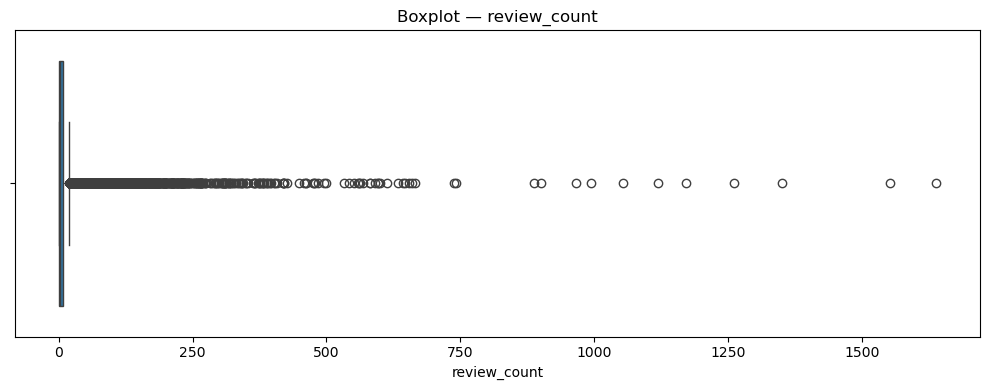

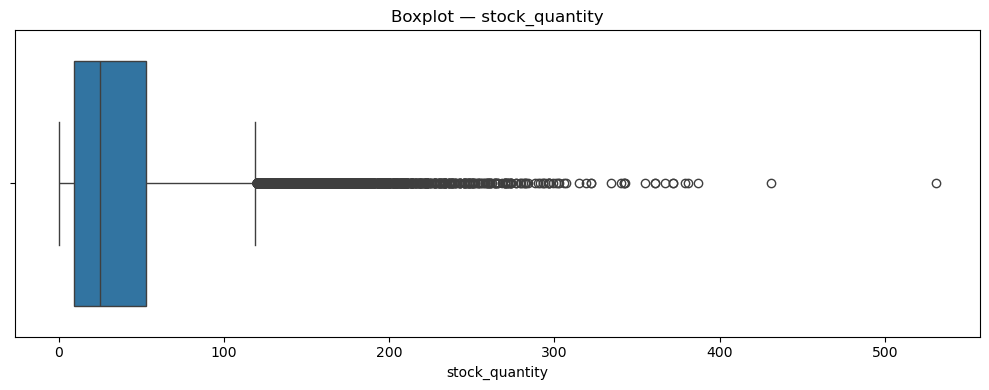

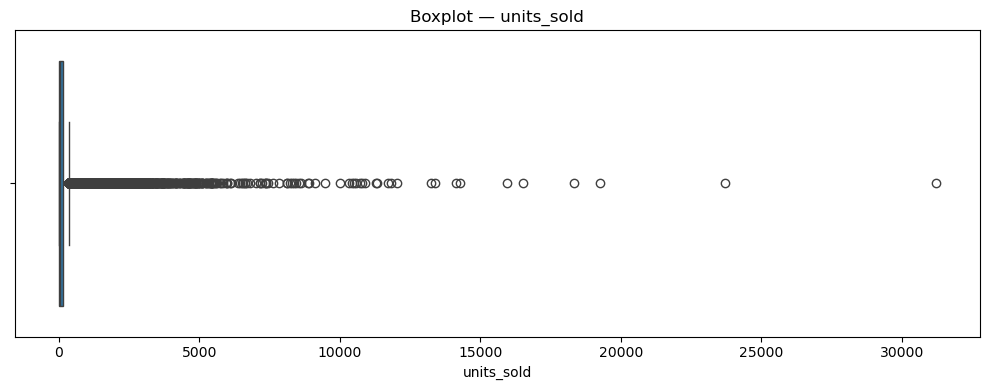

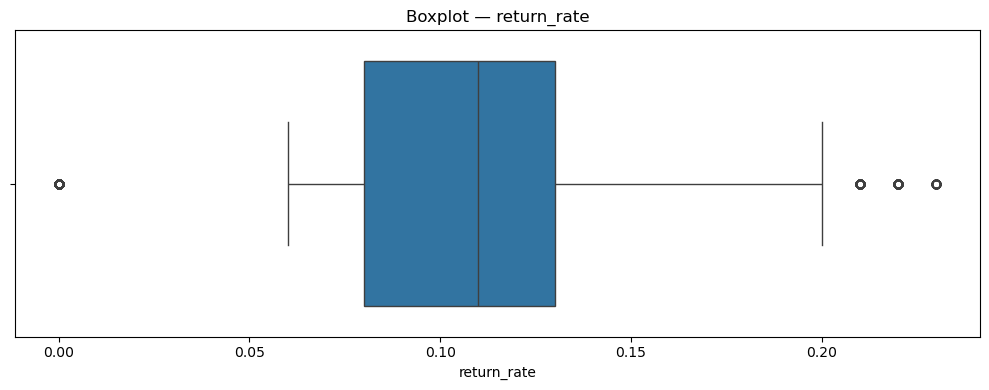

In [16]:
# ============================================================
# OUTLIER VISUALIZATION
# ============================================================

for col in eda_columns:
    plt.figure(figsize=(10, 4))
    
    sns.boxplot(x=df_clean[col])
    
    plt.title(f"Boxplot — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

Cell 16 — Category performance

In [17]:
# ============================================================
# CATEGORY PERFORMANCE
# ============================================================

category_performance = (
    df_clean
    .groupby("category")
    .agg(
        Products=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Average_Units_Sold=("units_sold", "mean"),
        Average_Price=("price_usd", "mean"),
        Average_Rating=("rating", "mean"),
        Average_Return_Rate=("return_rate", "mean"),
        Average_Discount=("discount_percent", "mean")
    )
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

category_performance

,Products,Total_Units_Sold,Average_Units_Sold,Average_Price,Average_Rating,Average_Return_Rate,Average_Discount
category,,,,,,,
Tops,5909,1167189,197.527331,31.812579,3.055542,0.099267,9.422914
Dresses,6133,1142011,186.207566,85.237650,3.034078,0.139204,9.655960
Jeans,4467,853870,191.150660,68.905594,3.041952,0.139149,9.647414
T-Shirts,4520,810126,179.231416,23.453418,3.026571,0.099274,9.496681
Blouses,4016,733189,182.566982,43.088269,3.062799,0.099054,9.685010
Trousers,3505,645686,184.218545,65.120713,3.061198,0.099820,9.425107
Sweaters,3511,613191,174.648533,66.262082,3.056309,0.099314,9.438906
Jackets,3030,587283,193.822772,101.858248,3.110000,0.098584,9.717822
Skirts,3040,552580,181.769737,48.509322,3.038026,0.099595,9.386513


Cell 17 — Category sales visualization

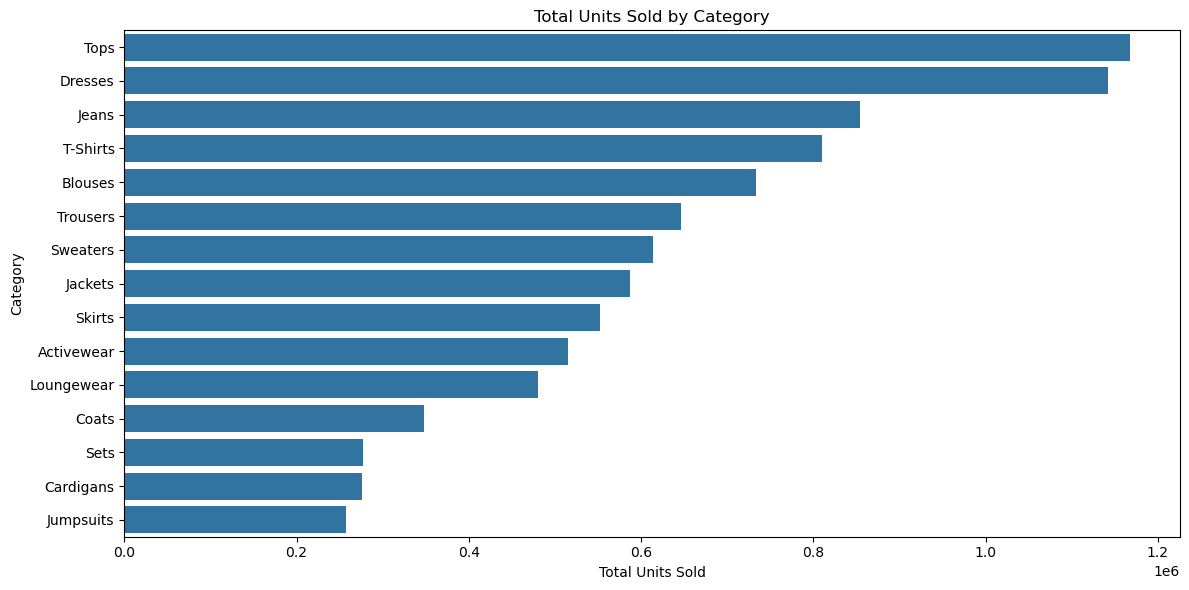

In [18]:
# ============================================================
# TOTAL UNITS SOLD BY CATEGORY
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=category_performance.reset_index(),
    x="Total_Units_Sold",
    y="category"
)

plt.title("Total Units Sold by Category")
plt.xlabel("Total Units Sold")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

Cell 18 — Subcategory performance

In [19]:
# ============================================================
# SUBCATEGORY PERFORMANCE
# ============================================================

subcategory_performance = (
    df_clean
    .groupby("subcategory")
    .agg(
        Products=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Average_Units_Sold=("units_sold", "mean"),
        Average_Price=("price_usd", "mean"),
        Average_Rating=("rating", "mean"),
        Average_Return_Rate=("return_rate", "mean")
    )
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

subcategory_performance.head(20)

,Products,Total_Units_Sold,Average_Units_Sold,Average_Price,Average_Rating,Average_Return_Rate
subcategory,,,,,,
Bodysuit,1509,347251,230.119947,31.769920,3.026972,0.099384
Graphic T-Shirt,1521,298672,196.365549,23.671262,3.028468,0.098810
Long Sleeve Top,1462,282939,193.528728,31.886060,3.019425,0.097941
Tank Top,1460,278878,191.012329,31.567445,3.118630,0.099712
Wrap Blouse,1333,272916,204.738185,43.652153,3.088747,0.098650
V-Neck T-Shirt,1476,260585,176.548103,23.428963,3.048103,0.099919
Crop Top,1478,258121,174.642084,32.025595,3.058119,0.100020
Lounge Set,1309,251640,192.238350,57.773911,3.089992,0.097937
Basic T-Shirt,1523,250869,164.720289,23.259560,3.003808,0.099114


Cell 19 — Top 20 products by units sold

In [20]:
# ============================================================
# TOP 20 PRODUCTS
# ============================================================

top_products = (
    df_clean
    .sort_values(
        "units_sold",
        ascending=False
    )
    .head(20)
)

top_products[
    [
        "product_id",
        "category",
        "subcategory",
        "price_usd",
        "discount_percent",
        "rating",
        "review_count",
        "stock_quantity",
        "units_sold",
        "return_rate"
    ]
]

,product_id,category,subcategory,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
21480,WC021481,Dresses,Wrap Dress,115.21,50,5.0,901,103,31215,0.13
34567,WC034568,Tops,Long Sleeve Top,43.70,20,4.4,1639,4,23691,0.08
29895,WC029896,Tops,Bodysuit,18.03,20,4.4,1552,0,19255,0.10
26572,WC026573,Jackets,Bomber Jacket,101.47,0,3.8,888,30,18348,0.07
34035,WC034036,Tops,Bodysuit,43.65,15,5.0,1171,4,16523,0.12
6412,WC006413,Trousers,Wide-Leg Trousers,41.17,0,4.1,1119,0,15949,0.07
38381,WC038382,Sweaters,Turtleneck,96.53,0,4.4,581,0,14269,0.08
48440,WC048441,Trousers,Wide-Leg Trousers,46.60,30,4.0,1351,15,14142,0.11
24277,WC024278,Skirts,Maxi Skirt,25.84,0,3.3,158,4,13387,0.14
28878,WC028879,Tops,Bodysuit,44.96,0,4.3,1261,75,13237,0.07


Cell 20 — Material analysis

In [21]:
# ============================================================
# MATERIAL PERFORMANCE
# ============================================================

material_analysis = (
    df_clean
    .groupby("material")
    .agg(
        Products=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Avg_Units_Sold=("units_sold", "mean"),
        Avg_Price=("price_usd", "mean"),
        Avg_Rating=("rating", "mean"),
        Avg_Return_Rate=("return_rate", "mean")
    )
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

material_analysis

,Products,Total_Units_Sold,Avg_Units_Sold,Avg_Price,Avg_Rating,Avg_Return_Rate
material,,,,,,
Cotton,14493,2766898,190.912716,50.171255,3.062099,0.104690
Cotton Blend,8399,1518130,180.751280,49.830381,3.025182,0.106912
Polyester,6773,1238405,182.844382,64.877929,3.057316,0.106716
Denim,5242,1039784,198.356353,75.401019,3.070374,0.129802
Polyester Blend,3986,697007,174.863773,68.286631,3.092474,0.104762
Viscose,3501,625887,178.773779,52.017721,3.037418,0.106458
Wool,3299,574596,174.172780,101.023489,3.029130,0.099864
Linen,2279,411971,180.768319,72.628442,3.071874,0.109096
Nylon,1115,211059,189.290583,50.104502,3.054439,0.098726


Cell 21 — Style analysis

In [22]:
# ============================================================
# STYLE PERFORMANCE
# ============================================================

style_analysis = (
    df_clean
    .groupby("style")
    .agg(
        Products=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Avg_Units_Sold=("units_sold", "mean"),
        Avg_Price=("price_usd", "mean"),
        Avg_Rating=("rating", "mean"),
        Avg_Return_Rate=("return_rate", "mean")
    )
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

style_analysis

,Products,Total_Units_Sold,Avg_Units_Sold,Avg_Price,Avg_Rating,Avg_Return_Rate
style,,,,,,
Casual,12200,2243558,183.898197,48.714078,3.044746,0.104070
Business Casual,7793,1481751,190.138714,64.965679,3.045823,0.107354
Minimalist,6811,1269591,186.403025,59.412625,3.077155,0.108168
Formal,6725,1258934,187.202082,71.170906,3.074141,0.108207
Streetwear,5096,909064,178.387755,71.129425,3.038619,0.110498
Bohemian,4355,820837,188.481515,64.229150,3.053662,0.114000
Elegant,4192,760392,181.391221,77.627319,3.068535,0.113650
Sporty,2828,515406,182.251061,50.007921,3.056400,0.099494


Cell 22 — Season analysis

In [23]:
# ============================================================
# SEASON PERFORMANCE
# ============================================================

season_analysis = (
    df_clean
    .groupby("season")
    .agg(
        Products=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Avg_Units_Sold=("units_sold", "mean"),
        Avg_Price=("price_usd", "mean"),
        Avg_Rating=("rating", "mean"),
        Avg_Return_Rate=("return_rate", "mean")
    )
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)

season_analysis

,Products,Total_Units_Sold,Avg_Units_Sold,Avg_Price,Avg_Rating,Avg_Return_Rate
season,,,,,,
Summer,10601,1991461,187.855957,50.124091,3.029139,0.108629
Autumn,10483,1910984,182.293618,69.041001,3.047649,0.106919
Winter,10109,1800796,178.137897,72.289056,3.069344,0.107447
Spring,9486,1790825,188.786106,59.331719,3.063167,0.107404
All Season,9321,1765467,189.407467,58.383176,3.074649,0.108425


Cell 23 — Correlation matrix

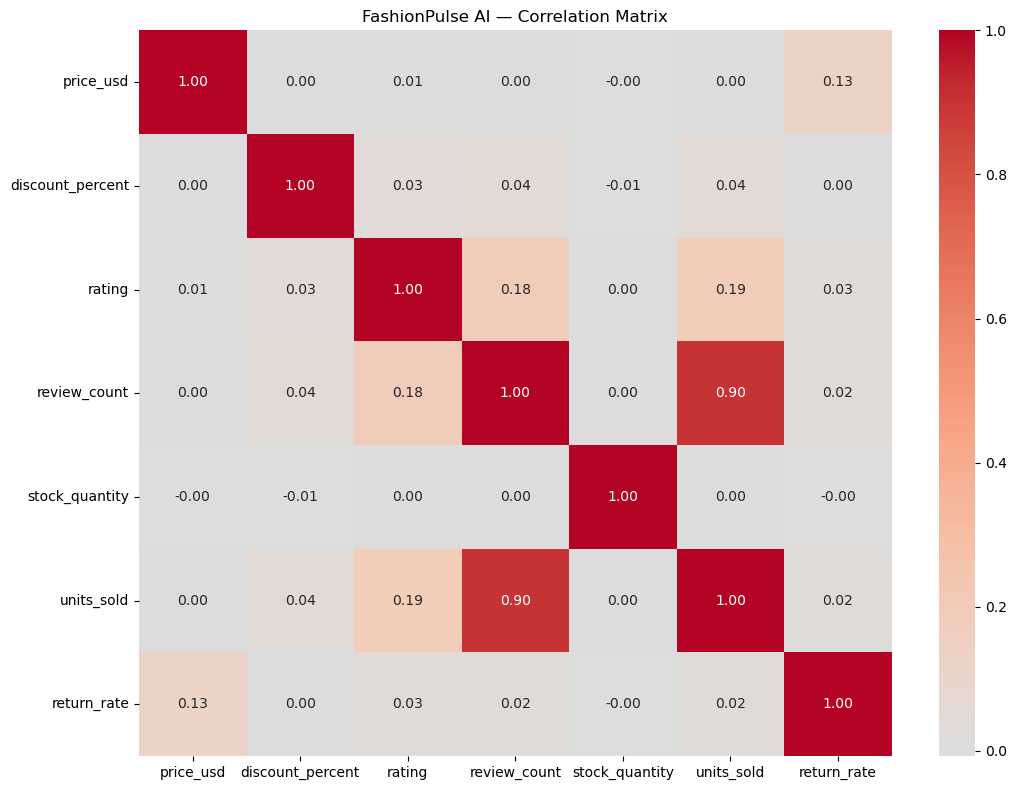

In [24]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation_columns = [
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]

correlation_matrix = df_clean[
    correlation_columns
].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("FashionPulse AI — Correlation Matrix")
plt.tight_layout()
plt.show()

Cell 24 — Price vs sales

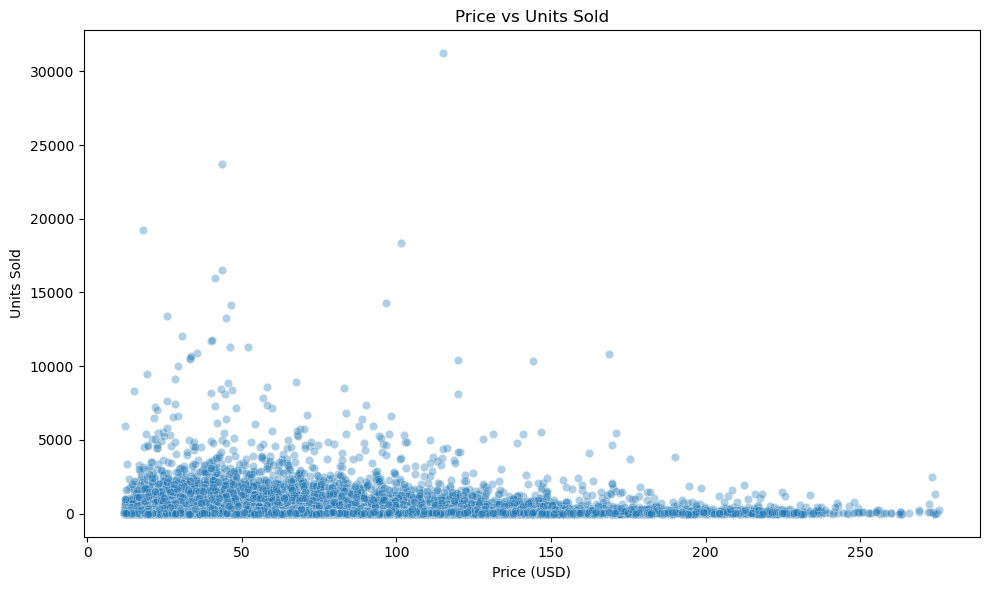

In [25]:
# ============================================================
# PRICE VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="price_usd",
    y="units_sold",
    alpha=0.35
)

plt.title("Price vs Units Sold")
plt.xlabel("Price (USD)")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

Cell 25 — Discount vs sales

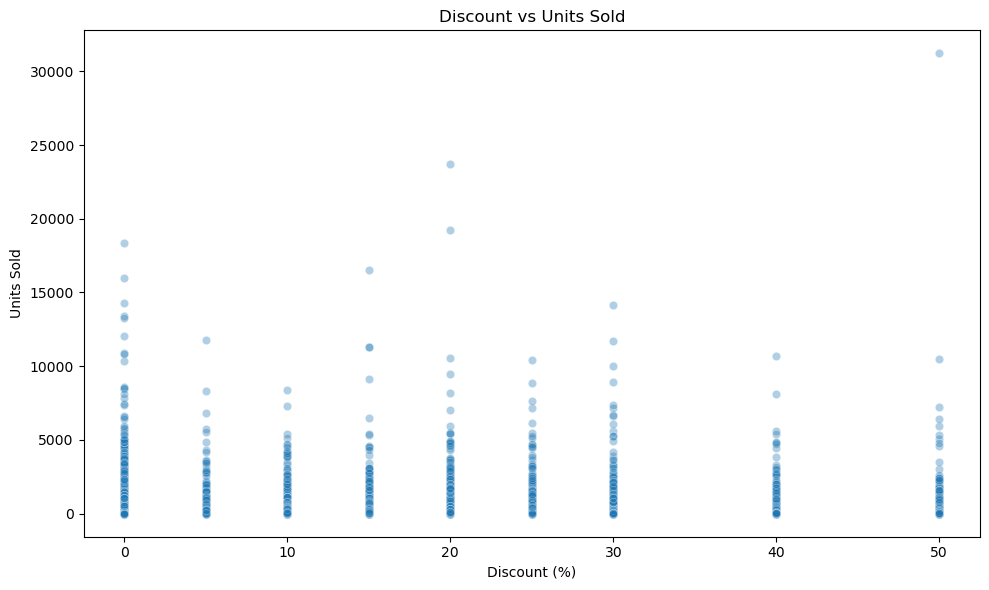

In [26]:
# ============================================================
# DISCOUNT VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="discount_percent",
    y="units_sold",
    alpha=0.35
)

plt.title("Discount vs Units Sold")
plt.xlabel("Discount (%)")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

Cell 26 — Rating vs sales

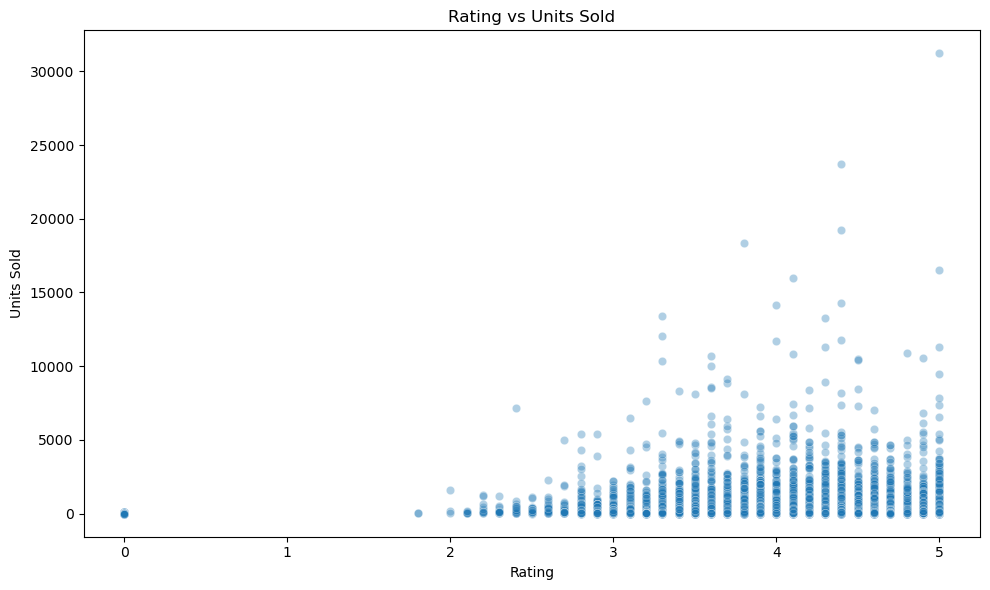

In [27]:
# ============================================================
# RATING VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="rating",
    y="units_sold",
    alpha=0.35
)

plt.title("Rating vs Units Sold")
plt.xlabel("Rating")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

Cell 27 — Return rate vs sales

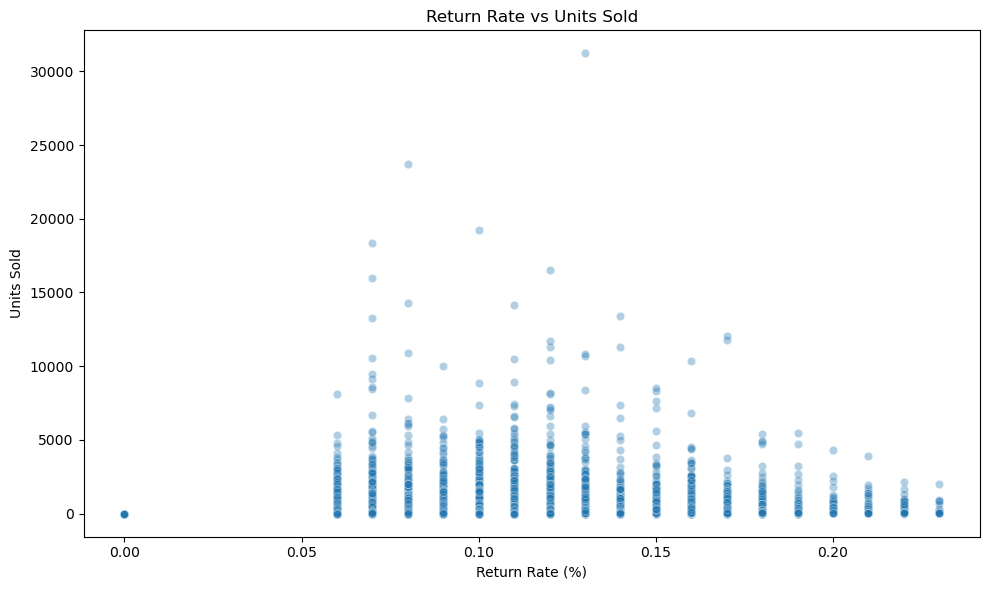

In [28]:
# ============================================================
# RETURN RATE VS SALES
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x="return_rate",
    y="units_sold",
    alpha=0.35
)

plt.title("Return Rate vs Units Sold")
plt.xlabel("Return Rate (%)")
plt.ylabel("Units Sold")
plt.tight_layout()
plt.show()

Cell 28 — EDA summary table

In [29]:
# ============================================================
# EDA SUMMARY
# ============================================================

eda_summary = pd.DataFrame({
    "Metric": [
        "Total Products",
        "Total Units Sold",
        "Average Units Sold",
        "Median Units Sold",
        "Average Price",
        "Median Price",
        "Average Rating",
        "Average Return Rate",
        "Average Discount"
    ],
    
    "Value": [
        df_clean["product_id"].nunique(),
        df_clean["units_sold"].sum(),
        df_clean["units_sold"].mean(),
        df_clean["units_sold"].median(),
        df_clean["price_usd"].mean(),
        df_clean["price_usd"].median(),
        df_clean["rating"].mean(),
        df_clean["return_rate"].mean(),
        df_clean["discount_percent"].mean()
    ]
})

eda_summary

,Metric,Value
0,Total Products,5.000000e+04
1,Total Units Sold,9.259533e+06
2,Average Units Sold,1.851907e+02
3,Median Units Sold,5.900000e+01
4,Average Price,6.185805e+01
5,Median Price,5.375000e+01
6,Average Rating,3.056088e+00
7,Average Return Rate,1.077610e-01
8,Average Discount,9.617800e+00


# Step 4: Outlier Analysis + Feature Engineering

Cell 29 — Detect outliers using IQR

In [30]:
# ============================================================
# STEP 4 — OUTLIER ANALYSIS
# IQR METHOD
# ============================================================

outlier_summary = []

for col in numeric_columns:
    
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = (
        (df_clean[col] < lower_bound) |
        (df_clean[col] > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers,
        "Outlier_Percentage": round(
            outliers / len(df_clean) * 100, 2
        )
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary.sort_values(
    "Outlier_Percentage",
    ascending=False
)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
5,units_sold,21.00,163.00,142.00,-192.000,376.000,5485,10.97
3,review_count,0.00,8.00,8.00,-12.000,20.000,5337,10.67
1,discount_percent,0.00,15.00,15.00,-22.500,37.500,2436,4.87
4,stock_quantity,9.00,53.00,44.00,-57.000,119.000,2385,4.77
0,price_usd,34.89,80.03,45.14,-32.820,147.740,1412,2.82
6,return_rate,0.08,0.13,0.05,0.005,0.205,481,0.96
2,rating,0.00,4.40,4.40,-6.600,11.000,0,0.00


Cell 30 — Examine extreme sales products

In [31]:
# ============================================================
# EXTREME SALES ANALYSIS
# ============================================================

sales_extremes = df_clean.sort_values(
    "units_sold",
    ascending=False
).head(20)

sales_extremes[
    [
        "product_id",
        "category",
        "subcategory",
        "price_usd",
        "discount_percent",
        "rating",
        "review_count",
        "stock_quantity",
        "units_sold",
        "return_rate"
    ]
]

,product_id,category,subcategory,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
21480,WC021481,Dresses,Wrap Dress,115.21,50,5.0,901,103,31215,0.13
34567,WC034568,Tops,Long Sleeve Top,43.70,20,4.4,1639,4,23691,0.08
29895,WC029896,Tops,Bodysuit,18.03,20,4.4,1552,0,19255,0.10
26572,WC026573,Jackets,Bomber Jacket,101.47,0,3.8,888,30,18348,0.07
34035,WC034036,Tops,Bodysuit,43.65,15,5.0,1171,4,16523,0.12
6412,WC006413,Trousers,Wide-Leg Trousers,41.17,0,4.1,1119,0,15949,0.07
38381,WC038382,Sweaters,Turtleneck,96.53,0,4.4,581,0,14269,0.08
48440,WC048441,Trousers,Wide-Leg Trousers,46.60,30,4.0,1351,15,14142,0.11
24277,WC024278,Skirts,Maxi Skirt,25.84,0,3.3,158,4,13387,0.14
28878,WC028879,Tops,Bodysuit,44.96,0,4.3,1261,75,13237,0.07


# Step 5 — Feature Engineering

Cell 31 — Create estimated sales value

In [32]:
# ============================================================
# FEATURE ENGINEERING
# ESTIMATED SALES VALUE
# ============================================================

df_clean["estimated_gross_sales_value"] = (
    df_clean["price_usd"] *
    df_clean["units_sold"]
)

df_clean[
    [
        "product_id",
        "price_usd",
        "units_sold",
        "estimated_gross_sales_value"
    ]
].head()

,product_id,price_usd,units_sold,estimated_gross_sales_value
0,WC000001,37.00,14,518.00
1,WC000002,59.12,31,1832.72
2,WC000003,27.65,2,55.30
3,WC000004,72.64,292,21210.88
4,WC000005,72.61,15,1089.15


Cell 32 — Discounted price

In [33]:
# ============================================================
# DISCOUNTED PRICE
# ============================================================

df_clean["discounted_price"] = (
    df_clean["price_usd"] *
    (1 - df_clean["discount_percent"] / 100)
)

df_clean[
    [
        "price_usd",
        "discount_percent",
        "discounted_price"
    ]
].head()

,price_usd,discount_percent,discounted_price
0,37.00,0,37.000
1,59.12,10,53.208
2,27.65,0,27.650
3,72.64,0,72.640
4,72.61,40,43.566


Cell 33 — Estimated sales value after discount

In [34]:
# ============================================================
# ESTIMATED SALES VALUE AFTER DISCOUNT
# ============================================================

df_clean["estimated_net_sales_value"] = (
    df_clean["discounted_price"] *
    df_clean["units_sold"]
)

df_clean[
    [
        "price_usd",
        "discount_percent",
        "discounted_price",
        "units_sold",
        "estimated_net_sales_value"
    ]
].head()

,price_usd,discount_percent,discounted_price,units_sold,estimated_net_sales_value
0,37.00,0,37.000,14,518.000
1,59.12,10,53.208,31,1649.448
2,27.65,0,27.650,2,55.300
3,72.64,0,72.640,292,21210.880
4,72.61,40,43.566,15,653.490


Cell 34 — Estimated returned units

In [35]:
# ============================================================
# ESTIMATED RETURNED UNITS
# ============================================================

df_clean["estimated_returned_units"] = (
    df_clean["units_sold"] *
    df_clean["return_rate"] / 100
)

df_clean[
    [
        "units_sold",
        "return_rate",
        "estimated_returned_units"
    ]
].head()

,units_sold,return_rate,estimated_returned_units
0,14,0.17,0.0238
1,31,0.13,0.0403
2,2,0.11,0.0022
3,292,0.14,0.4088
4,15,0.07,0.0105


Cell 35 — Estimated kept units

In [36]:
# ============================================================
# ESTIMATED KEPT UNITS
# ============================================================

df_clean["estimated_kept_units"] = (
    df_clean["units_sold"] -
    df_clean["estimated_returned_units"]
)

df_clean[
    [
        "units_sold",
        "estimated_returned_units",
        "estimated_kept_units"
    ]
].head()

,units_sold,estimated_returned_units,estimated_kept_units
0,14,0.0238,13.9762
1,31,0.0403,30.9597
2,2,0.0022,1.9978
3,292,0.4088,291.5912
4,15,0.0105,14.9895


Cell 36 — Inventory-to-sales ratio

In [37]:
# ============================================================
# INVENTORY / SALES RATIO
# ============================================================

df_clean["inventory_sales_ratio"] = (
    df_clean["stock_quantity"] /
    (df_clean["units_sold"] + 1)
)

df_clean[
    [
        "stock_quantity",
        "units_sold",
        "inventory_sales_ratio"
    ]
].head()

,stock_quantity,units_sold,inventory_sales_ratio
0,2,14,0.133333
1,13,31,0.406250
2,10,2,3.333333
3,104,292,0.354949
4,12,15,0.750000


# Cell 37 — Sales velocity proxy

Since we don't have dates, we cannot calculate true daily/weekly sales velocity.

Instead, we'll create a normalized sales-performance measure.

In [38]:
# ============================================================
# SALES PERFORMANCE INDEX
# ============================================================

df_clean["sales_performance_index"] = (
    df_clean["units_sold"] /
    df_clean["units_sold"].median()
)

df_clean[
    [
        "units_sold",
        "sales_performance_index"
    ]
].head()

,units_sold,sales_performance_index
0,14,0.237288
1,31,0.525424
2,2,0.033898
3,292,4.949153
4,15,0.254237


# Cell 38 — Price segment

In [39]:
# ============================================================
# PRICE SEGMENT
# ============================================================

df_clean["price_segment"] = pd.cut(
    df_clean["price_usd"],
    bins=[
        -np.inf,
        25,
        50,
        100,
        200,
        np.inf
    ],
    labels=[
        "Budget",
        "Affordable",
        "Mid-Range",
        "Premium",
        "Luxury"
    ]
)

df_clean["price_segment"].value_counts()

price_segment
Mid-Range     20661
Affordable    17437
Premium        6294
Budget         5283
Luxury          325
Name: count, dtype: int64

Cell 39 — Discount segment

In [40]:
# ============================================================
# DISCOUNT SEGMENT
# ============================================================

df_clean["discount_segment"] = pd.cut(
    df_clean["discount_percent"],
    bins=[
        -0.01,
        0,
        10,
        25,
        40,
        50
    ],
    labels=[
        "No Discount",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

df_clean["discount_segment"].value_counts()

discount_segment
No Discount    25117
Moderate       12474
Low             7478
High            3907
Very High       1024
Name: count, dtype: int64

Cell 40 — Rating segment

In [41]:
# ============================================================
# RATING SEGMENT
# ============================================================

df_clean["rating_segment"] = pd.cut(
    df_clean["rating"],
    bins=[
        -np.inf,
        2.5,
        3.5,
        4.0,
        4.5,
        np.inf
    ],
    labels=[
        "Poor",
        "Average",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

df_clean["rating_segment"].value_counts()

rating_segment
Poor         13477
Very Good    11645
Excellent    10209
Good          9541
Average       5128
Name: count, dtype: int64

Cell 41 — Inventory status

In [42]:
# ============================================================
# INVENTORY STATUS
# ============================================================

def inventory_status(row):
    
    if row["stock_quantity"] == 0:
        return "Out of Stock"
    
    elif row["units_sold"] > row["stock_quantity"] * 5:
        return "Critical Stock"
    
    elif row["units_sold"] > row["stock_quantity"] * 2:
        return "Low Stock"
    
    elif row["stock_quantity"] > row["units_sold"] * 5:
        return "Overstocked"
    
    else:
        return "Healthy"

df_clean["inventory_status"] = df_clean.apply(
    inventory_status,
    axis=1
)

df_clean["inventory_status"].value_counts()

inventory_status
Healthy           17464
Critical Stock    15845
Low Stock          8536
Overstocked        4440
Out of Stock       3715
Name: count, dtype: int64

Cell 42 — Return-risk segment

In [43]:
# ============================================================
# RETURN RISK SEGMENT
# ============================================================

df_clean["return_risk"] = pd.cut(
    df_clean["return_rate"],
    bins=[
        -0.01,
        5,
        10,
        15,
        20,
        np.inf
    ],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df_clean["return_risk"].value_counts()

return_risk
Very Low     50000
Low              0
Medium           0
High             0
Very High        0
Name: count, dtype: int64

Cell 43 — Create the final feature overview

In [44]:
# ============================================================
# FINAL FEATURE OVERVIEW
# ============================================================

print("Original Columns:", len(df.columns))
print("Engineered Columns:", len(df_clean.columns))
print()

print("New Features:")
new_features = [
    col for col in df_clean.columns
    if col not in df.columns
]

for feature in new_features:
    print("•", feature)

Original Columns: 15
Engineered Columns: 27

New Features:
• estimated_gross_sales_value
• discounted_price
• estimated_net_sales_value
• estimated_returned_units
• estimated_kept_units
• inventory_sales_ratio
• sales_performance_index
• price_segment
• discount_segment
• rating_segment
• inventory_status
• return_risk


Cell 44 — Save engineered dataset

In [45]:
# ============================================================
# SAVE ENGINEERED DATASET
# ============================================================

OUTPUT_FILE = "fashionpulse_engineered.csv"

df_clean.to_csv(
    OUTPUT_FILE,
    index=False
)

print(f"✅ Engineered dataset saved as: {OUTPUT_FILE}")
print(f"Shape: {df_clean.shape}")

✅ Engineered dataset saved as: fashionpulse_engineered.csv
Shape: (50000, 27)


## Step 6 — Business Analytics as a single clean program

FASHIONPULSE AI — STEP 6
BUSINESS ANALYTICS

Dataset successfully detected.
Rows    : 50,000
Columns : 27

1. OVERALL BUSINESS KPIs
                        KPI        Value
             Total Products 5.000000e+04
           Total Units Sold 9.259533e+06
Estimated Gross Sales Value 5.744506e+08
  Estimated Net Sales Value 5.103805e+08
     Current Stock Quantity 1.875754e+06
   Estimated Returned Units 1.016795e+04
      Average Product Price 6.185805e+01
       Median Product Price 5.375000e+01
             Average Rating 3.056088e+00
        Average Return Rate 1.077610e-01
           Average Discount 9.617800e+00

2. CATEGORY PERFORMANCE
            Products  Total_Units_Sold  Average_Units_Sold  Estimated_Sales_Value  Average_Price  Average_Rating  \
category                                                                                                           
Tops            5909           1167189              197.53           3.752098e+07          31.81            3.06   
Dre

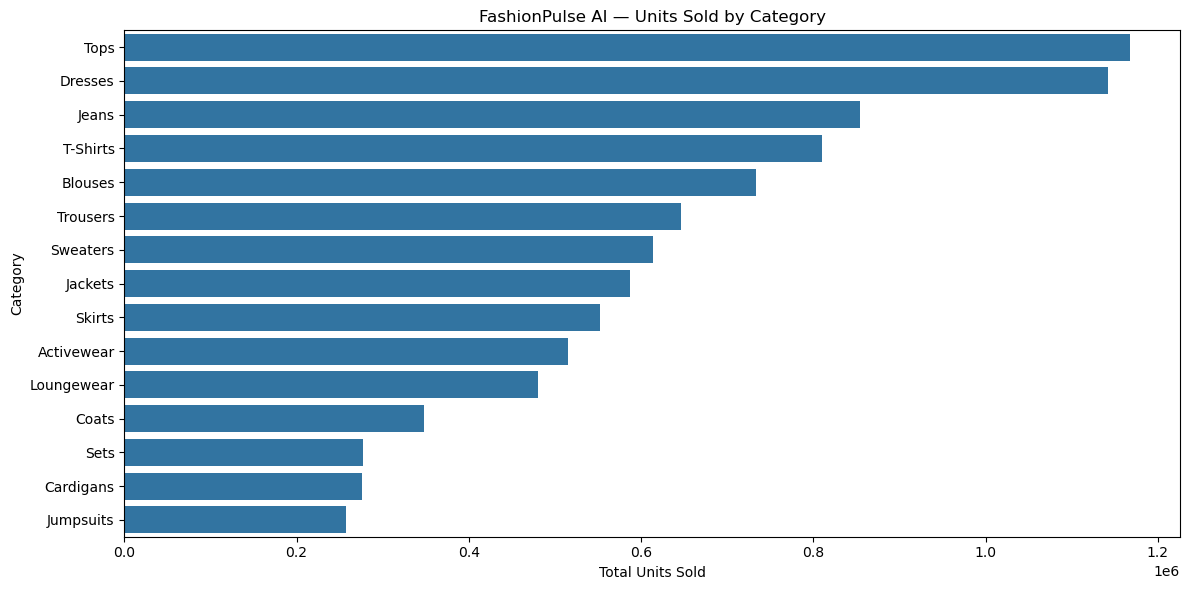


3. TOP SUBCATEGORIES
                   Products  Total_Units_Sold  Average_Units_Sold  Estimated_Sales_Value  Average_Price  \
subcategory                                                                                               
Bodysuit               1509            347251              230.12            10952244.80          31.77   
Graphic T-Shirt        1521            298672              196.37             7133126.50          23.67   
Long Sleeve Top        1462            282939              193.53             9351361.12          31.89   
Tank Top               1460            278878              191.01             8765892.48          31.57   
Wrap Blouse            1333            272916              204.74            11878346.35          43.65   
V-Neck T-Shirt         1476            260585              176.55             6273018.52          23.43   
Crop Top               1478            258121              174.64             8451477.03          32.03   
Lounge Set     

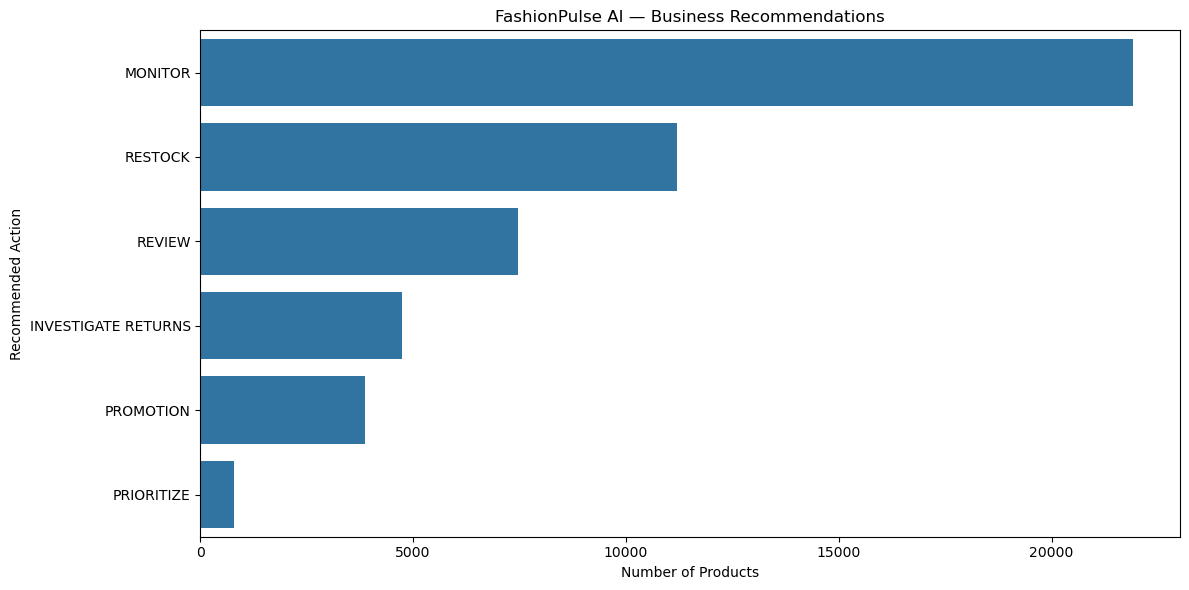


19. CORRELATION MATRIX
                  price_usd  discount_percent  rating  review_count  stock_quantity  units_sold  return_rate
price_usd             1.000             0.002   0.009         0.001          -0.003       0.002        0.125
discount_percent      0.002             1.000   0.034         0.041          -0.007       0.045        0.005
rating                0.009             0.034   1.000         0.176           0.004       0.188        0.027
review_count          0.001             0.041   0.176         1.000           0.001       0.901        0.018
stock_quantity       -0.003            -0.007   0.004         0.001           1.000       0.001       -0.003
units_sold            0.002             0.045   0.188         0.901           0.001       1.000        0.023
return_rate           0.125             0.005   0.027         0.018          -0.003       0.023        1.000


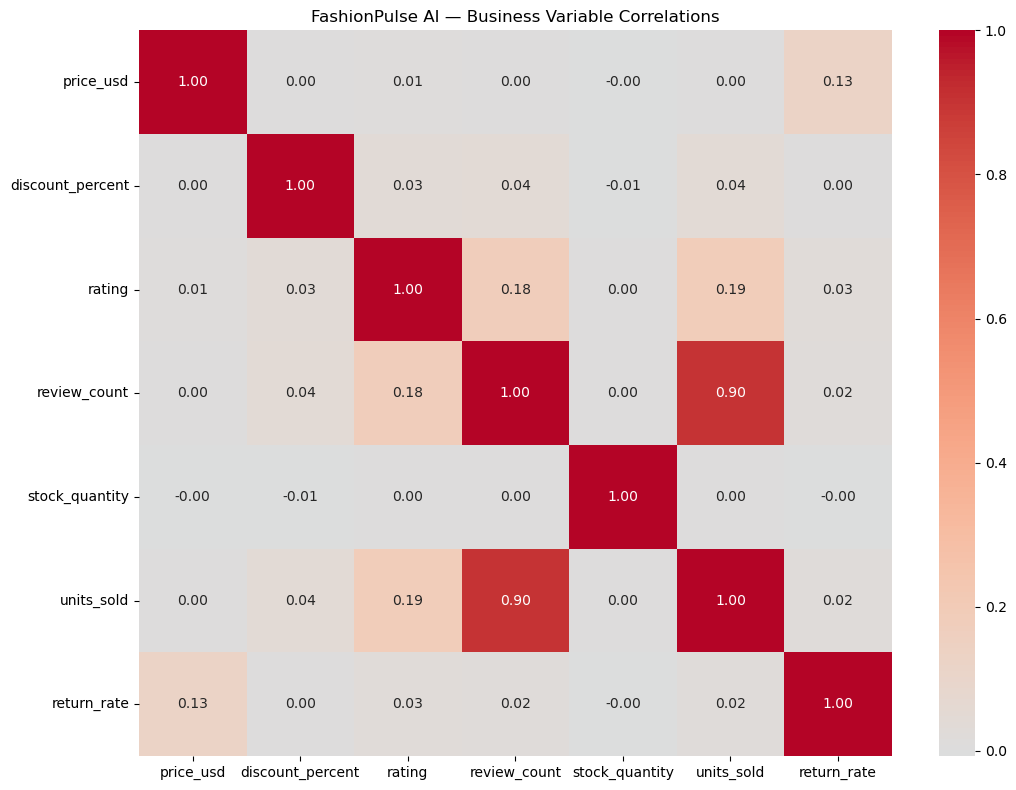


20. STATISTICAL ASSOCIATION WITH UNITS SOLD
           Variable  Pearson_r  Pearson_p_value  Spearman_rho  Spearman_p_value
0         price_usd   0.001751         0.695445      0.007335          0.100959
1  discount_percent   0.044819         0.000000      0.055697          0.000000
2            rating   0.188214         0.000000      0.547702          0.000000
3      review_count   0.901413         0.000000      0.914992          0.000000
4    stock_quantity   0.001024         0.818899      0.010859          0.015177
5       return_rate   0.022652         0.000000      0.061068          0.000000

21. AUTOMATED BUSINESS INSIGHTS
🏆 Best Category: Tops
🏆 Best Subcategory: Bodysuit
🏆 Best Material by Total Sales: Cotton
🏆 Best Style by Total Sales: Casual
🏆 Best Season by Total Sales: Summer
💰 Strongest Average Sales Price Segment: Premium
🏷️ Strongest Average Sales Discount Segment: Very High
📦 Restock Candidates: 19,114
📦 Overstock Candidates: 4,440
🔄 High Return-Risk Products: 6,326



In [46]:
# ============================================================
# FASHIONPULSE AI
# STEP 6 — BUSINESS ANALYTICS
# ============================================================
#
# PURPOSE:
# Convert cleaned product data into actionable business insights.
#
# OUTPUT:
# 1. Business KPIs
# 2. Category performance
# 3. Subcategory performance
# 4. Product ranking
# 5. Price analysis
# 6. Discount analysis
# 7. Rating analysis
# 8. Material analysis
# 9. Style analysis
# 10. Season analysis
# 11. Inventory analysis
# 12. Return analysis
# 13. Product opportunity scoring
# 14. Restock recommendations
# 15. Overstock recommendations
# 16. Return-risk recommendations
# 17. Business recommendation engine
# 18. Statistical relationship analysis
# 19. Export Power BI-ready tables
#
# ============================================================


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# ============================================================
# 1. CHECK DATA
# ============================================================

print("=" * 80)
print("FASHIONPULSE AI — STEP 6")
print("BUSINESS ANALYTICS")
print("=" * 80)

if "df_clean" not in globals():
    raise NameError(
        "df_clean was not found. "
        "Run the previous FashionPulse AI data preparation program first."
    )

print("\nDataset successfully detected.")
print("Rows    :", f"{len(df_clean):,}")
print("Columns :", len(df_clean.columns))


# ============================================================
# 2. CREATE OUTPUT DIRECTORY
# ============================================================

OUTPUT_DIR = "fashionpulse_business_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. CREATE REQUIRED FEATURES IF MISSING
# ============================================================

if "estimated_gross_sales_value" not in df_clean.columns:

    df_clean["estimated_gross_sales_value"] = (
        df_clean["price_usd"] *
        df_clean["units_sold"]
    )


if "discounted_price" not in df_clean.columns:

    df_clean["discounted_price"] = (
        df_clean["price_usd"] *
        (
            1 -
            df_clean["discount_percent"] / 100
        )
    )


if "estimated_net_sales_value" not in df_clean.columns:

    df_clean["estimated_net_sales_value"] = (
        df_clean["discounted_price"] *
        df_clean["units_sold"]
    )


if "estimated_returned_units" not in df_clean.columns:

    df_clean["estimated_returned_units"] = (
        df_clean["units_sold"] *
        df_clean["return_rate"] / 100
    )


if "estimated_kept_units" not in df_clean.columns:

    df_clean["estimated_kept_units"] = (
        df_clean["units_sold"] -
        df_clean["estimated_returned_units"]
    )


if "inventory_sales_ratio" not in df_clean.columns:

    df_clean["inventory_sales_ratio"] = (
        df_clean["stock_quantity"] /
        (df_clean["units_sold"] + 1)
    )


# ============================================================
# 4. OVERALL BUSINESS KPIs
# ============================================================

total_products = df_clean["product_id"].nunique()

total_units_sold = (
    df_clean["units_sold"].sum()
)

estimated_gross_sales = (
    df_clean["estimated_gross_sales_value"].sum()
)

estimated_net_sales = (
    df_clean["estimated_net_sales_value"].sum()
)

total_stock = (
    df_clean["stock_quantity"].sum()
)

estimated_returned_units = (
    df_clean["estimated_returned_units"].sum()
)

average_price = (
    df_clean["price_usd"].mean()
)

median_price = (
    df_clean["price_usd"].median()
)

average_rating = (
    df_clean["rating"].mean()
)

average_return_rate = (
    df_clean["return_rate"].mean()
)

average_discount = (
    df_clean["discount_percent"].mean()
)


kpi_table = pd.DataFrame({

    "KPI": [
        "Total Products",
        "Total Units Sold",
        "Estimated Gross Sales Value",
        "Estimated Net Sales Value",
        "Current Stock Quantity",
        "Estimated Returned Units",
        "Average Product Price",
        "Median Product Price",
        "Average Rating",
        "Average Return Rate",
        "Average Discount"
    ],

    "Value": [
        total_products,
        total_units_sold,
        estimated_gross_sales,
        estimated_net_sales,
        total_stock,
        estimated_returned_units,
        average_price,
        median_price,
        average_rating,
        average_return_rate,
        average_discount
    ]
})


print("\n" + "=" * 80)
print("1. OVERALL BUSINESS KPIs")
print("=" * 80)

print(kpi_table.to_string(index=False))


# ============================================================
# 5. CATEGORY PERFORMANCE
# ============================================================

category_performance = (

    df_clean

    .groupby("category")

    .agg(

        Products=(
            "product_id",
            "nunique"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Estimated_Sales_Value=(
            "estimated_gross_sales_value",
            "sum"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        ),

        Average_Discount=(
            "discount_percent",
            "mean"
        )

    )

    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)


category_performance["Sales_Share_%"] = (

    category_performance["Total_Units_Sold"]

    /

    category_performance["Total_Units_Sold"].sum()

    * 100
)


print("\n" + "=" * 80)
print("2. CATEGORY PERFORMANCE")
print("=" * 80)

print(
    category_performance.round(2)
)


# ============================================================
# 6. CATEGORY CHART
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=category_performance.reset_index(),
    x="Total_Units_Sold",
    y="category"
)

plt.title(
    "FashionPulse AI — Units Sold by Category"
)

plt.xlabel(
    "Total Units Sold"
)

plt.ylabel(
    "Category"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "category_performance.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# 7. SUBCATEGORY PERFORMANCE
# ============================================================

subcategory_performance = (

    df_clean

    .groupby("subcategory")

    .agg(

        Products=(
            "product_id",
            "nunique"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Estimated_Sales_Value=(
            "estimated_gross_sales_value",
            "sum"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)


print("\n" + "=" * 80)
print("3. TOP SUBCATEGORIES")
print("=" * 80)

print(
    subcategory_performance.head(20).round(2)
)


# ============================================================
# 8. TOP 20 PRODUCTS
# ============================================================

top_products = (

    df_clean

    .sort_values(
        "units_sold",
        ascending=False
    )

    .head(20)

)


print("\n" + "=" * 80)
print("4. TOP 20 PRODUCTS")
print("=" * 80)

print(

    top_products[
        [
            "product_id",
            "category",
            "subcategory",
            "price_usd",
            "discount_percent",
            "rating",
            "review_count",
            "stock_quantity",
            "units_sold",
            "return_rate",
            "estimated_gross_sales_value"
        ]
    ]

    .round(2)

    .to_string(index=False)

)


# ============================================================
# 9. BOTTOM 20 PRODUCTS
# ============================================================

bottom_products = (

    df_clean

    .sort_values(
        "units_sold",
        ascending=True
    )

    .head(20)

)


print("\n" + "=" * 80)
print("5. LOWEST PERFORMING PRODUCTS")
print("=" * 80)

print(

    bottom_products[
        [
            "product_id",
            "category",
            "subcategory",
            "price_usd",
            "discount_percent",
            "rating",
            "stock_quantity",
            "units_sold",
            "return_rate"
        ]
    ]

    .round(2)

    .to_string(index=False)

)


# ============================================================
# 10. PRICE BAND ANALYSIS
# ============================================================

if "price_segment" not in df_clean.columns:

    df_clean["price_segment"] = pd.cut(

        df_clean["price_usd"],

        bins=[
            -np.inf,
            25,
            50,
            100,
            200,
            np.inf
        ],

        labels=[
            "Budget",
            "Affordable",
            "Mid-Range",
            "Premium",
            "Luxury"
        ]

    )


price_analysis = (

    df_clean

    .groupby(
        "price_segment",
        observed=True
    )

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .reset_index()

)


print("\n" + "=" * 80)
print("6. PRICE BAND ANALYSIS")
print("=" * 80)

print(
    price_analysis.round(2)
)


# ============================================================
# 11. DISCOUNT ANALYSIS
# ============================================================

if "discount_segment" not in df_clean.columns:

    df_clean["discount_segment"] = pd.cut(

        df_clean["discount_percent"],

        bins=[
            -0.01,
            0,
            10,
            25,
            40,
            50
        ],

        labels=[
            "No Discount",
            "Low",
            "Moderate",
            "High",
            "Very High"
        ]

    )


discount_analysis = (

    df_clean

    .groupby(
        "discount_segment",
        observed=True
    )

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .reset_index()

)


print("\n" + "=" * 80)
print("7. DISCOUNT ANALYSIS")
print("=" * 80)

print(
    discount_analysis.round(2)
)


# ============================================================
# 12. RATING ANALYSIS
# ============================================================

if "rating_segment" not in df_clean.columns:

    df_clean["rating_segment"] = pd.cut(

        df_clean["rating"],

        bins=[
            -np.inf,
            2.5,
            3.5,
            4.0,
            4.5,
            np.inf
        ],

        labels=[
            "Poor",
            "Average",
            "Good",
            "Very Good",
            "Excellent"
        ]

    )


rating_analysis = (

    df_clean

    .groupby(
        "rating_segment",
        observed=True
    )

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .reset_index()

)


print("\n" + "=" * 80)
print("8. RATING ANALYSIS")
print("=" * 80)

print(
    rating_analysis.round(2)
)


# ============================================================
# 13. MATERIAL PERFORMANCE
# ============================================================

material_analysis = (

    df_clean

    .groupby("material")

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("9. MATERIAL PERFORMANCE")
print("=" * 80)

print(
    material_analysis.round(2)
)


# ============================================================
# 14. STYLE PERFORMANCE
# ============================================================

style_analysis = (

    df_clean

    .groupby("style")

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("10. STYLE PERFORMANCE")
print("=" * 80)

print(
    style_analysis.round(2)
)


# ============================================================
# 15. SEASON PERFORMANCE
# ============================================================

season_analysis = (

    df_clean

    .groupby("season")

    .agg(

        Products=(
            "product_id",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        )

    )

    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("11. SEASON PERFORMANCE")
print("=" * 80)

print(
    season_analysis.round(2)
)


# ============================================================
# 16. CATEGORY × SEASON
# ============================================================

category_season = pd.pivot_table(

    df_clean,

    values="units_sold",

    index="category",

    columns="season",

    aggfunc="mean"

)


print("\n" + "=" * 80)
print("12. CATEGORY × SEASON")
print("=" * 80)

print(
    category_season.round(2)
)


# ============================================================
# 17. INVENTORY STATUS
# ============================================================

def calculate_inventory_status(row):

    stock = row["stock_quantity"]
    sales = row["units_sold"]

    if stock == 0:
        return "Out of Stock"

    elif sales > stock * 5:
        return "Critical Stock"

    elif sales > stock * 2:
        return "Low Stock"

    elif stock > sales * 5:
        return "Overstocked"

    else:
        return "Healthy"


df_clean["inventory_status"] = (
    df_clean.apply(
        calculate_inventory_status,
        axis=1
    )
)


inventory_summary = (

    df_clean["inventory_status"]

    .value_counts()

    .rename_axis(
        "Inventory_Status"
    )

    .reset_index(
        name="Product_Count"
    )

)


print("\n" + "=" * 80)
print("13. INVENTORY STATUS")
print("=" * 80)

print(inventory_summary)


# ============================================================
# 18. RESTOCK CANDIDATES
# ============================================================

sales_75 = (
    df_clean["units_sold"]
    .quantile(0.75)
)

sales_50 = (
    df_clean["units_sold"]
    .median()
)


restock_candidates = df_clean[

    (
        df_clean["inventory_status"]
        .isin(
            [
                "Critical Stock",
                "Low Stock"
            ]
        )
    )

    &

    (
        df_clean["units_sold"] >
        sales_50
    )

].copy()


restock_candidates = (

    restock_candidates

    .sort_values(
        "units_sold",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("14. RESTOCK CANDIDATES")
print("=" * 80)

print(
    restock_candidates[
        [
            "product_id",
            "category",
            "subcategory",
            "units_sold",
            "stock_quantity",
            "inventory_status",
            "rating",
            "return_rate"
        ]
    ]

    .head(30)

    .to_string(index=False)
)


# ============================================================
# 19. OVERSTOCK CANDIDATES
# ============================================================

overstock_candidates = df_clean[

    (
        df_clean["inventory_status"] ==
        "Overstocked"
    )

    &

    (
        df_clean["units_sold"] <
        sales_50
    )

].copy()


overstock_candidates = (

    overstock_candidates

    .sort_values(
        "stock_quantity",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("15. OVERSTOCK CANDIDATES")
print("=" * 80)

print(
    overstock_candidates[
        [
            "product_id",
            "category",
            "subcategory",
            "price_usd",
            "discount_percent",
            "stock_quantity",
            "units_sold",
            "inventory_status"
        ]
    ]

    .head(30)

    .to_string(index=False)
)


# ============================================================
# 20. RETURN RISK
# ============================================================

return_90 = (
    df_clean["return_rate"]
    .quantile(0.90)
)


high_return_products = (

    df_clean[
        df_clean["return_rate"] >=
        return_90
    ]

    .sort_values(
        "return_rate",
        ascending=False
    )

)


print("\n" + "=" * 80)
print("16. HIGH RETURN-RISK PRODUCTS")
print("=" * 80)

print(
    high_return_products[
        [
            "product_id",
            "category",
            "subcategory",
            "price_usd",
            "rating",
            "units_sold",
            "return_rate",
            "estimated_returned_units"
        ]
    ]

    .head(30)

    .to_string(index=False)
)


# ============================================================
# 21. PRODUCT OPPORTUNITY SCORE
# ============================================================

max_sales = (
    df_clean["units_sold"].max()
)

max_return = (
    df_clean["return_rate"].max()
)


df_clean["sales_score"] = (

    df_clean["units_sold"]

    /

    (max_sales + 1)

)


df_clean["rating_score"] = (

    df_clean["rating"] / 5

)


df_clean["return_score"] = (

    1 -

    (
        df_clean["return_rate"]
        /
        (max_return + 1)
    )

)


df_clean["opportunity_score"] = (

    0.50 *
    df_clean["sales_score"]

    +

    0.30 *
    df_clean["rating_score"]

    +

    0.20 *
    df_clean["return_score"]

)


high_potential_products = (

    df_clean

    .sort_values(
        "opportunity_score",
        ascending=False
    )

    .head(30)

)


print("\n" + "=" * 80)
print("17. HIGH-POTENTIAL PRODUCTS")
print("=" * 80)

print(
    high_potential_products[
        [
            "product_id",
            "category",
            "subcategory",
            "units_sold",
            "rating",
            "return_rate",
            "opportunity_score"
        ]
    ]

    .round(4)

    .to_string(index=False)
)


# ============================================================
# 22. BUSINESS RECOMMENDATION ENGINE
# ============================================================

return_90 = (
    df_clean["return_rate"]
    .quantile(0.90)
)

sales_75 = (
    df_clean["units_sold"]
    .quantile(0.75)
)

sales_25 = (
    df_clean["units_sold"]
    .quantile(0.25)
)


def business_recommendation(row):

    if (

        row["units_sold"] > sales_75

        and

        row["inventory_status"]
        in [
            "Critical Stock",
            "Low Stock"
        ]

    ):

        return "RESTOCK"

    elif (

        row["return_rate"] >=
        return_90

    ):

        return "INVESTIGATE RETURNS"

    elif (

        row["units_sold"] < sales_25

        and

        row["inventory_status"] ==
        "Overstocked"

    ):

        return "PROMOTION"

    elif (

        row["units_sold"] > sales_75

        and

        row["rating"] >= 4

    ):

        return "PRIORITIZE"

    elif (

        row["units_sold"] < sales_25

    ):

        return "REVIEW"

    else:

        return "MONITOR"


df_clean["business_recommendation"] = (

    df_clean.apply(
        business_recommendation,
        axis=1
    )

)


# ============================================================
# 23. RECOMMENDATION SUMMARY
# ============================================================

recommendation_summary = (

    df_clean[
        "business_recommendation"
    ]

    .value_counts()

    .rename_axis(
        "Recommendation"
    )

    .reset_index(
        name="Product_Count"
    )

)


print("\n" + "=" * 80)
print("18. BUSINESS RECOMMENDATION SUMMARY")
print("=" * 80)

print(
    recommendation_summary
)


# ============================================================
# 24. RECOMMENDATION CHART
# ============================================================

plt.figure(
    figsize=(12, 6)
)

sns.barplot(

    data=recommendation_summary,

    x="Product_Count",

    y="Recommendation"

)

plt.title(
    "FashionPulse AI — Business Recommendations"
)

plt.xlabel(
    "Number of Products"
)

plt.ylabel(
    "Recommended Action"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "business_recommendations.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# 25. CORRELATION WITH SALES
# ============================================================

correlation_columns = [

    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"

]


correlation_matrix = (

    df_clean[
        correlation_columns
    ]

    .corr()

)


print("\n" + "=" * 80)
print("19. CORRELATION MATRIX")
print("=" * 80)

print(
    correlation_matrix.round(3)
)


plt.figure(
    figsize=(11, 8)
)

sns.heatmap(

    correlation_matrix,

    annot=True,

    fmt=".2f",

    cmap="coolwarm",

    center=0

)

plt.title(
    "FashionPulse AI — Business Variable Correlations"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "correlation_matrix.png"
    ),
    dpi=150
)

plt.show()


# ============================================================
# 26. STATISTICAL ASSOCIATION WITH SALES
# ============================================================

print("\n" + "=" * 80)
print("20. STATISTICAL ASSOCIATION WITH UNITS SOLD")
print("=" * 80)

statistical_results = []


for column in [

    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "return_rate"

]:

    pearson_r, pearson_p = (
        stats.pearsonr(
            df_clean[column],
            df_clean["units_sold"]
        )
    )

    spearman_rho, spearman_p = (
        stats.spearmanr(
            df_clean[column],
            df_clean["units_sold"]
        )
    )


    statistical_results.append({

        "Variable": column,

        "Pearson_r": pearson_r,

        "Pearson_p_value": pearson_p,

        "Spearman_rho": spearman_rho,

        "Spearman_p_value": spearman_p

    })


statistical_results = pd.DataFrame(
    statistical_results
)


print(
    statistical_results.round(6)
)


# ============================================================
# 27. BUSINESS INSIGHT GENERATOR
# ============================================================

best_category = (
    category_performance
    .index[0]
)

best_subcategory = (
    subcategory_performance
    .index[0]
)

best_material = (
    material_analysis
    .index[0]
)

best_style = (
    style_analysis
    .index[0]
)

best_season = (
    season_analysis
    .index[0]
)

best_price_segment = (

    price_analysis
    .sort_values(
        "Average_Units_Sold",
        ascending=False
    )
    .iloc[0]["price_segment"]

)

best_discount_segment = (

    discount_analysis
    .sort_values(
        "Average_Units_Sold",
        ascending=False
    )
    .iloc[0]["discount_segment"]

)


print("\n" + "=" * 80)
print("21. AUTOMATED BUSINESS INSIGHTS")
print("=" * 80)

print(
    f"🏆 Best Category: {best_category}"
)

print(
    f"🏆 Best Subcategory: {best_subcategory}"
)

print(
    f"🏆 Best Material by Total Sales: {best_material}"
)

print(
    f"🏆 Best Style by Total Sales: {best_style}"
)

print(
    f"🏆 Best Season by Total Sales: {best_season}"
)

print(
    f"💰 Strongest Average Sales Price Segment: "
    f"{best_price_segment}"
)

print(
    f"🏷️ Strongest Average Sales Discount Segment: "
    f"{best_discount_segment}"
)

print(
    f"📦 Restock Candidates: "
    f"{len(restock_candidates):,}"
)

print(
    f"📦 Overstock Candidates: "
    f"{len(overstock_candidates):,}"
)

print(
    f"🔄 High Return-Risk Products: "
    f"{len(high_return_products):,}"
)


# ============================================================
# 28. EXPORT BUSINESS TABLES
# ============================================================

print("\n" + "=" * 80)
print("22. EXPORTING BUSINESS TABLES")
print("=" * 80)


exports = {

    "kpi_summary.csv":
        kpi_table,

    "category_performance.csv":
        category_performance,

    "subcategory_performance.csv":
        subcategory_performance,

    "price_analysis.csv":
        price_analysis,

    "discount_analysis.csv":
        discount_analysis,

    "rating_analysis.csv":
        rating_analysis,

    "material_analysis.csv":
        material_analysis,

    "style_analysis.csv":
        style_analysis,

    "season_analysis.csv":
        season_analysis,

    "inventory_summary.csv":
        inventory_summary,

    "restock_candidates.csv":
        restock_candidates,

    "overstock_candidates.csv":
        overstock_candidates,

    "high_return_products.csv":
        high_return_products,

    "high_potential_products.csv":
        high_potential_products,

    "recommendation_summary.csv":
        recommendation_summary,

    "statistical_results.csv":
        statistical_results,

    "category_season.csv":
        category_season

}


for filename, table in exports.items():

    path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    table.to_csv(
        path,
        index=True
    )

    print(
        f"✅ {filename}"
    )


# ============================================================
# 29. EXPORT FINAL ANALYTICS DATASET
# ============================================================

final_dataset_path = os.path.join(

    OUTPUT_DIR,

    "fashionpulse_business_analytics.csv"

)


df_clean.to_csv(

    final_dataset_path,

    index=False

)


print(
    f"\n✅ Final analytics dataset:"
)

print(
    final_dataset_path
)


# ============================================================
# 30. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("FASHIONPULSE AI — STEP 6 COMPLETE")
print("=" * 80)

print("\nCompleted:")

print("✅ Business KPI Analysis")
print("✅ Category Analysis")
print("✅ Subcategory Analysis")
print("✅ Product Ranking")
print("✅ Price Intelligence")
print("✅ Discount Intelligence")
print("✅ Rating Analysis")
print("✅ Material Analysis")
print("✅ Style Analysis")
print("✅ Season Analysis")
print("✅ Category × Season Analysis")
print("✅ Inventory Analysis")
print("✅ Restock Detection")
print("✅ Overstock Detection")
print("✅ Return-Risk Detection")
print("✅ Product Opportunity Scoring")
print("✅ Business Recommendation Engine")
print("✅ Correlation Analysis")
print("✅ Statistical Association Analysis")
print("✅ Business Insight Generation")
print("✅ Power BI-Ready CSV Exports")

print("\nOutput Directory:")
print(
    os.path.abspath(
        OUTPUT_DIR
    )
)

print("\n" + "=" * 80)
print("NEXT STEP → ADVANCED MACHINE LEARNING")
print("=" * 80)


## Step 7 — Advanced Statistical Analysis + ML Target Design

In [47]:
# ============================================================
# FASHIONPULSE AI
# STEP 7 — STATISTICAL ANALYSIS + ML TARGET DESIGN
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from scipy.stats import spearmanr, mannwhitneyu, kruskal

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. LOAD DATA
# ============================================================

print("=" * 70)
print("FASHIONPULSE AI — STEP 7")
print("STATISTICAL ANALYSIS + ML TARGET DESIGN")
print("=" * 70)

# Prefer df_clean if it already exists
if "df_clean" in globals():
    df = df_clean.copy()
    print("\nUsing existing dataframe: df_clean")

elif os.path.exists("fashionpulse_business_outputs/fashionpulse_business_analytics.csv"):
    df = pd.read_csv(
        "fashionpulse_business_outputs/fashionpulse_business_analytics.csv"
    )
    print("\nLoaded business analytics dataset.")

elif os.path.exists("women_clothing_50k.csv"):
    df = pd.read_csv("women_clothing_50k.csv")
    print("\nLoaded original dataset.")

else:
    raise FileNotFoundError(
        "Dataset not found. Make sure df_clean exists or "
        "women_clothing_50k.csv is in the working directory."
    )

print("Rows:", len(df))
print("Columns:", len(df.columns))

# ============================================================
# 2. OUTPUT DIRECTORIES
# ============================================================

OUTPUT_DIR = "fashionpulse_step7_outputs"
MODEL_DIR = "fashionpulse_models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# 3. BASIC VALIDATION
# ============================================================

required_columns = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style",
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nRequired columns validated successfully.")

# ============================================================
# 4. NUMERIC CLEANUP
# ============================================================

numeric_columns = [
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

# ============================================================
# 5. STATISTICAL ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("5. STATISTICAL ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 5.1 Spearman correlation
# ------------------------------------------------------------

correlation_results = []

for col in numeric_columns:

    if col == "units_sold":
        continue

    valid = df[[col, "units_sold"]].dropna()

    if valid[col].nunique() > 1:

        corr, p_value = spearmanr(
            valid[col],
            valid["units_sold"]
        )

        correlation_results.append({
            "variable": col,
            "spearman_correlation": corr,
            "p_value": p_value,
            "significant_at_0.05": p_value < 0.05
        })

correlation_df = pd.DataFrame(correlation_results)

correlation_df = correlation_df.sort_values(
    "spearman_correlation",
    key=lambda x: abs(x),
    ascending=False
)

print("\nSpearman correlation with units sold:")
print(correlation_df.to_string(index=False))

correlation_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "spearman_correlations.csv"
    ),
    index=False
)

# ------------------------------------------------------------
# 5.2 Discount vs No Discount
# ------------------------------------------------------------

df["has_discount"] = (
    df["discount_percent"] > 0
).astype(int)

discounted_sales = df.loc[
    df["has_discount"] == 1,
    "units_sold"
]

non_discounted_sales = df.loc[
    df["has_discount"] == 0,
    "units_sold"
]

if len(discounted_sales) > 0 and len(non_discounted_sales) > 0:

    statistic, p_value = mannwhitneyu(
        discounted_sales,
        non_discounted_sales,
        alternative="two-sided"
    )

    discount_test = pd.DataFrame([{
        "test": "Mann-Whitney U",
        "group_1": "Discounted",
        "group_2": "No Discount",
        "median_sales_discounted": discounted_sales.median(),
        "median_sales_no_discount": non_discounted_sales.median(),
        "mean_sales_discounted": discounted_sales.mean(),
        "mean_sales_no_discount": non_discounted_sales.mean(),
        "statistic": statistic,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    }])

    print("\nDiscount impact test:")
    print(discount_test.to_string(index=False))

    discount_test.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "discount_statistical_test.csv"
        ),
        index=False
    )

# ------------------------------------------------------------
# 5.3 Price segment statistical test
# ------------------------------------------------------------

df["price_segment"] = pd.cut(
    df["price_usd"],
    bins=[-np.inf, 25, 50, 100, 200, np.inf],
    labels=[
        "Budget",
        "Affordable",
        "Mid-Range",
        "Premium",
        "Luxury"
    ]
)

price_groups = [
    group["units_sold"].values
    for _, group in df.groupby(
        "price_segment",
        observed=True
    )
    if len(group) > 1
]

if len(price_groups) >= 2:

    statistic, p_value = kruskal(*price_groups)

    price_test = pd.DataFrame([{
        "test": "Kruskal-Wallis",
        "groups": len(price_groups),
        "statistic": statistic,
        "p_value": p_value,
        "significant_at_0.05": p_value < 0.05
    }])

    print("\nPrice segment statistical test:")
    print(price_test.to_string(index=False))

    price_test.to_csv(
        os.path.join(
            OUTPUT_DIR,
            "price_segment_statistical_test.csv"
        ),
        index=False
    )

# ------------------------------------------------------------
# 5.4 Category-level descriptive statistics
# ------------------------------------------------------------

category_statistics = (
    df.groupby("category")
      .agg(
          products=("product_id", "count")
              if "product_id" in df.columns
              else ("units_sold", "count"),
          avg_units_sold=("units_sold", "mean"),
          median_units_sold=("units_sold", "median"),
          avg_price=("price_usd", "mean"),
          avg_rating=("rating", "mean"),
          avg_return_rate=("return_rate", "mean")
      )
      .reset_index()
      .sort_values("avg_units_sold", ascending=False)
)

print("\nCategory statistical summary:")
print(category_statistics.to_string(index=False))

category_statistics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "category_statistics.csv"
    ),
    index=False
)

# ============================================================
# 6. MACHINE LEARNING TARGET DESIGN
# ============================================================

print("\n" + "=" * 70)
print("6. MACHINE LEARNING TARGET DESIGN")
print("=" * 70)

# ------------------------------------------------------------
# 6.1 Raw target
# ------------------------------------------------------------

y_raw = df["units_sold"].copy()

print("\nRaw units_sold distribution:")
print(y_raw.describe())

# ------------------------------------------------------------
# 6.2 Log target
# ------------------------------------------------------------

df["log_units_sold"] = np.log1p(
    df["units_sold"].clip(lower=0)
)

print("\nCreated target:")
print("log_units_sold = log1p(units_sold)")

# ------------------------------------------------------------
# 6.3 High performer classification target
# ------------------------------------------------------------

performance_threshold = df["units_sold"].quantile(0.75)

df["high_performer"] = (
    df["units_sold"] >= performance_threshold
).astype(int)

print(
    f"\nHigh performer threshold "
    f"(75th percentile): {performance_threshold:.2f}"
)

print(
    "\nHigh performer distribution:"
)

print(
    df["high_performer"]
    .value_counts()
    .rename({
        0: "Normal / Lower Performer",
        1: "High Performer"
    })
)

# ============================================================
# 7. LEAKAGE-SAFE FEATURE DESIGN
# ============================================================

print("\n" + "=" * 70)
print("7. LEAKAGE-SAFE FEATURE DESIGN")
print("=" * 70)

# IMPORTANT:
# For a realistic pre-sale sales prediction model,
# we intentionally exclude:
#
# units_sold
# review_count
# stock_quantity
# return_rate
# estimated sales features
# high_performer
# log_units_sold
#
# These may contain information that would not be available
# at prediction time.

categorical_features = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style"
]

numeric_features = [
    "price_usd",
    "discount_percent"
]

feature_columns = (
    categorical_features +
    numeric_features
)

X = df[feature_columns].copy()

y = df["log_units_sold"].copy()

print("\nFeatures used for strict pre-sale prediction:")

for feature in feature_columns:
    print("  ✓", feature)

print("\nExcluded leakage-risk variables:")

leakage_columns = [
    "units_sold",
    "review_count",
    "stock_quantity",
    "return_rate"
]

for feature in leakage_columns:
    print("  ✗", feature)

# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

# ============================================================
# 9. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

# ============================================================
# 10. MODEL DEFINITIONS
# ============================================================

models = {

    "Ridge": Ridge(
        alpha=10.0
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=None,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=250,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

# ============================================================
# 11. OPTIONAL XGBOOST
# ============================================================

try:

    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    print("\n✓ XGBoost available")

except ImportError:

    print("\n⚠ XGBoost not installed — skipped")

# ============================================================
# 12. OPTIONAL LIGHTGBM
# ============================================================

try:

    from lightgbm import LGBMRegressor

    models["LightGBM"] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )

    print("✓ LightGBM available")

except ImportError:

    print("⚠ LightGBM not installed — skipped")

# ============================================================
# 13. MODEL TRAINING
# ============================================================

print("\n" + "=" * 70)
print("13. TRAINING MODELS")
print("=" * 70)

results = []
trained_models = {}

for model_name, model in models.items():

    print(f"\nTraining: {model_name}")

    pipeline = Pipeline([
        (
            "preprocessing",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])

    pipeline.fit(
        X_train,
        y_train
    )

    predictions_log = pipeline.predict(
        X_test
    )

    # Convert predictions back to original units
    predictions_units = np.expm1(
        predictions_log
    )

    actual_units = np.expm1(
        y_test
    )

    predictions_units = np.maximum(
        predictions_units,
        0
    )

    mae = mean_absolute_error(
        actual_units,
        predictions_units
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_units,
            predictions_units
        )
    )

    r2 = r2_score(
        actual_units,
        predictions_units
    )

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = pipeline

    print(
        f"  MAE  : {mae:.3f}"
    )

    print(
        f"  RMSE : {rmse:.3f}"
    )

    print(
        f"  R²   : {r2:.4f}"
    )

# ============================================================
# 14. MODEL COMPARISON
# ============================================================

model_results = pd.DataFrame(
    results
).sort_values(
    "RMSE"
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    model_results.to_string(
        index=False
    )
)

model_results.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

# ============================================================
# 15. BEST MODEL
# ============================================================

best_model_name = (
    model_results.iloc[0]["model"]
)

best_model = trained_models[
    best_model_name
]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best model based on RMSE:",
    best_model_name
)

# ============================================================
# 16. SAVE TEST PREDICTIONS
# ============================================================

best_predictions_log = best_model.predict(
    X_test
)

best_predictions = np.expm1(
    best_predictions_log
)

best_predictions = np.maximum(
    best_predictions,
    0
)

prediction_output = X_test.copy()

prediction_output["actual_units_sold"] = np.expm1(
    y_test
)

prediction_output["predicted_units_sold"] = (
    best_predictions
)

prediction_output["prediction_error"] = (
    prediction_output["actual_units_sold"]
    -
    prediction_output["predicted_units_sold"]
)

prediction_output["absolute_error"] = (
    prediction_output["prediction_error"]
    .abs()
)

prediction_output.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "best_model_test_predictions.csv"
    ),
    index=False
)

# ============================================================
# 17. CREATE BUSINESS PERFORMANCE CLASSES
# ============================================================

df["performance_class"] = pd.cut(
    df["units_sold"],
    bins=[
        -np.inf,
        df["units_sold"].quantile(0.25),
        df["units_sold"].quantile(0.75),
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

performance_summary = (
    df.groupby(
        "performance_class",
        observed=True
    )
    .agg(
        products=("units_sold", "count"),
        avg_units_sold=("units_sold", "mean"),
        median_units_sold=("units_sold", "median"),
        avg_price=("price_usd", "mean"),
        avg_discount=("discount_percent", "mean"),
        avg_rating=("rating", "mean"),
        avg_return_rate=("return_rate", "mean")
    )
    .reset_index()
)

print("\nPerformance class summary:")
print(
    performance_summary.to_string(
        index=False
    )
)

performance_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "performance_class_summary.csv"
    ),
    index=False
)

# ============================================================
# 18. SAVE ML DATASET
# ============================================================

ml_dataset_path = os.path.join(
    OUTPUT_DIR,
    "fashionpulse_ml_dataset.csv"
)

df.to_csv(
    ml_dataset_path,
    index=False
)

# ============================================================
# 19. SAVE MODEL USING JOBLIB
# ============================================================

try:

    import joblib

    model_path = os.path.join(
        MODEL_DIR,
        "best_sales_prediction_model.pkl"
    )

    joblib.dump(
        best_model,
        model_path
    )

    print(
        "\n✓ Best model saved:",
        model_path
    )

except Exception as e:

    print(
        "\n⚠ Model file was not saved:",
        e
    )

# ============================================================
# 20. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 7 COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nStatistical outputs:")
print("  ✓ Spearman correlations")
print("  ✓ Discount statistical test")
print("  ✓ Price segment statistical test")
print("  ✓ Category statistics")

print("\nML outputs:")
print("  ✓ Leakage-safe feature set")
print("  ✓ Log-transformed sales target")
print("  ✓ High performer target")
print("  ✓ Train/test split")
print("  ✓ Multiple regression models")
print("  ✓ Model comparison")
print("  ✓ Best-model predictions")

print("\nBest model:", best_model_name)

print(
    "\nOutput folder:",
    OUTPUT_DIR
)

print(
    "\nModel folder:",
    MODEL_DIR
)

print("\nNEXT STEP → STEP 8: HYPERPARAMETER TUNING + ADVANCED ML")

FASHIONPULSE AI — STEP 7
STATISTICAL ANALYSIS + ML TARGET DESIGN

Using existing dataframe: df_clean
Rows: 50000
Columns: 32

Required columns validated successfully.

5. STATISTICAL ANALYSIS

Spearman correlation with units sold:
        variable  spearman_correlation      p_value  significant_at_0.05
    review_count              0.914992 0.000000e+00                 True
          rating              0.547702 0.000000e+00                 True
     return_rate              0.061068 1.585916e-42                 True
discount_percent              0.055697 1.178595e-35                 True
  stock_quantity              0.010859 1.517748e-02                 True
       price_usd              0.007335 1.009592e-01                False

Discount impact test:
          test    group_1     group_2  median_sales_discounted  median_sales_no_discount  mean_sales_discounted  mean_sales_no_discount   statistic      p_value  significant_at_0.05
Mann-Whitney U Discounted No Discount                

## Step 8 — Hyperparameter Tuning + Advanced ML

In [ ]:
# ============================================================
# FASHIONPULSE AI — STEP 8
# HYPERPARAMETER TUNING + ADVANCED ML
# ============================================================
#
# Purpose:
#   1. Load the Step 7 ML dataset
#   2. Build a leakage-safe preprocessing pipeline
#   3. Train baseline models
#   4. Tune multiple advanced models
#   5. Compare baseline vs tuned performance
#   6. Select the best model using RMSE
#   7. Generate predictions and error analysis
#   8. Save the final model and all outputs for Step 9
#
# IMPORTANT:
#   - Paste ONLY Python code into Jupyter.
#   - Do NOT paste Markdown ``` fences.
# ============================================================

import os
import sys
import warnings
import pickle
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. PROJECT DIRECTORIES
# ============================================================

OUTPUT_DIR = "fashionpulse_step8_outputs"
MODEL_DIR = "fashionpulse_models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 75)
print("FASHIONPULSE AI — STEP 8")
print("HYPERPARAMETER TUNING + ADVANCED ML")
print("=" * 75)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = None

# Priority 1: Step 7 ML dataset
step7_path = "fashionpulse_ml_dataset.csv"

# Priority 2: Step 7 output folder
step7_alt_path = os.path.join(
    "fashionpulse_step7_outputs",
    "fashionpulse_ml_dataset.csv"
)

# Priority 3: Step 6 business analytics
step6_path = os.path.join(
    "fashionpulse_business_outputs",
    "fashionpulse_business_analytics.csv"
)

# Priority 4: original dataset
original_path = "women_clothing_50k.csv"


if os.path.exists(step7_path):
    df = pd.read_csv(step7_path)
    source_path = step7_path

elif os.path.exists(step7_alt_path):
    df = pd.read_csv(step7_alt_path)
    source_path = step7_alt_path

elif os.path.exists(step6_path):
    df = pd.read_csv(step6_path)
    source_path = step6_path

elif os.path.exists(original_path):
    df = pd.read_csv(original_path)
    source_path = original_path

else:
    raise FileNotFoundError(
        "No FashionPulse dataset was found.\n"
        "Expected one of:\n"
        f"  - {step7_path}\n"
        f"  - {step7_alt_path}\n"
        f"  - {step6_path}\n"
        f"  - {original_path}"
    )


print("\nData source:")
print(source_path)

print("\nRows:", len(df))
print("Columns:", len(df.columns))


# ============================================================
# 3. BASIC CLEANING
# ============================================================

df = df.copy()

# Remove completely duplicated rows
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"\nRemoving {duplicate_count:,} duplicate rows...")
    df = df.drop_duplicates().reset_index(drop=True)

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


# ============================================================
# 4. TARGET VALIDATION
# ============================================================

TARGET = "units_sold"

if TARGET not in df.columns:
    raise ValueError(
        "Target column 'units_sold' was not found.\n"
        "Available columns:\n"
        + str(df.columns.tolist())
    )

# Convert target to numeric
df[TARGET] = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)

# Remove invalid target rows
before = len(df)

df = df.dropna(
    subset=[TARGET]
).reset_index(drop=True)

removed = before - len(df)

if removed > 0:
    print(f"\nRemoved {removed:,} rows with invalid target values.")


# ============================================================
# 5. REMOVE EXTREME INVALID TARGETS
# ============================================================

df = df[df[TARGET] >= 0].reset_index(drop=True)


# ============================================================
# 6. LEAKAGE-SAFE FEATURE DESIGN
# ============================================================
#
# We intentionally DO NOT use:
#
#   units_sold
#   review_count
#   stock_quantity
#   return_rate
#
# because these can contain information that is generated
# after / alongside product performance.
#
# The model therefore represents a more realistic
# pre-sale prediction scenario.
# ============================================================

categorical_features = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style"
]

numeric_features = [
    "price_usd",
    "discount_percent"
]

# Keep only features actually present
categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

numeric_features = [
    col for col in numeric_features
    if col in df.columns
]

feature_columns = (
    categorical_features +
    numeric_features
)

if len(feature_columns) == 0:
    raise ValueError(
        "No valid predictor columns were found."
    )

print("\n" + "=" * 75)
print("FEATURE DESIGN")
print("=" * 75)

print("\nCategorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

print("\nExcluded leakage-prone columns:")
print([
    "units_sold",
    "review_count",
    "stock_quantity",
    "return_rate"
])


# ============================================================
# 7. X AND y
# ============================================================

X = df[feature_columns].copy()
y = df[TARGET].copy()

print("\nFeature matrix:", X.shape)
print("Target:", y.shape)

print("\nTarget statistics:")
print(y.describe())


# ============================================================
# 8. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 75)
print("TRAIN / TEST SPLIT")
print("=" * 75)

print("\nTraining rows:", len(X_train))
print("Testing rows :", len(X_test))


# ============================================================
# 9. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 10. HELPER FUNCTION
# ============================================================

def calculate_metrics(model, X_eval, y_eval):

    predictions = model.predict(X_eval)

    predictions = np.asarray(
        predictions,
        dtype=float
    )

    mae = mean_absolute_error(
        y_eval,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_eval,
            predictions
        )
    )

    r2 = r2_score(
        y_eval,
        predictions
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Predictions": predictions
    }


# ============================================================
# 11. BASELINE MODELS
# ============================================================

print("\n" + "=" * 75)
print("BASELINE MODELS")
print("=" * 75)


baseline_models = {

    "Ridge Baseline":
        Ridge(alpha=10.0),

    "Random Forest Baseline":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt"
        ),

    "Extra Trees Baseline":
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt"
        ),

    "Gradient Boosting Baseline":
        GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
}


baseline_results = []
baseline_fitted_models = {}


for model_name, estimator in baseline_models.items():

    print(f"\nTraining {model_name}...")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    result = calculate_metrics(
        pipeline,
        X_test,
        y_test
    )

    baseline_fitted_models[
        model_name
    ] = pipeline

    baseline_results.append({
        "Model": model_name,
        "Type": "Baseline",
        "MAE": result["MAE"],
        "RMSE": result["RMSE"],
        "R2": result["R2"]
    })

    print(
        f"MAE={result['MAE']:.3f} | "
        f"RMSE={result['RMSE']:.3f} | "
        f"R²={result['R2']:.4f}"
    )


# ============================================================
# 12. CROSS VALIDATION SETUP
# ============================================================

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# ============================================================
# 13. RANDOM FOREST TUNING
# ============================================================

print("\n" + "=" * 75)
print("RANDOM FOREST TUNING")
print("=" * 75)


rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


rf_params = {
    "model__n_estimators": [
        150,
        250,
        350
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.7
    ]
}


rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_params,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


rf_search.fit(
    X_train,
    y_train
)

best_rf = rf_search.best_estimator_

rf_result = calculate_metrics(
    best_rf,
    X_test,
    y_test
)

print("\nBest RF parameters:")
print(rf_search.best_params_)

print(
    f"\nRF Tuned → "
    f"MAE={rf_result['MAE']:.3f} | "
    f"RMSE={rf_result['RMSE']:.3f} | "
    f"R²={rf_result['R2']:.4f}"
)


# ============================================================
# 14. EXTRA TREES TUNING
# ============================================================

print("\n" + "=" * 75)
print("EXTRA TREES TUNING")
print("=" * 75)


et_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            ExtraTreesRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


et_params = {

    "model__n_estimators": [
        150,
        250,
        350
    ],

    "model__max_depth": [
        None,
        10,
        20,
        30
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2",
        0.7
    ]
}


et_search = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_params,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


et_search.fit(
    X_train,
    y_train
)

best_et = et_search.best_estimator_

et_result = calculate_metrics(
    best_et,
    X_test,
    y_test
)

print("\nBest Extra Trees parameters:")
print(et_search.best_params_)

print(
    f"\nExtra Trees Tuned → "
    f"MAE={et_result['MAE']:.3f} | "
    f"RMSE={et_result['RMSE']:.3f} | "
    f"R²={et_result['R2']:.4f}"
)


# ============================================================
# 15. GRADIENT BOOSTING TUNING
# ============================================================

print("\n" + "=" * 75)
print("GRADIENT BOOSTING TUNING")
print("=" * 75)


gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)


gb_params = {

    "model__n_estimators": [
        100,
        150,
        250,
        350
    ],

    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10
    ],

    "model__max_depth": [
        2,
        3,
        4,
        5
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__subsample": [
        0.8,
        1.0
    ]
}


gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=gb_params,
    n_iter=12,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)


gb_search.fit(
    X_train,
    y_train
)

best_gb = gb_search.best_estimator_

gb_result = calculate_metrics(
    best_gb,
    X_test,
    y_test
)

print("\nBest Gradient Boosting parameters:")
print(gb_search.best_params_)

print(
    f"\nGradient Boosting Tuned → "
    f"MAE={gb_result['MAE']:.3f} | "
    f"RMSE={gb_result['RMSE']:.3f} | "
    f"R²={gb_result['R2']:.4f}"
)


# ============================================================
# 16. OPTIONAL XGBOOST
# ============================================================

xgb_available = False

try:

    from xgboost import XGBRegressor

    xgb_available = True

    print("\n" + "=" * 75)
    print("XGBOOST TUNING")
    print("=" * 75)

    xgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                XGBRegressor(
                    objective="reg:squarederror",
                    random_state=42,
                    n_jobs=-1,
                    tree_method="hist"
                )
            )
        ]
    )

    xgb_params = {

        "model__n_estimators": [
            150,
            250,
            350
        ],

        "model__max_depth": [
            3,
            5,
            7
        ],

        "model__learning_rate": [
            0.02,
            0.05,
            0.10
        ],

        "model__subsample": [
            0.7,
            0.85,
            1.0
        ],

        "model__colsample_bytree": [
            0.7,
            0.85,
            1.0
        ],

        "model__min_child_weight": [
            1,
            3,
            5
        ]
    }

    xgb_search = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=xgb_params,
        n_iter=12,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    xgb_search.fit(
        X_train,
        y_train
    )

    best_xgb = xgb_search.best_estimator_

    xgb_result = calculate_metrics(
        best_xgb,
        X_test,
        y_test
    )

    print("\nBest XGBoost parameters:")
    print(xgb_search.best_params_)

    print(
        f"\nXGBoost Tuned → "
        f"MAE={xgb_result['MAE']:.3f} | "
        f"RMSE={xgb_result['RMSE']:.3f} | "
        f"R²={xgb_result['R2']:.4f}"
    )

except ImportError:

    print(
        "\nXGBoost is not installed."
    )

    print(
        "Skipping XGBoost safely."
    )

    print(
        "To enable it later:"
    )

    print(
        "%pip install xgboost"
    )


# ============================================================
# 17. OPTIONAL LIGHTGBM
# ============================================================

lgb_available = False

try:

    from lightgbm import LGBMRegressor

    lgb_available = True

    print("\n" + "=" * 75)
    print("LIGHTGBM TUNING")
    print("=" * 75)

    lgb_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                LGBMRegressor(
                    objective="regression",
                    random_state=42,
                    n_jobs=-1,
                    verbosity=-1
                )
            )
        ]
    )

    lgb_params = {

        "model__n_estimators": [
            150,
            250,
            350
        ],

        "model__learning_rate": [
            0.02,
            0.05,
            0.10
        ],

        "model__num_leaves": [
            15,
            31,
            63
        ],

        "model__max_depth": [
            -1,
            5,
            10
        ],

        "model__min_child_samples": [
            10,
            20,
            40
        ],

        "model__subsample": [
            0.7,
            0.85,
            1.0
        ],

        "model__colsample_bytree": [
            0.7,
            0.85,
            1.0
        ]
    }

    lgb_search = RandomizedSearchCV(
        estimator=lgb_pipeline,
        param_distributions=lgb_params,
        n_iter=12,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    lgb_search.fit(
        X_train,
        y_train
    )

    best_lgb = lgb_search.best_estimator_

    lgb_result = calculate_metrics(
        best_lgb,
        X_test,
        y_test
    )

    print("\nBest LightGBM parameters:")
    print(lgb_search.best_params_)

    print(
        f"\nLightGBM Tuned → "
        f"MAE={lgb_result['MAE']:.3f} | "
        f"RMSE={lgb_result['RMSE']:.3f} | "
        f"R²={lgb_result['R2']:.4f}"
    )

except ImportError:

    print(
        "\nLightGBM is not installed."
    )

    print(
        "Skipping LightGBM safely."
    )

    print(
        "To enable it later:"
    )

    print(
        "%pip install lightgbm"
    )


# ============================================================
# 18. COLLECT ALL RESULTS
# ============================================================

all_results = []

# Baselines
all_results.extend(
    baseline_results
)

# Tuned RF
all_results.append({
    "Model": "Random Forest Tuned",
    "Type": "Tuned",
    "MAE": rf_result["MAE"],
    "RMSE": rf_result["RMSE"],
    "R2": rf_result["R2"]
})

# Tuned Extra Trees
all_results.append({
    "Model": "Extra Trees Tuned",
    "Type": "Tuned",
    "MAE": et_result["MAE"],
    "RMSE": et_result["RMSE"],
    "R2": et_result["R2"]
})

# Tuned Gradient Boosting
all_results.append({
    "Model": "Gradient Boosting Tuned",
    "Type": "Tuned",
    "MAE": gb_result["MAE"],
    "RMSE": gb_result["RMSE"],
    "R2": gb_result["R2"]
})

# Optional XGBoost
if xgb_available:

    all_results.append({
        "Model": "XGBoost Tuned",
        "Type": "Tuned",
        "MAE": xgb_result["MAE"],
        "RMSE": xgb_result["RMSE"],
        "R2": xgb_result["R2"]
    })

# Optional LightGBM
if lgb_available:

    all_results.append({
        "Model": "LightGBM Tuned",
        "Type": "Tuned",
        "MAE": lgb_result["MAE"],
        "RMSE": lgb_result["RMSE"],
        "R2": lgb_result["R2"]
    })


comparison_df = pd.DataFrame(
    all_results
)

comparison_df = comparison_df.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

print(
    comparison_df.to_string(
        index=False
    )
)


comparison_path = os.path.join(
    OUTPUT_DIR,
    "final_model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


# ============================================================
# 20. SELECT BEST MODEL
# ============================================================

model_registry = {

    "Ridge Baseline":
        baseline_fitted_models["Ridge Baseline"],

    "Random Forest Baseline":
        baseline_fitted_models["Random Forest Baseline"],

    "Extra Trees Baseline":
        baseline_fitted_models["Extra Trees Baseline"],

    "Gradient Boosting Baseline":
        baseline_fitted_models["Gradient Boosting Baseline"],

    "Random Forest Tuned":
        best_rf,

    "Extra Trees Tuned":
        best_et,

    "Gradient Boosting Tuned":
        best_gb
}


if xgb_available:
    model_registry[
        "XGBoost Tuned"
    ] = best_xgb


if lgb_available:
    model_registry[
        "LightGBM Tuned"
    ] = best_lgb


best_model_name = comparison_df.iloc[0]["Model"]

best_model = model_registry[
    best_model_name
]


best_row = comparison_df.iloc[0]


print("\n" + "=" * 75)
print("BEST MODEL")
print("=" * 75)

print("\nModel:", best_model_name)
print(
    f"MAE : {best_row['MAE']:.3f}"
)
print(
    f"RMSE: {best_row['RMSE']:.3f}"
)
print(
    f"R²  : {best_row['R2']:.4f}"
)


# ============================================================
# 21. FINAL TEST PREDICTIONS
# ============================================================

best_predictions = best_model.predict(
    X_test
)

best_predictions = np.asarray(
    best_predictions,
    dtype=float
)

prediction_df = X_test.copy()

prediction_df[
    "actual_units_sold"
] = y_test.values

prediction_df[
    "predicted_units_sold"
] = best_predictions

prediction_df[
    "prediction_error"
] = (
    prediction_df["actual_units_sold"]
    -
    prediction_df["predicted_units_sold"]
)

prediction_df[
    "absolute_error"
] = (
    prediction_df["prediction_error"]
    .abs()
)

prediction_df[
    "percentage_error"
] = np.where(
    prediction_df["actual_units_sold"] != 0,

    (
        prediction_df["absolute_error"]
        /
        prediction_df["actual_units_sold"]
    ) * 100,

    np.nan
)


prediction_df = prediction_df.sort_values(
    "absolute_error",
    ascending=False
).reset_index(drop=True)


prediction_path = os.path.join(
    OUTPUT_DIR,
    "final_model_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False
)


# ============================================================
# 22. PREDICTION BANDS
# ============================================================

prediction_df["prediction_band"] = pd.cut(
    prediction_df["predicted_units_sold"],
    bins=[
        -np.inf,
        100,
        500,
        1000,
        5000,
        np.inf
    ],
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)


prediction_band_summary = (
    prediction_df
    .groupby(
        "prediction_band",
        observed=False
    )
    .agg(
        Products=(
            "predicted_units_sold",
            "count"
        ),

        Average_Predicted_Sales=(
            "predicted_units_sold",
            "mean"
        ),

        Average_Actual_Sales=(
            "actual_units_sold",
            "mean"
        ),

        Average_Absolute_Error=(
            "absolute_error",
            "mean"
        )
    )
    .reset_index()
)


prediction_band_path = os.path.join(
    OUTPUT_DIR,
    "prediction_band_summary.csv"
)

prediction_band_summary.to_csv(
    prediction_band_path,
    index=False
)


# ============================================================
# 23. TOP PREDICTED PRODUCTS
# ============================================================

top_predictions = (
    prediction_df
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .head(100)
)


top_predictions_path = os.path.join(
    OUTPUT_DIR,
    "top_predicted_products.csv"
)

top_predictions.to_csv(
    top_predictions_path,
    index=False
)


# ============================================================
# 24. HIGHEST ERROR PRODUCTS
# ============================================================

highest_error = (
    prediction_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(100)
)


highest_error_path = os.path.join(
    OUTPUT_DIR,
    "highest_error_products.csv"
)

highest_error.to_csv(
    highest_error_path,
    index=False
)


# ============================================================
# 25. UNDERPREDICTED PRODUCTS
# ============================================================

underpredicted = (
    prediction_df[
        prediction_df["prediction_error"] < 0
    ]
    .sort_values(
        "prediction_error"
    )
    .head(100)
)


underpredicted_path = os.path.join(
    OUTPUT_DIR,
    "underpredicted_products.csv"
)

underpredicted.to_csv(
    underpredicted_path,
    index=False
)


# ============================================================
# 26. OVERPREDICTED PRODUCTS
# ============================================================

overpredicted = (
    prediction_df[
        prediction_df["prediction_error"] > 0
    ]
    .sort_values(
        "prediction_error",
        ascending=False
    )
    .head(100)
)


overpredicted_path = os.path.join(
    OUTPUT_DIR,
    "overpredicted_products.csv"
)

overpredicted.to_csv(
    overpredicted_path,
    index=False
)


# ============================================================
# 27. MODEL METRICS FILE
# ============================================================

final_metrics = pd.DataFrame({
    "Metric": [
        "Best Model",
        "MAE",
        "RMSE",
        "R2",
        "Training Rows",
        "Testing Rows",
        "Feature Count"
    ],

    "Value": [
        best_model_name,
        best_row["MAE"],
        best_row["RMSE"],
        best_row["R2"],
        len(X_train),
        len(X_test),
        len(feature_columns)
    ]
})


metrics_path = os.path.join(
    OUTPUT_DIR,
    "final_model_metrics.csv"
)

final_metrics.to_csv(
    metrics_path,
    index=False
)


# ============================================================
# 28. MODEL METADATA
# ============================================================

metadata = {
    "project": "FashionPulse AI",
    "step": 8,
    "target": TARGET,
    "best_model": best_model_name,
    "training_rows": int(len(X_train)),
    "testing_rows": int(len(X_test)),
    "feature_count": int(len(feature_columns)),
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "excluded_columns": [
        "units_sold",
        "review_count",
        "stock_quantity",
        "return_rate"
    ],
    "random_state": 42,
    "cross_validation_folds": 3,
    "xgboost_available": xgb_available,
    "lightgbm_available": lgb_available
}


metadata_path = os.path.join(
    OUTPUT_DIR,
    "final_model_metadata.csv"
)

metadata_df = pd.DataFrame(
    [
        {
            "Project": metadata["project"],
            "Step": metadata["step"],
            "Target": metadata["target"],
            "Best_Model": metadata["best_model"],
            "Training_Rows": metadata["training_rows"],
            "Testing_Rows": metadata["testing_rows"],
            "Feature_Count": metadata["feature_count"],
            "CV_Folds": metadata["cross_validation_folds"],
            "XGBoost_Available": metadata["xgboost_available"],
            "LightGBM_Available": metadata["lightgbm_available"]
        }
    ]
)

metadata_df.to_csv(
    metadata_path,
    index=False
)


# ============================================================
# 29. SAVE FEATURE DATASET
# ============================================================

ml_dataset_path = os.path.join(
    OUTPUT_DIR,
    "fashionpulse_step8_ml_dataset.csv"
)

df.to_csv(
    ml_dataset_path,
    index=False
)


# ============================================================
# 30. SAVE FINAL MODEL
# ============================================================

final_model_path = os.path.join(
    MODEL_DIR,
    "fashionpulse_final_sales_model.pkl"
)

with open(
    final_model_path,
    "wb"
) as file:

    pickle.dump(
        best_model,
        file
    )


# Also save a Step 8 copy
step8_model_path = os.path.join(
    MODEL_DIR,
    "fashionpulse_step8_best_model.pkl"
)

with open(
    step8_model_path,
    "wb"
) as file:

    pickle.dump(
        best_model,
        file
    )


# ============================================================
# 31. SAVE TRAIN / TEST DATA
# ============================================================

train_export = X_train.copy()
train_export[TARGET] = y_train.values

test_export = X_test.copy()
test_export[TARGET] = y_test.values


train_export.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "training_data.csv"
    ),
    index=False
)


test_export.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "testing_data.csv"
    ),
    index=False
)


# ============================================================
# 32. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 8 COMPLETED SUCCESSFULLY")
print("=" * 75)

print("\nBest model:")
print(best_model_name)

print(
    f"\nMAE  : {best_row['MAE']:.3f}"
)

print(
    f"RMSE : {best_row['RMSE']:.3f}"
)

print(
    f"R²   : {best_row['R2']:.4f}"
)

print("\nModels evaluated:")

for name in comparison_df["Model"]:
    print("  ✓", name)


print("\nOptional libraries:")
print(
    "  XGBoost :",
    "Available" if xgb_available else "Not installed"
)

print(
    "  LightGBM:",
    "Available" if lgb_available else "Not installed"
)


print("\nImportant output files:")

print(
    "  ✓",
    comparison_path
)

print(
    "  ✓",
    prediction_path
)

print(
    "  ✓",
    prediction_band_path
)

print(
    "  ✓",
    metrics_path
)

print(
    "  ✓",
    metadata_path
)

print(
    "  ✓",
    final_model_path
)

print(
    "  ✓",
    ml_dataset_path
)


print("\n" + "=" * 75)
print("READY FOR STEP 9 — MODEL EXPLAINABILITY")
print("=" * 75)

FASHIONPULSE AI — STEP 8
HYPERPARAMETER TUNING + ADVANCED ML

Data source:
fashionpulse_step7_outputs\fashionpulse_ml_dataset.csv

Rows: 50000
Columns: 36

FEATURE DESIGN

Categorical features:
['category', 'subcategory', 'material', 'color', 'size', 'season', 'style']

Numeric features:
['price_usd', 'discount_percent']

Excluded leakage-prone columns:
['units_sold', 'review_count', 'stock_quantity', 'return_rate']

Feature matrix: (50000, 9)
Target: (50000,)

Target statistics:
count    50000.000000
mean       185.190660
std        530.180836
min          0.000000
25%         21.000000
50%         59.000000
75%        163.000000
max      31215.000000
Name: units_sold, dtype: float64

TRAIN / TEST SPLIT

Training rows: 40000
Testing rows : 10000

BASELINE MODELS

Training Ridge Baseline...
MAE=208.530 | RMSE=592.200 | R²=0.0009

Training Random Forest Baseline...
MAE=216.425 | RMSE=601.854 | R²=-0.0319

Training Extra Trees Baseline...
MAE=222.043 | RMSE=618.313 | R²=-0.0891

Training

## Step 9 — Model Explainability + Feature Importance

Now we answer the most important business/AI question:

Why does FashionPulse AI predict that a product will sell well or poorly?

This step will:

extract feature importance from the best tuned model
handle one-hot encoded categorical features correctly
rank the most influential product attributes
create a feature-importance report
analyze price and discount influence
generate product-level prediction explanations
identify products with the largest prediction errors
create charts for your project/report
save everything for Power BI and the final presentation

In [ ]:
# ============================================================
# FASHIONPULSE AI — STEP 9
# MODEL EXPLAINABILITY + FEATURE IMPORTANCE
# ============================================================
#
# Purpose:
#   1. Load the final model from Step 8
#   2. Understand which features influence sales prediction
#   3. Calculate native feature importance where available
#   4. Calculate permutation importance
#   5. Aggregate one-hot features into business features
#   6. Analyze prediction errors
#   7. Analyze price and discount impact
#   8. Create business insights
#   9. Save outputs for Step 10

# ============================================================
# 1. IMPORTS
# ============================================================

import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.inspection import permutation_importance


# ============================================================
# 2. PROJECT DIRECTORIES
# ============================================================

OUTPUT_DIR = "fashionpulse_step9_outputs"
MODEL_DIR = "fashionpulse_models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


print("=" * 75)
print("FASHIONPULSE AI — STEP 9")
print("MODEL EXPLAINABILITY + FEATURE IMPORTANCE")
print("=" * 75)


# ============================================================
# 3. LOCATE STEP 8 MODEL
# ============================================================

model_candidates = [

    os.path.join(
        MODEL_DIR,
        "fashionpulse_final_sales_model.pkl"
    ),

    os.path.join(
        MODEL_DIR,
        "fashionpulse_step8_best_model.pkl"
    )
]


model_path = None

for path in model_candidates:

    if os.path.exists(path):
        model_path = path
        break


if model_path is None:

    raise FileNotFoundError(
        "Step 8 model was not found.\n"
        "Please run Step 8 first.\n\n"
        "Expected model files:\n"
        + "\n".join(model_candidates)
    )


# ============================================================
# 4. LOAD MODEL
# ============================================================

print("\nLoading model:")
print(model_path)

with open(
    model_path,
    "rb"
) as file:

    model = pickle.load(file)


print(
    "\nModel loaded successfully:",
    type(model).__name__
)


# ============================================================
# 5. LOAD DATA
# ============================================================

data_candidates = [

    os.path.join(
        "fashionpulse_step8_outputs",
        "fashionpulse_step8_ml_dataset.csv"
    ),

    os.path.join(
        "fashionpulse_ml_dataset.csv"
    ),

    os.path.join(
        "fashionpulse_step7_outputs",
        "fashionpulse_ml_dataset.csv"
    ),

    "women_clothing_50k.csv"
]


data_path = None

for path in data_candidates:

    if os.path.exists(path):

        data_path = path
        break


if data_path is None:

    raise FileNotFoundError(
        "FashionPulse dataset could not be found."
    )


print("\nData source:")
print(data_path)


df = pd.read_csv(
    data_path
)


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


print(
    "\nRows:",
    len(df)
)

print(
    "Columns:",
    len(df.columns)
)


# ============================================================
# 6. VALIDATE REQUIRED COLUMNS
# ============================================================

TARGET = "units_sold"

required_columns = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style",
    "price_usd",
    "discount_percent",
    "units_sold"
]


missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        "Required columns are missing:\n"
        + str(missing_columns)
    )


# ============================================================
# 7. DEFINE SAME FEATURES USED IN STEP 8
# ============================================================

categorical_features = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style"
]

numeric_features = [
    "price_usd",
    "discount_percent"
]


categorical_features = [
    col
    for col in categorical_features
    if col in df.columns
]


numeric_features = [
    col
    for col in numeric_features
    if col in df.columns
]


feature_columns = (
    categorical_features +
    numeric_features
)


X = df[
    feature_columns
].copy()


y = pd.to_numeric(
    df[TARGET],
    errors="coerce"
)


valid_mask = y.notna()


X = X.loc[
    valid_mask
].reset_index(drop=True)


y = y.loc[
    valid_mask
].reset_index(drop=True)


df_model = df.loc[
    valid_mask
].reset_index(drop=True)


print("\nModel features:")
print(feature_columns)


# ============================================================
# 8. MODEL PREDICTIONS
# ============================================================

print("\n" + "=" * 75)
print("GENERATING FULL DATASET PREDICTIONS")
print("=" * 75)


predictions = model.predict(
    X
)


predictions = np.asarray(
    predictions,
    dtype=float
)


# Sales cannot logically be negative
predictions = np.maximum(
    predictions,
    0
)


df_model[
    "predicted_units_sold"
] = predictions


df_model[
    "prediction_error"
] = (
    df_model["units_sold"]
    -
    df_model["predicted_units_sold"]
)


df_model[
    "absolute_error"
] = (
    df_model["prediction_error"]
    .abs()
)


df_model[
    "prediction_percentage_error"
] = np.where(

    df_model["units_sold"] != 0,

    (
        df_model["absolute_error"]
        /
        df_model["units_sold"]
    ) * 100,

    np.nan
)


# ============================================================
# 9. OVERALL MODEL ERROR SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PREDICTION ERROR SUMMARY")
print("=" * 75)


mae = (
    df_model["absolute_error"]
    .mean()
)


rmse = np.sqrt(
    (
        df_model["prediction_error"] ** 2
    ).mean()
)


actual_mean = (
    df_model["units_sold"]
    .mean()
)


predicted_mean = (
    df_model["predicted_units_sold"]
    .mean()
)


print(
    f"\nAverage actual sales     : {actual_mean:.3f}"
)

print(
    f"Average predicted sales  : {predicted_mean:.3f}"
)

print(
    f"Average absolute error   : {mae:.3f}"
)

print(
    f"RMSE                     : {rmse:.3f}"
)


# ============================================================
# 10. SAVE FULL EXPLAINABILITY DATASET
# ============================================================

explainability_path = os.path.join(
    OUTPUT_DIR,
    "model_explainability_predictions.csv"
)


df_model.to_csv(
    explainability_path,
    index=False
)


# ============================================================
# 11. GET PREPROCESSOR
# ============================================================

if not hasattr(
    model,
    "named_steps"
):

    raise ValueError(
        "The Step 8 model is expected to be a "
        "scikit-learn Pipeline."
    )


if "preprocessor" not in model.named_steps:

    raise ValueError(
        "The model does not contain the expected "
        "'preprocessor' pipeline step."
    )


preprocessor_fitted = model.named_steps[
    "preprocessor"
]


estimator = model.named_steps.get(
    "model"
)


# ============================================================
# 12. GET TRANSFORMED FEATURE NAMES
# ============================================================

print("\n" + "=" * 75)
print("EXTRACTING TRANSFORMED FEATURES")
print("=" * 75)


try:

    transformed_feature_names = (
        preprocessor_fitted
        .get_feature_names_out()
    )

except Exception:

    transformed_feature_names = np.array(
        [
            f"feature_{i}"
            for i in range(
                preprocessor_fitted.transform(X).shape[1]
            )
        ]
    )


print(
    "\nTransformed feature count:",
    len(transformed_feature_names)
)


# ============================================================
# 13. NATIVE FEATURE IMPORTANCE
# ============================================================

native_importance_df = pd.DataFrame(
    columns=[
        "Feature",
        "Importance",
        "Importance_Type"
    ]
)


# Tree-based models
if hasattr(
    estimator,
    "feature_importances_"
):

    importances = np.asarray(
        estimator.feature_importances_,
        dtype=float
    )

    native_importance_df = pd.DataFrame({

        "Feature":
            transformed_feature_names,

        "Importance":
            importances,

        "Importance_Type":
            "Native Tree Importance"
    })


# Linear models
elif hasattr(
    estimator,
    "coef_"
):

    coefficients = np.asarray(
        estimator.coef_
    )

    if coefficients.ndim > 1:
        coefficients = coefficients[0]

    native_importance_df = pd.DataFrame({

        "Feature":
            transformed_feature_names,

        "Importance":
            np.abs(
                coefficients
            ),

        "Importance_Type":
            "Absolute Linear Coefficient"
    })


else:

    print(
        "\nNative feature importance is not available "
        "for this estimator."
    )


if len(native_importance_df) > 0:

    native_importance_df = (
        native_importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )


native_importance_path = os.path.join(
    OUTPUT_DIR,
    "transformed_feature_importance.csv"
)


native_importance_df.to_csv(
    native_importance_path,
    index=False
)


# ============================================================
# 14. MAP TRANSFORMED FEATURES TO BUSINESS FEATURES
# ============================================================

def map_to_business_feature(feature_name):

    name = str(feature_name)

    # Numeric transformer
    if name.startswith("num__"):

        clean_name = name.replace(
            "num__",
            ""
        )

        return clean_name


    # Categorical transformer
    if name.startswith("cat__"):

        clean_name = name.replace(
            "cat__",
            ""
        )

        # Match original categorical columns
        for col in categorical_features:

            if clean_name.startswith(
                col + "_"
            ):

                return col

            if clean_name == col:

                return col

        return clean_name


    return name


if len(native_importance_df) > 0:

    native_importance_df[
        "Business_Feature"
    ] = native_importance_df[
        "Feature"
    ].apply(
        map_to_business_feature
    )


    business_importance_df = (
        native_importance_df
        .groupby(
            "Business_Feature",
            as_index=False
        )["Importance"]
        .sum()
        .sort_values(
            "Importance",
            ascending=False
        )
        .reset_index(drop=True)
    )

else:

    business_importance_df = pd.DataFrame(
        columns=[
            "Business_Feature",
            "Importance"
        ]
    )


business_importance_path = os.path.join(
    OUTPUT_DIR,
    "business_feature_importance.csv"
)


business_importance_df.to_csv(
    business_importance_path,
    index=False
)


# ============================================================
# 15. DISPLAY TOP FEATURES
# ============================================================

print("\n" + "=" * 75)
print("TOP MODEL FEATURES")
print("=" * 75)


if len(native_importance_df) > 0:

    print(
        native_importance_df
        .head(20)
        .to_string(index=False)
    )


print("\n" + "=" * 75)
print("TOP BUSINESS FEATURES")
print("=" * 75)


if len(business_importance_df) > 0:

    print(
        business_importance_df
        .head(15)
        .to_string(index=False)
    )


# ============================================================
# 16. PERMUTATION IMPORTANCE
# ============================================================
#
# Important:
# Permutation importance is calculated on the ORIGINAL
# business columns, so the result is much easier to explain.
# ============================================================

print("\n" + "=" * 75)
print("PERMUTATION IMPORTANCE")
print("=" * 75)


# To keep runtime manageable, use up to 10,000 rows.
permutation_sample_size = min(
    10000,
    len(X)
)


rng = np.random.RandomState(
    42
)


sample_indices = rng.choice(
    len(X),
    size=permutation_sample_size,
    replace=False
)


X_perm = X.iloc[
    sample_indices
].copy()


y_perm = y.iloc[
    sample_indices
].copy()


try:

    permutation_result = permutation_importance(

        model,

        X_perm,

        y_perm,

        scoring="neg_root_mean_squared_error",

        n_repeats=5,

        random_state=42,

        n_jobs=-1
    )


    permutation_df = pd.DataFrame({

        "Feature":
            X_perm.columns,

        "Permutation_Importance_Mean":
            permutation_result.importances_mean,

        "Permutation_Importance_Std":
            permutation_result.importances_std
    })


    permutation_df = (
        permutation_df
        .sort_values(
            "Permutation_Importance_Mean",
            ascending=False
        )
        .reset_index(drop=True)
    )


except Exception as e:

    print(
        "\nPermutation importance failed:"
    )

    print(
        str(e)
    )

    permutation_df = pd.DataFrame(
        columns=[
            "Feature",
            "Permutation_Importance_Mean",
            "Permutation_Importance_Std"
        ]
    )


permutation_path = os.path.join(
    OUTPUT_DIR,
    "permutation_importance.csv"
)


permutation_df.to_csv(
    permutation_path,
    index=False
)


print(
    "\nTop permutation features:"
)


if len(permutation_df) > 0:

    print(
        permutation_df
        .head(15)
        .to_string(index=False)
    )


# ============================================================
# 17. TOP PREDICTED PRODUCTS
# ============================================================

print("\n" + "=" * 75)
print("TOP PREDICTED PRODUCTS")
print("=" * 75)


top_predicted_products = (
    df_model
    .sort_values(
        "predicted_units_sold",
        ascending=False
    )
    .head(100)
    .copy()
)


top_predicted_path = os.path.join(
    OUTPUT_DIR,
    "top_predicted_products.csv"
)


top_predicted_products.to_csv(
    top_predicted_path,
    index=False
)


print(
    top_predicted_products[
        [
            col
            for col in [
                "product_id",
                "category",
                "subcategory",
                "price_usd",
                "discount_percent",
                "units_sold",
                "predicted_units_sold"
            ]
            if col in top_predicted_products.columns
        ]
    ]
    .head(10)
    .to_string(index=False)
)


# ============================================================
# 18. UNDERPREDICTED PRODUCTS
# ============================================================
#
# Actual > predicted
# These products performed better than the model expected.
# ============================================================

underpredicted_products = (
    df_model[
        df_model["prediction_error"] > 0
    ]
    .sort_values(
        "prediction_error",
        ascending=False
    )
    .head(100)
    .copy()
)


underpredicted_path = os.path.join(
    OUTPUT_DIR,
    "underpredicted_products.csv"
)


underpredicted_products.to_csv(
    underpredicted_path,
    index=False
)


# ============================================================
# 19. OVERPREDICTED PRODUCTS
# ============================================================
#
# Predicted > actual
# These products performed worse than the model expected.
# ============================================================

overpredicted_products = (
    df_model[
        df_model["prediction_error"] < 0
    ]
    .sort_values(
        "prediction_error",
        ascending=True
    )
    .head(100)
    .copy()
)


overpredicted_path = os.path.join(
    OUTPUT_DIR,
    "overpredicted_products.csv"
)


overpredicted_products.to_csv(
    overpredicted_path,
    index=False
)


# ============================================================
# 20. HIGHEST ERROR PRODUCTS
# ============================================================

highest_error_products = (
    df_model
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(100)
    .copy()
)


highest_error_path = os.path.join(
    OUTPUT_DIR,
    "highest_error_products.csv"
)


highest_error_products.to_csv(
    highest_error_path,
    index=False
)


# ============================================================
# 21. PRICE IMPACT ANALYSIS
# ============================================================

print("\n" + "=" * 75)
print("PRICE IMPACT ANALYSIS")
print("=" * 75)


df_model["price_segment"] = pd.cut(

    df_model["price_usd"],

    bins=[
        -np.inf,
        25,
        50,
        75,
        100,
        150,
        np.inf
    ],

    labels=[
        "Under $25",
        "$25-$50",
        "$50-$75",
        "$75-$100",
        "$100-$150",
        "$150+"
    ]
)


price_impact = (
    df_model
    .groupby(
        "price_segment",
        observed=False
    )
    .agg(

        Products=(
            "units_sold",
            "count"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Actual_Sales=(
            "units_sold",
            "mean"
        ),

        Average_Predicted_Sales=(
            "predicted_units_sold",
            "mean"
        ),

        Median_Actual_Sales=(
            "units_sold",
            "median"
        ),

        Average_Error=(
            "prediction_error",
            "mean"
        ),

        Average_Absolute_Error=(
            "absolute_error",
            "mean"
        )
    )
    .reset_index()
)


price_impact_path = os.path.join(
    OUTPUT_DIR,
    "price_impact_analysis.csv"
)


price_impact.to_csv(
    price_impact_path,
    index=False
)


print(
    price_impact.to_string(
        index=False
    )
)


# ============================================================
# 22. DISCOUNT IMPACT ANALYSIS
# ============================================================

print("\n" + "=" * 75)
print("DISCOUNT IMPACT ANALYSIS")
print("=" * 75)


df_model["discount_segment"] = pd.cut(

    df_model["discount_percent"],

    bins=[
        -0.01,
        0,
        10,
        20,
        30,
        40,
        50,
        np.inf
    ],

    labels=[
        "No Discount",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-40%",
        "41-50%",
        "50%+"
    ]
)


discount_impact = (
    df_model
    .groupby(
        "discount_segment",
        observed=False
    )
    .agg(

        Products=(
            "units_sold",
            "count"
        ),

        Average_Discount=(
            "discount_percent",
            "mean"
        ),

        Average_Actual_Sales=(
            "units_sold",
            "mean"
        ),

        Average_Predicted_Sales=(
            "predicted_units_sold",
            "mean"
        ),

        Median_Actual_Sales=(
            "units_sold",
            "median"
        ),

        Average_Error=(
            "prediction_error",
            "mean"
        ),

        Average_Absolute_Error=(
            "absolute_error",
            "mean"
        )
    )
    .reset_index()
)


discount_impact_path = os.path.join(
    OUTPUT_DIR,
    "discount_impact_analysis.csv"
)


discount_impact.to_csv(
    discount_impact_path,
    index=False
)


print(
    discount_impact.to_string(
        index=False
    )
)


# ============================================================
# 23. CATEGORY MODEL PERFORMANCE
# ============================================================

if "category" in df_model.columns:

    category_error = (
        df_model
        .groupby(
            "category",
            dropna=False
        )
        .agg(

            Products=(
                "units_sold",
                "count"
            ),

            Average_Actual_Sales=(
                "units_sold",
                "mean"
            ),

            Average_Predicted_Sales=(
                "predicted_units_sold",
                "mean"
            ),

            Average_Error=(
                "prediction_error",
                "mean"
            ),

            Average_Absolute_Error=(
                "absolute_error",
                "mean"
            )
        )
        .reset_index()
    )

else:

    category_error = pd.DataFrame()


category_error_path = os.path.join(
    OUTPUT_DIR,
    "category_prediction_error.csv"
)


category_error.to_csv(
    category_error_path,
    index=False
)


# ============================================================
# 24. BUSINESS INTERPRETATION
# ============================================================

print("\n" + "=" * 75)
print("BUSINESS INTERPRETATION")
print("=" * 75)


insights = []


# ------------------------------------------------------------
# Most important business feature
# ------------------------------------------------------------

if len(business_importance_df) > 0:

    top_business_feature = (
        business_importance_df
        .iloc[0]["Business_Feature"]
    )

    insights.append(
        "The model's strongest business-level "
        f"predictor is '{top_business_feature}'."
    )


# ------------------------------------------------------------
# Permutation importance
# ------------------------------------------------------------

if len(permutation_df) > 0:

    top_perm_feature = (
        permutation_df
        .iloc[0]["Feature"]
    )

    insights.append(
        "Permutation analysis identifies "
        f"'{top_perm_feature}' as the feature whose "
        "randomized values most reduce predictive performance."
    )


# ------------------------------------------------------------
# Price
# ------------------------------------------------------------

if len(price_impact) > 0:

    best_price_segment = (
        price_impact
        .sort_values(
            "Average_Actual_Sales",
            ascending=False
        )
        .iloc[0]
    )

    insights.append(
        "The highest average actual unit sales occur "
        f"in the '{best_price_segment['price_segment']}' "
        "price segment."
    )


# ------------------------------------------------------------
# Discount
# ------------------------------------------------------------

if len(discount_impact) > 0:

    best_discount_segment = (
        discount_impact
        .sort_values(
            "Average_Actual_Sales",
            ascending=False
        )
        .iloc[0]
    )

    insights.append(
        "The highest average actual unit sales occur "
        f"in the '{best_discount_segment['discount_segment']}' "
        "discount segment."
    )


# ------------------------------------------------------------
# Underprediction
# ------------------------------------------------------------

if len(underpredicted_products) > 0:

    insights.append(
        f"{len(underpredicted_products):,} top sampled products "
        "were underpredicted among the exported high-error set, "
        "indicating products that performed better than expected."
    )


# ------------------------------------------------------------
# Overprediction
# ------------------------------------------------------------

if len(overpredicted_products) > 0:

    insights.append(
        f"{len(overpredicted_products):,} top sampled products "
        "were overpredicted among the exported high-error set, "
        "indicating products that performed worse than expected."
    )


for i, insight in enumerate(
    insights,
    start=1
):

    print(
        f"{i}. {insight}"
    )


# ============================================================
# 25. SAVE BUSINESS INSIGHTS
# ============================================================

insight_df = pd.DataFrame({

    "Insight_ID":
        range(
            1,
            len(insights) + 1
        ),

    "Insight":
        insights
})


insight_path = os.path.join(
    OUTPUT_DIR,
    "model_business_insights.csv"
)


insight_df.to_csv(
    insight_path,
    index=False
)


# ============================================================
# 26. CHART 1 — TOP TRANSFORMED FEATURE IMPORTANCE
# ============================================================

if len(native_importance_df) > 0:

    chart_df = (
        native_importance_df
        .head(20)
        .sort_values(
            "Importance"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        chart_df["Feature"],
        chart_df["Importance"]
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Top 20 Model Feature Importances"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "top_feature_importance.png"
        ),
        dpi=200
    )

    plt.show()

    plt.close()


# ============================================================
# 27. CHART 2 — BUSINESS FEATURE IMPORTANCE
# ============================================================

if len(business_importance_df) > 0:

    chart_df = (
        business_importance_df
        .head(15)
        .sort_values(
            "Importance"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        chart_df["Business_Feature"],
        chart_df["Importance"]
    )

    plt.xlabel(
        "Aggregated Importance"
    )

    plt.ylabel(
        "Business Feature"
    )

    plt.title(
        "Business-Level Feature Importance"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            "business_feature_importance.png"
        ),
        dpi=200
    )

    plt.show()

    plt.close()


# ============================================================
# 28. CHART 3 — ACTUAL VS PREDICTED
# ============================================================

plot_sample = df_model.copy()

if len(plot_sample) > 5000:

    plot_sample = plot_sample.sample(
        5000,
        random_state=42
    )


plt.figure(
    figsize=(9, 7)
)

plt.scatter(

    plot_sample["units_sold"],

    plot_sample["predicted_units_sold"],

    alpha=0.35
)


max_value = max(

    plot_sample["units_sold"].max(),

    plot_sample["predicted_units_sold"].max()
)


plt.plot(

    [0, max_value],

    [0, max_value],

    linestyle="--"
)


plt.xlabel(
    "Actual Units Sold"
)

plt.ylabel(
    "Predicted Units Sold"
)

plt.title(
    "Actual vs Predicted Units Sold"
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "actual_vs_predicted.png"
    ),
    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 29. CHART 4 — ERROR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df_model["prediction_error"],
    bins=60
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Number of Products"
)

plt.title(
    "Prediction Error Distribution"
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "prediction_error_distribution.png"
    ),
    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 30. CHART 5 — PRICE VS ACTUAL SALES
# ============================================================

plot_sample = df_model.copy()

if len(plot_sample) > 5000:

    plot_sample = plot_sample.sample(
        5000,
        random_state=42
    )


plt.figure(
    figsize=(9, 7)
)

plt.scatter(

    plot_sample["price_usd"],

    plot_sample["units_sold"],

    alpha=0.35
)


plt.xlabel(
    "Price (USD)"
)

plt.ylabel(
    "Units Sold"
)

plt.title(
    "Price vs Units Sold"
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "price_vs_sales.png"
    ),
    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 31. CHART 6 — DISCOUNT VS ACTUAL SALES
# ============================================================

plt.figure(
    figsize=(9, 7)
)

plt.scatter(

    plot_sample["discount_percent"],

    plot_sample["units_sold"],

    alpha=0.35
)


plt.xlabel(
    "Discount (%)"
)

plt.ylabel(
    "Units Sold"
)

plt.title(
    "Discount vs Units Sold"
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        OUTPUT_DIR,
        "discount_vs_sales.png"
    ),
    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 32. MODEL SCORECARD
# ============================================================

scorecard = pd.DataFrame({

    "Metric": [

        "Model",

        "Average Actual Units Sold",

        "Average Predicted Units Sold",

        "MAE",

        "RMSE",

        "Training Feature Count",

        "Dataset Rows"
    ],

    "Value": [

        type(estimator).__name__,

        actual_mean,

        predicted_mean,

        mae,

        rmse,

        len(feature_columns),

        len(df_model)
    ]
})


scorecard_path = os.path.join(
    OUTPUT_DIR,
    "model_explainability_scorecard.csv"
)


scorecard.to_csv(
    scorecard_path,
    index=False
)


# ============================================================
# 33. SAVE MODEL INFORMATION
# ============================================================

model_info = pd.DataFrame({

    "Parameter": [

        "Model File",

        "Pipeline Type",

        "Estimator",

        "Target",

        "Feature Count",

        "Categorical Features",

        "Numeric Features"
    ],

    "Value": [

        model_path,

        type(model).__name__,

        type(estimator).__name__,

        TARGET,

        len(feature_columns),

        ", ".join(
            categorical_features
        ),

        ", ".join(
            numeric_features
        )
    ]
})


model_info_path = os.path.join(
    OUTPUT_DIR,
    "model_information.csv"
)


model_info.to_csv(
    model_info_path,
    index=False
)


# ============================================================
# 34. FINAL OUTPUT SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 9 COMPLETED SUCCESSFULLY")
print("=" * 75)


print("\nModel:")
print(
    type(estimator).__name__
)


print("\nOverall error:")
print(
    f"MAE  : {mae:.3f}"
)

print(
    f"RMSE : {rmse:.3f}"
)


print("\nTop business features:")

if len(business_importance_df) > 0:

    for feature in (
        business_importance_df
        .head(10)["Business_Feature"]
    ):

        print(
            "  ✓",
            feature
        )


print("\nMain output directory:")
print(
    OUTPUT_DIR
)


print("\nImportant files:")

important_files = [

    "transformed_feature_importance.csv",

    "business_feature_importance.csv",

    "permutation_importance.csv",

    "model_explainability_predictions.csv",

    "top_predicted_products.csv",

    "underpredicted_products.csv",

    "overpredicted_products.csv",

    "highest_error_products.csv",

    "price_impact_analysis.csv",

    "discount_impact_analysis.csv",

    "category_prediction_error.csv",

    "model_business_insights.csv",

    "model_explainability_scorecard.csv"
]


for filename in important_files:

    full_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.exists(full_path):

        print(
            "  ✓",
            filename
        )


print("\nCharts created:")

chart_files = [

    "top_feature_importance.png",

    "business_feature_importance.png",

    "actual_vs_predicted.png",

    "prediction_error_distribution.png",

    "price_vs_sales.png",

    "discount_vs_sales.png"
]


for filename in chart_files:

    full_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.exists(full_path):

        print(
            "  ✓",
            filename
        )


print("\n" + "=" * 75)
print("READY FOR STEP 10 — PRODUCT SEGMENTATION + CLUSTERING")
print("=" * 75)

## Step 10 — Product Segmentation + Clustering

Now we add unsupervised machine learning to FashionPulse AI.

The goal is to automatically discover product groups based on pricing, demand, discounting, ratings, returns, and inventory behavior—without manually defining the groups first.

This single Jupyter cell will run:

K-Means clustering
Automatic selection of cluster count using Silhouette Score
Hierarchical clustering
Cluster profiling
Business-friendly segment labels
Product-level segment assignment
2D PCA visualization
Segment opportunity/risk analysis
CSV exports for Power BI

In [ ]:
# ============================================================
# FASHIONPULSE AI — STEP 10
# PRODUCT SEGMENTATION + CLUSTERING
# ============================================================
#
# Business objective:
#   Group products into meaningful business segments based on:
#       - Price
#       - Discount
#       - Rating
#       - Reviews
#       - Stock
#       - Units sold
#       - Return rate
#       - Sales value
#       - Inventory pressure
#
# Techniques:
#   1. K-Means clustering
#   2. Silhouette analysis
#   3. Hierarchical clustering
#   4. PCA visualization
#   5. Automated business segment naming
#   6. Product-level business recommendations



# ============================================================
# 1. IMPORTS
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


# ============================================================
# 2. DIRECTORIES
# ============================================================

OUTPUT_DIR = "fashionpulse_step10_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


print("=" * 75)
print("FASHIONPULSE AI — STEP 10")
print("PRODUCT SEGMENTATION + CLUSTERING")
print("=" * 75)


# ============================================================
# 3. LOAD BEST AVAILABLE DATASET
# ============================================================

data_candidates = [

    os.path.join(
        "fashionpulse_step9_outputs",
        "model_explainability_predictions.csv"
    ),

    os.path.join(
        "fashionpulse_step8_outputs",
        "fashionpulse_step8_ml_dataset.csv"
    ),

    "fashionpulse_ml_dataset.csv",

    os.path.join(
        "fashionpulse_step7_outputs",
        "fashionpulse_ml_dataset.csv"
    ),

    "women_clothing_50k.csv"
]


data_path = None

for path in data_candidates:

    if os.path.exists(path):

        data_path = path
        break


if data_path is None:

    raise FileNotFoundError(
        "FashionPulse dataset not found.\n\n"
        "Run the previous steps first."
    )


print("\nData source:")
print(data_path)


df = pd.read_csv(
    data_path
)


# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(
        " ",
        "_",
        regex=False
    )
)


print(
    "\nRows:",
    len(df)
)

print(
    "Columns:",
    len(df.columns)
)


# ============================================================
# 4. REQUIRED BUSINESS COLUMNS
# ============================================================

required_columns = [

    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]


missing_columns = [

    col
    for col in required_columns
    if col not in df.columns
]


if missing_columns:

    raise ValueError(
        "Required columns are missing:\n"
        + str(missing_columns)
    )


# ============================================================
# 5. NUMERIC CLEANING
# ============================================================

for col in required_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


df = df.dropna(
    subset=required_columns
).reset_index(
    drop=True
)


# Prevent invalid negative business values
non_negative_columns = [

    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate"
]


for col in non_negative_columns:

    df[col] = df[col].clip(
        lower=0
    )


# Rating should not exceed 5
df["rating"] = df["rating"].clip(
    upper=5
)


# Discount should not exceed 100
df["discount_percent"] = df[
    "discount_percent"
].clip(
    upper=100
)


# Return rate should not exceed 100
df["return_rate"] = df[
    "return_rate"
].clip(
    upper=100
)


# ============================================================
# 6. BUSINESS METRICS
# ============================================================

print("\n" + "=" * 75)
print("CREATING BUSINESS METRICS")
print("=" * 75)


# Gross sales value
df["estimated_gross_sales_value"] = (

    df["price_usd"]
    *
    df["units_sold"]
)


# Discounted selling price
df["discounted_price"] = (

    df["price_usd"]
    *
    (
        1
        -
        df["discount_percent"] / 100
    )
)


# Estimated net sales value
df["estimated_net_sales_value"] = (

    df["discounted_price"]
    *
    df["units_sold"]
)


# Estimated returned units
df["estimated_returned_units"] = (

    df["units_sold"]
    *
    df["return_rate"]
    /
    100
)


# Estimated kept units
df["estimated_kept_units"] = (

    df["units_sold"]
    -
    df["estimated_returned_units"]
)


# Inventory / sales pressure
df["inventory_sales_ratio"] = (

    df["stock_quantity"]
    /
    (
        df["units_sold"]
        +
        1
    )
)


# Sales velocity proxy
df["sales_velocity"] = (

    df["units_sold"]
    /
    (
        df["stock_quantity"]
        +
        1
    )
)


# Average value per sold unit
df["estimated_value_per_unit"] = np.where(

    df["units_sold"] > 0,

    df["estimated_net_sales_value"]
    /
    df["units_sold"],

    0
)


# ============================================================
# 7. CREATE CLUSTERING FEATURES
# ============================================================

cluster_features = [

    "price_usd",

    "discount_percent",

    "rating",

    "review_count",

    "stock_quantity",

    "units_sold",

    "return_rate",

    "estimated_gross_sales_value",

    "estimated_net_sales_value",

    "inventory_sales_ratio",

    "sales_velocity"
]


print("\nClustering features:")

for feature in cluster_features:

    print(
        "  ✓",
        feature
    )


# ============================================================
# 8. BUILD CLUSTERING DATA
# ============================================================

cluster_df = df[
    cluster_features
].copy()


# Replace infinite values
cluster_df = cluster_df.replace(
    [np.inf, -np.inf],
    np.nan
)


cluster_df = cluster_df.fillna(
    cluster_df.median(
        numeric_only=True
    )
)


# ============================================================
# 9. LOG TRANSFORMATION
# ============================================================
#
# Sales, reviews, stock and monetary values are highly skewed.
# log1p reduces the effect of extreme products.
# ============================================================

log_features = [

    "review_count",

    "stock_quantity",

    "units_sold",

    "estimated_gross_sales_value",

    "estimated_net_sales_value",

    "inventory_sales_ratio",

    "sales_velocity"
]


for feature in log_features:

    if feature in cluster_df.columns:

        cluster_df[feature] = np.log1p(
            cluster_df[feature].clip(
                lower=0
            )
        )


# ============================================================
# 10. STANDARDIZATION
# ============================================================

scaler = StandardScaler()

X_cluster = scaler.fit_transform(
    cluster_df
)


print(
    "\nClustering matrix shape:",
    X_cluster.shape
)


# ============================================================
# 11. DETERMINE SAFE K RANGE
# ============================================================

n_samples = len(
    X_cluster
)


max_k = min(
    8,
    n_samples - 1
)


min_k = 2


if max_k < min_k:

    raise ValueError(
        "Not enough products for clustering."
    )


# ============================================================
# 12. K-MEANS MODEL SELECTION
# ============================================================

print("\n" + "=" * 75)
print("K-MEANS CLUSTER SELECTION")
print("=" * 75)


evaluation_results = []


for k in range(
    min_k,
    max_k + 1
):

    print(
        f"\nTesting K = {k}"
    )


    kmeans = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10
    )


    labels = kmeans.fit_predict(
        X_cluster
    )


    unique_labels = np.unique(
        labels
    )


    if len(unique_labels) < 2:

        silhouette = np.nan

    else:

        silhouette = silhouette_score(
            X_cluster,
            labels
        )


    evaluation_results.append({

        "K":
            k,

        "Inertia":
            kmeans.inertia_,

        "Silhouette_Score":
            silhouette
    })


    print(
        f"Inertia={kmeans.inertia_:.3f} | "
        f"Silhouette={silhouette:.4f}"
    )


evaluation_df = pd.DataFrame(
    evaluation_results
)


# ============================================================
# 13. SELECT BEST K
# ============================================================

valid_evaluation = (
    evaluation_df[
        evaluation_df[
            "Silhouette_Score"
        ].notna()
    ]
)


if len(valid_evaluation) > 0:

    best_k = int(
        valid_evaluation
        .sort_values(
            "Silhouette_Score",
            ascending=False
        )
        .iloc[0]["K"]
    )

else:

    best_k = 3


print("\n" + "=" * 75)
print("SELECTED NUMBER OF CLUSTERS")
print("=" * 75)

print(
    "\nBest K:",
    best_k
)


evaluation_path = os.path.join(
    OUTPUT_DIR,
    "cluster_evaluation.csv"
)


evaluation_df.to_csv(
    evaluation_path,
    index=False
)


# ============================================================
# 14. K-MEANS FINAL MODEL
# ============================================================

print("\n" + "=" * 75)
print("TRAINING FINAL K-MEANS")
print("=" * 75)


kmeans_final = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=10
)


df["cluster"] = (
    kmeans_final.fit_predict(
        X_cluster
    )
)


# ============================================================
# 15. HIERARCHICAL CLUSTERING
# ============================================================

print("\n" + "=" * 75)
print("HIERARCHICAL CLUSTERING")
print("=" * 75)


hierarchical = AgglomerativeClustering(

    n_clusters=best_k,

    linkage="ward"
)


df["hierarchical_cluster"] = (
    hierarchical.fit_predict(
        X_cluster
    )
)


print(
    "\nHierarchical clustering completed."
)


# ============================================================
# 16. PCA
# ============================================================

print("\n" + "=" * 75)
print("PCA VISUALIZATION")
print("=" * 75)


pca = PCA(
    n_components=2,
    random_state=42
)


X_pca = pca.fit_transform(
    X_cluster
)


df["PCA1"] = X_pca[:, 0]

df["PCA2"] = X_pca[:, 1]


explained_variance = (
    pca.explained_variance_ratio_
)


print(
    "\nPCA variance explained:"
)

print(
    f"PC1: {explained_variance[0] * 100:.2f}%"
)

print(
    f"PC2: {explained_variance[1] * 100:.2f}%"
)


# ============================================================
# 17. CLUSTER PROFILES
# ============================================================

print("\n" + "=" * 75)
print("CLUSTER PROFILES")
print("=" * 75)


profile_columns = [

    "price_usd",

    "discount_percent",

    "rating",

    "review_count",

    "stock_quantity",

    "units_sold",

    "return_rate",

    "estimated_gross_sales_value",

    "estimated_net_sales_value",

    "estimated_returned_units",

    "estimated_kept_units",

    "inventory_sales_ratio",

    "sales_velocity"
]


cluster_profile = (
    df
    .groupby("cluster")
    .agg(

        Products=(
            "units_sold",
            "count"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Discount=(
            "discount_percent",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Reviews=(
            "review_count",
            "mean"
        ),

        Average_Stock=(
            "stock_quantity",
            "mean"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Median_Units_Sold=(
            "units_sold",
            "median"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        ),

        Total_Gross_Sales=(
            "estimated_gross_sales_value",
            "sum"
        ),

        Total_Net_Sales=(
            "estimated_net_sales_value",
            "sum"
        ),

        Average_Inventory_Sales_Ratio=(
            "inventory_sales_ratio",
            "mean"
        ),

        Average_Sales_Velocity=(
            "sales_velocity",
            "mean"
        )
    )
    .reset_index()
)


print(
    cluster_profile.to_string(
        index=False
    )
)


# ============================================================
# 18. NORMALIZED CLUSTER SCORES
# ============================================================

# Overall dataset medians
median_units = df[
    "units_sold"
].median()


median_return = df[
    "return_rate"
].median()


median_inventory_ratio = df[
    "inventory_sales_ratio"
].median()


median_discount = df[
    "discount_percent"
].median()


median_net_sales = df[
    "estimated_net_sales_value"
].median()


# ============================================================
# 19. AUTOMATIC BUSINESS SEGMENT LABELING
# ============================================================

def assign_business_segment(row):

    sales = row[
        "Average_Units_Sold"
    ]

    returns = row[
        "Average_Return_Rate"
    ]

    inventory = row[
        "Average_Inventory_Sales_Ratio"
    ]

    discount = row[
        "Average_Discount"
    ]

    net_sales = row[
        "Total_Net_Sales"
    ] / max(
        row["Products"],
        1
    )


    # High return risk
    if (
        returns >= median_return * 1.30
        and sales >= median_units
    ):

        return "High-Return Risk"


    # Inventory risk
    if (
        inventory >= median_inventory_ratio * 1.50
        and sales <= median_units
    ):

        return "Inventory Risk"


    # High performance
    if (
        sales >= median_units * 1.50
        and net_sales >= median_net_sales * 1.25
    ):

        return "High-Performance Winners"


    # Discount driven
    if (
        discount >= median_discount + 5
        and sales >= median_units
    ):

        return "Discount-Driven Products"


    # High value
    if (
        net_sales >= median_net_sales * 1.50
        and sales >= median_units
    ):

        return "High-Value Products"


    # Low demand
    if (
        sales <= median_units * 0.50
    ):

        return "Low-Demand Products"


    return "Stable Products"


cluster_profile[
    "Business_Segment"
] = cluster_profile.apply(
    assign_business_segment,
    axis=1
)


# ============================================================
# 20. ENSURE UNIQUE SEGMENT LABELS
# ============================================================

# If multiple clusters get the same label,
# append cluster number to preserve uniqueness.

segment_counts = (
    cluster_profile[
        "Business_Segment"
    ]
    .value_counts()
)


used_segments = {}

final_segments = []


for _, row in cluster_profile.iterrows():

    segment = row[
        "Business_Segment"
    ]

    used_segments[
        segment
    ] = used_segments.get(
        segment,
        0
    ) + 1

    count = used_segments[
        segment
    ]

    if (
        segment_counts[segment] > 1
        and count > 1
    ):

        segment = (
            f"{segment} "
            f"(Cluster {int(row['cluster'])})"
        )

    final_segments.append(
        segment
    )


cluster_profile[
    "Business_Segment"
] = final_segments


# ============================================================
# 21. MERGE SEGMENT LABELS INTO PRODUCTS
# ============================================================

segment_mapping = cluster_profile[
    [
        "cluster",
        "Business_Segment"
    ]
].copy()


df = df.merge(

    segment_mapping,

    on="cluster",

    how="left"
)


# ============================================================
# 22. BUSINESS OPPORTUNITY SCORE
# ============================================================

print("\n" + "=" * 75)
print("BUSINESS OPPORTUNITY SCORING")
print("=" * 75)


def percentile_score(series):

    return series.rank(
        pct=True
    ) * 100


df["sales_score"] = percentile_score(
    df["units_sold"]
)

df["net_sales_score"] = percentile_score(
    df["estimated_net_sales_value"]
)

df["return_score"] = percentile_score(
    df["return_rate"]
)

df["inventory_score"] = percentile_score(
    df["inventory_sales_ratio"]
)


# Positive opportunity:
# sales + value
#
# Negative pressure:
# returns + excess inventory

df["business_opportunity_score"] = (

    0.35 * df["sales_score"]

    +

    0.30 * df["net_sales_score"]

    +

    0.15 * (100 - df["return_score"])

    +

    0.20 * (100 - df["inventory_score"])
)


df["business_opportunity_score"] = (
    df["business_opportunity_score"]
    .clip(
        0,
        100
    )
)


# ============================================================
# 23. PRODUCT-LEVEL BUSINESS ACTION
# ============================================================

def assign_product_action(row):

    sales = row[
        "units_sold"
    ]

    returns = row[
        "return_rate"
    ]

    inventory = row[
        "inventory_sales_ratio"
    ]

    discount = row[
        "discount_percent"
    ]

    opportunity = row[
        "business_opportunity_score"
    ]


    # Strong seller + healthy inventory
    if (
        sales >= df["units_sold"].quantile(0.75)
        and inventory <= df[
            "inventory_sales_ratio"
        ].quantile(0.50)
    ):

        return "RESTOCK / PRIORITIZE"


    # High sales + high returns
    if (
        sales >= df["units_sold"].quantile(0.60)
        and returns >= df[
            "return_rate"
        ].quantile(0.80)
    ):

        return "INVESTIGATE RETURNS"


    # Low sales + high inventory
    if (
        sales <= df["units_sold"].quantile(0.40)
        and inventory >= df[
            "inventory_sales_ratio"
        ].quantile(0.75)
    ):

        return "REDUCE STOCK / PROMOTE"


    # High discount + only moderate sales
    if (
        discount >= df[
            "discount_percent"
        ].quantile(0.75)
        and sales < df[
            "units_sold"
        ].quantile(0.60)
    ):

        return "OPTIMIZE DISCOUNT"


    # High value product
    if (
        opportunity >= 80
    ):

        return "PROTECT MARGIN / PRIORITIZE"


    # Weak product
    if (
        sales <= df[
            "units_sold"
        ].quantile(0.25)
    ):

        return "REVIEW / CLEARANCE"


    return "MONITOR"


df["recommended_action"] = df.apply(
    assign_product_action,
    axis=1
)


# ============================================================
# 24. CLUSTER SUMMARY
# ============================================================

cluster_summary = (
    df
    .groupby(
        [
            "cluster",
            "Business_Segment"
        ]
    )
    .agg(

        Products=(
            "units_sold",
            "count"
        ),

        Average_Price=(
            "price_usd",
            "mean"
        ),

        Average_Discount=(
            "discount_percent",
            "mean"
        ),

        Average_Rating=(
            "rating",
            "mean"
        ),

        Average_Units_Sold=(
            "units_sold",
            "mean"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        ),

        Total_Net_Sales=(
            "estimated_net_sales_value",
            "sum"
        ),

        Average_Inventory=(
            "stock_quantity",
            "mean"
        ),

        Average_Inventory_Ratio=(
            "inventory_sales_ratio",
            "mean"
        ),

        Average_Opportunity_Score=(
            "business_opportunity_score",
            "mean"
        )
    )
    .reset_index()
)


# ============================================================
# 25. CATEGORY × BUSINESS SEGMENT
# ============================================================

if "category" in df.columns:

    category_segment = (
        df
        .groupby(
            [
                "category",
                "Business_Segment"
            ]
        )
        .agg(

            Products=(
                "units_sold",
                "count"
            ),

            Total_Units_Sold=(
                "units_sold",
                "sum"
            ),

            Average_Units_Sold=(
                "units_sold",
                "mean"
            ),

            Average_Return_Rate=(
                "return_rate",
                "mean"
            ),

            Total_Net_Sales=(
                "estimated_net_sales_value",
                "sum"
            ),

            Average_Opportunity_Score=(
                "business_opportunity_score",
                "mean"
            )
        )
        .reset_index()
    )

else:

    category_segment = pd.DataFrame()


# ============================================================
# 26. TOP PRODUCTS BY BUSINESS SEGMENT
# ============================================================

top_products = (
    df
    .sort_values(
        [
            "Business_Segment",
            "business_opportunity_score"
        ],
        ascending=[
            True,
            False
        ]
    )
    .groupby(
        "Business_Segment",
        group_keys=False
    )
    .head(20)
    .copy()
)


# ============================================================
# 27. RESTOCK OPPORTUNITIES
# ============================================================

restock_opportunities = (
    df[
        df["recommended_action"]
        ==
        "RESTOCK / PRIORITIZE"
    ]
    .sort_values(
        "business_opportunity_score",
        ascending=False
    )
    .copy()
)


# ============================================================
# 28. RETURN RISK PRODUCTS
# ============================================================

return_risk_products = (
    df[
        df["recommended_action"]
        ==
        "INVESTIGATE RETURNS"
    ]
    .sort_values(
        "return_rate",
        ascending=False
    )
    .copy()
)


# ============================================================
# 29. INVENTORY RISK PRODUCTS
# ============================================================

inventory_risk_products = (
    df[
        df["recommended_action"]
        ==
        "REDUCE STOCK / PROMOTE"
    ]
    .sort_values(
        "inventory_sales_ratio",
        ascending=False
    )
    .copy()
)


# ============================================================
# 30. DISCOUNT OPTIMIZATION PRODUCTS
# ============================================================

discount_optimization = (
    df[
        df["recommended_action"]
        ==
        "OPTIMIZE DISCOUNT"
    ]
    .sort_values(
        "discount_percent",
        ascending=False
    )
    .copy()
)


# ============================================================
# 31. SAVE CLUSTER EVALUATION
# ============================================================

evaluation_df.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_evaluation.csv"
    ),

    index=False
)


# ============================================================
# 32. SAVE CLUSTER PROFILE
# ============================================================

cluster_profile.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "cluster_profile.csv"
    ),

    index=False
)


# ============================================================
# 33. SAVE BUSINESS SEGMENT SUMMARY
# ============================================================

cluster_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "business_segment_summary.csv"
    ),

    index=False
)


# ============================================================
# 34. SAVE CATEGORY SEGMENT SUMMARY
# ============================================================

category_segment.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "category_business_segment.csv"
    ),

    index=False
)


# ============================================================
# 35. SAVE TOP PRODUCTS
# ============================================================

top_products.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "top_products_by_segment.csv"
    ),

    index=False
)


# ============================================================
# 36. SAVE RESTOCK OPPORTUNITIES
# ============================================================

restock_opportunities.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "restock_opportunities.csv"
    ),

    index=False
)


# ============================================================
# 37. SAVE RETURN RISK
# ============================================================

return_risk_products.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "return_risk_products.csv"
    ),

    index=False
)


# ============================================================
# 38. SAVE INVENTORY RISK
# ============================================================

inventory_risk_products.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "inventory_risk_products.csv"
    ),

    index=False
)


# ============================================================
# 39. SAVE DISCOUNT OPTIMIZATION
# ============================================================

discount_optimization.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "discount_optimization_products.csv"
    ),

    index=False
)


# ============================================================
# 40. SAVE COMPLETE PRODUCT SEGMENT DATASET
# ============================================================

# Remove internal scoring columns if desired
# Keep them because they are useful for Power BI.

final_segment_dataset = df.copy()


final_segment_path = os.path.join(

    OUTPUT_DIR,

    "fashionpulse_step10_complete_dataset.csv"
)


final_segment_dataset.to_csv(

    final_segment_path,

    index=False
)


# ============================================================
# 41. SAVE CLEAN PRODUCT SEGMENT FILE
# ============================================================

clean_segment_columns = [

    col
    for col in [

        "product_id",

        "category",

        "subcategory",

        "material",

        "color",

        "size",

        "season",

        "style",

        "price_usd",

        "discount_percent",

        "rating",

        "review_count",

        "stock_quantity",

        "units_sold",

        "return_rate",

        "estimated_gross_sales_value",

        "discounted_price",

        "estimated_net_sales_value",

        "estimated_returned_units",

        "estimated_kept_units",

        "inventory_sales_ratio",

        "sales_velocity",

        "estimated_value_per_unit",

        "cluster",

        "hierarchical_cluster",

        "Business_Segment",

        "business_opportunity_score",

        "recommended_action",

        "predicted_units_sold",

        "prediction_error",

        "absolute_error"

    ]

    if col in df.columns
]


df[
    clean_segment_columns
].to_csv(

    os.path.join(
        OUTPUT_DIR,
        "fashionpulse_product_segments.csv"
    ),

    index=False
)


# ============================================================
# 42. PCA CHART
# ============================================================

plt.figure(
    figsize=(10, 7)
)


for cluster_id in sorted(
    df["cluster"].unique()
):

    subset = df[
        df["cluster"]
        ==
        cluster_id
    ]


    plt.scatter(

        subset["PCA1"],

        subset["PCA2"],

        alpha=0.35,

        label=f"Cluster {cluster_id}"
    )


plt.xlabel(
    "PCA Component 1"
)

plt.ylabel(
    "PCA Component 2"
)

plt.title(
    "FashionPulse Product Segmentation — K-Means"
)

plt.legend()

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "product_clusters_pca.png"
    ),

    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 43. SILHOUETTE CHART
# ============================================================

plt.figure(
    figsize=(9, 6)
)


plt.plot(

    evaluation_df["K"],

    evaluation_df[
        "Silhouette_Score"
    ],

    marker="o"
)


plt.axvline(

    best_k,

    linestyle="--"
)


plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Cluster Selection"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "cluster_selection_silhouette.png"
    ),

    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 44. SALES BY BUSINESS SEGMENT
# ============================================================

segment_sales = (
    cluster_summary
    .sort_values(
        "Total_Units_Sold",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.bar(

    segment_sales[
        "Business_Segment"
    ],

    segment_sales[
        "Total_Units_Sold"
    ]
)


plt.xlabel(
    "Business Segment"
)

plt.ylabel(
    "Total Units Sold"
)

plt.title(
    "Sales by Business Segment"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "sales_by_business_segment.png"
    ),

    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 45. RETURN RISK BY SEGMENT
# ============================================================

segment_returns = (
    cluster_summary
    .sort_values(
        "Average_Return_Rate",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.bar(

    segment_returns[
        "Business_Segment"
    ],

    segment_returns[
        "Average_Return_Rate"
    ]
)


plt.xlabel(
    "Business Segment"
)

plt.ylabel(
    "Average Return Rate (%)"
)

plt.title(
    "Return Risk by Business Segment"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "return_risk_by_segment.png"
    ),

    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 46. INVENTORY RISK BY SEGMENT
# ============================================================

segment_inventory = (
    cluster_summary
    .sort_values(
        "Average_Inventory_Ratio",
        ascending=False
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.bar(

    segment_inventory[
        "Business_Segment"
    ],

    segment_inventory[
        "Average_Inventory_Ratio"
    ]
)


plt.xlabel(
    "Business Segment"
)

plt.ylabel(
    "Average Inventory / Sales Ratio"
)

plt.title(
    "Inventory Pressure by Business Segment"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()


plt.savefig(

    os.path.join(
        OUTPUT_DIR,
        "inventory_risk_by_segment.png"
    ),

    dpi=200
)


plt.show()

plt.close()


# ============================================================
# 47. FINAL CLUSTER BUSINESS PROFILE
# ============================================================

# Add a simple recommended strategy for each segment.

def segment_strategy(segment):

    if "High-Performance" in segment:

        return "Protect availability, prioritize stock, maintain strong pricing."

    if "High-Return" in segment:

        return "Investigate fit, quality, description and customer-experience drivers."

    if "Inventory Risk" in segment:

        return "Reduce excess inventory and use targeted promotions."

    if "Discount-Driven" in segment:

        return "Optimize discounts and test margin-preserving price points."

    if "High-Value" in segment:

        return "Protect margin and prioritize high-value products."

    if "Low-Demand" in segment:

        return "Review assortment, improve visibility or consider clearance."

    return "Monitor performance and maintain balanced inventory."


cluster_profile[
    "Recommended_Strategy"
] = cluster_profile[
    "Business_Segment"
].apply(
    segment_strategy
)


cluster_profile.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "final_cluster_business_profile.csv"
    ),

    index=False
)


# ============================================================
# 48. FINAL BUSINESS ACTION SUMMARY
# ============================================================

action_summary = (
    df
    .groupby(
        "recommended_action"
    )
    .agg(

        Products=(
            "units_sold",
            "count"
        ),

        Total_Units_Sold=(
            "units_sold",
            "sum"
        ),

        Total_Net_Sales=(
            "estimated_net_sales_value",
            "sum"
        ),

        Average_Return_Rate=(
            "return_rate",
            "mean"
        ),

        Average_Opportunity_Score=(
            "business_opportunity_score",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "Products",
        ascending=False
    )
)


action_summary.to_csv(

    os.path.join(
        OUTPUT_DIR,
        "business_action_summary.csv"
    ),

    index=False
)


# ============================================================
# 49. FINAL PRINTED BUSINESS SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("FINAL BUSINESS SEGMENT SUMMARY")
print("=" * 75)


print(
    cluster_summary[
        [
            "cluster",
            "Business_Segment",
            "Products",
            "Average_Units_Sold",
            "Average_Return_Rate",
            "Total_Net_Sales",
            "Average_Opportunity_Score"
        ]
    ]
    .to_string(
        index=False
    )
)


print("\n" + "=" * 75)
print("BUSINESS ACTION SUMMARY")
print("=" * 75)


print(
    action_summary.to_string(
        index=False
    )
)


# ============================================================
# 50. OUTPUT SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("STEP 10 COMPLETED SUCCESSFULLY")
print("=" * 75)


print(
    "\nSelected K:",
    best_k
)


print(
    "Products segmented:",
    len(df)
)


print(
    "Business segments:",
    df[
        "Business_Segment"
    ].nunique()
)


print("\nBusiness segments created:")

for segment in sorted(
    df[
        "Business_Segment"
    ]
    .dropna()
    .unique()
):

    count = (
        df[
            "Business_Segment"
        ]
        ==
        segment
    ).sum()

    print(
        f"  ✓ {segment}: {count:,} products"
    )


print("\nMain output directory:")
print(
    OUTPUT_DIR
)


print("\nImportant output files:")

output_files = [

    "cluster_evaluation.csv",

    "cluster_profile.csv",

    "business_segment_summary.csv",

    "category_business_segment.csv",

    "top_products_by_segment.csv",

    "restock_opportunities.csv",

    "return_risk_products.csv",

    "inventory_risk_products.csv",

    "discount_optimization_products.csv",

    "fashionpulse_product_segments.csv",

    "fashionpulse_step10_complete_dataset.csv",

    "final_cluster_business_profile.csv",

    "business_action_summary.csv"
]


for filename in output_files:

    full_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.exists(full_path):

        print(
            "  ✓",
            filename
        )


print("\nCharts created:")

chart_files = [

    "product_clusters_pca.png",

    "cluster_selection_silhouette.png",

    "sales_by_business_segment.png",

    "return_risk_by_segment.png",

    "inventory_risk_by_segment.png"
]


for filename in chart_files:

    full_path = os.path.join(
        OUTPUT_DIR,
        filename
    )

    if os.path.exists(full_path):

        print(
            "  ✓",
            filename
        )


print("\n" + "=" * 75)
print("READY FOR STEP 11")
print("PRODUCT PERFORMANCE CLASSIFICATION + RETURN RISK ML")
print("=" * 75)

## Step 11 — Product Performance Classification + Return Risk ML

This step adds two classification systems:

High Performer Prediction — predicts whether a product is likely to be a top-performing product.
Return Risk Prediction — predicts whether a product is likely to fall into the high-return-risk group

In [ ]:
# ============================================================
# FASHIONPULSE AI — STEP 11
# PRODUCT PERFORMANCE CLASSIFICATION + RETURN RISK ML
# ============================================================

import os
import warnings
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Optional advanced models
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False


# ============================================================
# 1. CONFIGURATION
# ============================================================

RANDOM_STATE = 42

OUTPUT_DIR = "fashionpulse_step11_outputs"
MODEL_DIR = "fashionpulse_models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print("=" * 70)
print("FASHIONPULSE AI — STEP 11")
print("PRODUCT PERFORMANCE CLASSIFICATION + RETURN RISK")
print("=" * 70)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = None
source_used = None

# Preferred: Step 10 complete dataset
step10_file = "fashionpulse_step10_outputs/fashionpulse_step10_complete_dataset.csv"

# Fallback: Step 9
step9_file = "fashionpulse_step9_outputs/model_explainability_predictions.csv"

# Fallback: Step 7
step7_file = "fashionpulse_ml_dataset.csv"

# Fallback: original dataset
original_file = "women_clothing_50k.csv"

if os.path.exists(step10_file):
    df = pd.read_csv(step10_file)
    source_used = step10_file

elif os.path.exists(step9_file):
    df = pd.read_csv(step9_file)
    source_used = step9_file

elif os.path.exists(step7_file):
    df = pd.read_csv(step7_file)
    source_used = step7_file

elif os.path.exists(original_file):
    df = pd.read_csv(original_file)
    source_used = original_file

elif "df_clean" in globals():
    df = df_clean.copy()
    source_used = "df_clean"

else:
    raise FileNotFoundError(
        "No FashionPulse dataset found. "
        "Place women_clothing_50k.csv in the working directory."
    )

print("\nDataset source:", source_used)
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ============================================================
# 3. VALIDATE REQUIRED COLUMNS
# ============================================================

required_columns = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style",
    "price_usd",
    "discount_percent",
    "units_sold",
    "return_rate"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nRequired columns validated successfully.")


# ============================================================
# 4. CLEAN BASIC DATA TYPES
# ============================================================

numeric_columns = [
    "price_usd",
    "discount_percent",
    "units_sold",
    "return_rate"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

categorical_columns = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style"
]

for col in categorical_columns:
    df[col] = df[col].astype("object")


# ============================================================
# 5. CREATE TARGET VARIABLES
# ============================================================

# ------------------------------------------------------------
# Target 1: High Performer
# Top 25% of products based on units sold
# ------------------------------------------------------------

high_performer_threshold = df["units_sold"].quantile(0.75)

df["high_performer"] = (
    df["units_sold"] >= high_performer_threshold
).astype(int)


# ------------------------------------------------------------
# Target 2: Return Risk
# Top 20% of products based on return rate
# ------------------------------------------------------------

return_risk_threshold = df["return_rate"].quantile(0.80)

df["return_risk"] = (
    df["return_rate"] >= return_risk_threshold
).astype(int)


print("\n" + "=" * 70)
print("TARGET DESIGN")
print("=" * 70)

print(f"\nHigh Performer threshold:")
print(f"75th percentile units sold = {high_performer_threshold:,.2f}")

print("\nHigh Performer distribution:")
print(df["high_performer"].value_counts().sort_index())

print("\nHigh Performer percentage:")
print(df["high_performer"].value_counts(normalize=True).sort_index() * 100)

print(f"\nReturn Risk threshold:")
print(f"80th percentile return rate = {return_risk_threshold:.2f}%")

print("\nReturn Risk distribution:")
print(df["return_risk"].value_counts().sort_index())

print("\nReturn Risk percentage:")
print(df["return_risk"].value_counts(normalize=True).sort_index() * 100)


# ============================================================
# 6. DEFINE LEAKAGE-SAFE FEATURES
# ============================================================

# Strict pre-sale feature set.
#
# We intentionally DO NOT use:
# - units_sold
# - return_rate
# - review_count
# - stock_quantity
# - estimated sales
# - cluster labels
# - high_performer
# - return_risk
#
# These variables can contain information generated after
# or alongside product performance.

feature_columns = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style",
    "price_usd",
    "discount_percent"
]

X = df[feature_columns].copy()

y_performance = df["high_performer"].copy()
y_return = df["return_risk"].copy()

categorical_features = [
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style"
]

numeric_features = [
    "price_usd",
    "discount_percent"
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_perf_train, y_perf_test = train_test_split(
    X,
    y_performance,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_performance
)

_, _, y_return_train, y_return_test = train_test_split(
    X,
    y_return,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_return
)

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))


# ============================================================
# 8. PREPROCESSING PIPELINE
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)


# ============================================================
# 9. CLASSIFICATION MODELS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    )
}


# Optional XGBoost
if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

# Optional LightGBM
if LIGHTGBM_AVAILABLE:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        verbosity=-1
    )


print("\nModels to evaluate:")
for model_name in models:
    print(" •", model_name)


# ============================================================
# 10. EVALUATION FUNCTION
# ============================================================

def evaluate_classifier(
    model_name,
    estimator,
    X_train,
    X_test,
    y_train,
    y_test,
    target_name
):

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", estimator)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        probabilities = pipeline.predict_proba(X_test)[:, 1]

    else:
        probabilities = predictions.astype(float)

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    pr_auc = average_precision_score(
        y_test,
        probabilities
    )

    result = {
        "target": target_name,
        "model": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

    return (
        pipeline,
        predictions,
        probabilities,
        result
    )


# ============================================================
# 11. HIGH PERFORMER CLASSIFICATION
# ============================================================

print("\n" + "=" * 70)
print("A. HIGH PERFORMER CLASSIFICATION")
print("=" * 70)

performance_results = []
performance_models = {}

performance_predictions = {}

for model_name, estimator in models.items():

    print(f"\nTraining: {model_name}")

    pipeline, predictions, probabilities, result = evaluate_classifier(
        model_name,
        estimator,
        X_train,
        X_test,
        y_perf_train,
        y_perf_test,
        "High Performer"
    )

    performance_results.append(result)

    performance_models[model_name] = pipeline

    performance_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities
    }

    print(
        f"Accuracy={result['accuracy']:.4f} | "
        f"Precision={result['precision']:.4f} | "
        f"Recall={result['recall']:.4f} | "
        f"F1={result['f1_score']:.4f} | "
        f"ROC-AUC={result['roc_auc']:.4f} | "
        f"PR-AUC={result['pr_auc']:.4f}"
    )


performance_results_df = pd.DataFrame(
    performance_results
)

performance_results_df = performance_results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
)

performance_results_df.to_csv(
    f"{OUTPUT_DIR}/high_performer_model_comparison.csv",
    index=False
)

print("\nHigh Performer Model Ranking:")
print(
    performance_results_df.to_string(index=False)
)


# ============================================================
# 12. SELECT BEST HIGH PERFORMER MODEL
# ============================================================

best_performance_model_name = (
    performance_results_df.iloc[0]["model"]
)

best_performance_model = performance_models[
    best_performance_model_name
]

print(
    f"\nBest High Performer model: "
    f"{best_performance_model_name}"
)


# ============================================================
# 13. HIGH PERFORMER CLASSIFICATION REPORT
# ============================================================

best_perf_pred = performance_predictions[
    best_performance_model_name
]["predictions"]

best_perf_prob = performance_predictions[
    best_performance_model_name
]["probabilities"]

performance_report = classification_report(
    y_perf_test,
    best_perf_pred,
    target_names=[
        "Not High Performer",
        "High Performer"
    ],
    output_dict=True
)

performance_report_df = pd.DataFrame(
    performance_report
).transpose()

performance_report_df.to_csv(
    f"{OUTPUT_DIR}/high_performer_classification_report.csv"
)

print("\nClassification Report — High Performer:")
print(
    classification_report(
        y_perf_test,
        best_perf_pred,
        target_names=[
            "Not High Performer",
            "High Performer"
        ]
    )
)


# ============================================================
# 14. HIGH PERFORMER CONFUSION MATRIX
# ============================================================

cm_perf = confusion_matrix(
    y_perf_test,
    best_perf_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_perf)

plt.title(
    f"High Performer Confusion Matrix\n"
    f"{best_performance_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Not High", "High"]
)

plt.yticks(
    [0, 1],
    ["Not High", "High"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_perf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/high_performer_confusion_matrix.png",
    dpi=200
)

plt.show()


# ============================================================
# 15. RETURN RISK CLASSIFICATION
# ============================================================

print("\n" + "=" * 70)
print("B. RETURN RISK CLASSIFICATION")
print("=" * 70)

return_results = []
return_models = {}
return_predictions = {}

for model_name, estimator in models.items():

    print(f"\nTraining: {model_name}")

    pipeline, predictions, probabilities, result = evaluate_classifier(
        model_name,
        estimator,
        X_train,
        X_test,
        y_return_train,
        y_return_test,
        "Return Risk"
    )

    return_results.append(result)

    return_models[model_name] = pipeline

    return_predictions[model_name] = {
        "predictions": predictions,
        "probabilities": probabilities
    }

    print(
        f"Accuracy={result['accuracy']:.4f} | "
        f"Precision={result['precision']:.4f} | "
        f"Recall={result['recall']:.4f} | "
        f"F1={result['f1_score']:.4f} | "
        f"ROC-AUC={result['roc_auc']:.4f} | "
        f"PR-AUC={result['pr_auc']:.4f}"
    )


return_results_df = pd.DataFrame(
    return_results
)

return_results_df = return_results_df.sort_values(
    by=["f1_score", "roc_auc"],
    ascending=False
)

return_results_df.to_csv(
    f"{OUTPUT_DIR}/return_risk_model_comparison.csv",
    index=False
)

print("\nReturn Risk Model Ranking:")
print(
    return_results_df.to_string(index=False)
)


# ============================================================
# 16. SELECT BEST RETURN RISK MODEL
# ============================================================

best_return_model_name = (
    return_results_df.iloc[0]["model"]
)

best_return_model = return_models[
    best_return_model_name
]

print(
    f"\nBest Return Risk model: "
    f"{best_return_model_name}"
)


# ============================================================
# 17. RETURN RISK CLASSIFICATION REPORT
# ============================================================

best_return_pred = return_predictions[
    best_return_model_name
]["predictions"]

best_return_prob = return_predictions[
    best_return_model_name
]["probabilities"]

return_report = classification_report(
    y_return_test,
    best_return_pred,
    target_names=[
        "Normal Return Risk",
        "High Return Risk"
    ],
    output_dict=True
)

return_report_df = pd.DataFrame(
    return_report
).transpose()

return_report_df.to_csv(
    f"{OUTPUT_DIR}/return_risk_classification_report.csv"
)

print("\nClassification Report — Return Risk:")
print(
    classification_report(
        y_return_test,
        best_return_pred,
        target_names=[
            "Normal Return Risk",
            "High Return Risk"
        ]
    )
)


# ============================================================
# 18. RETURN RISK CONFUSION MATRIX
# ============================================================

cm_return = confusion_matrix(
    y_return_test,
    best_return_pred
)

plt.figure(figsize=(6, 5))

plt.imshow(cm_return)

plt.title(
    f"Return Risk Confusion Matrix\n"
    f"{best_return_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Normal", "High Risk"]
)

plt.yticks(
    [0, 1],
    ["Normal", "High Risk"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm_return[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/return_risk_confusion_matrix.png",
    dpi=200
)

plt.show()


# ============================================================
# 19. ROC CURVES — BOTH TARGETS
# ============================================================

plt.figure(figsize=(8, 6))

for model_name in performance_predictions:

    probabilities = performance_predictions[
        model_name
    ]["probabilities"]

    fpr, tpr, _ = roc_curve(
        y_perf_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_perf_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={auc_value:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — High Performer Classification"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/high_performer_roc_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 6))

for model_name in return_predictions:

    probabilities = return_predictions[
        model_name
    ]["probabilities"]

    fpr, tpr, _ = roc_curve(
        y_return_test,
        probabilities
    )

    auc_value = roc_auc_score(
        y_return_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={auc_value:.3f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — Return Risk Classification"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/return_risk_roc_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 20. PRECISION-RECALL CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for model_name in performance_predictions:

    probabilities = performance_predictions[
        model_name
    ]["probabilities"]

    precision, recall, _ = precision_recall_curve(
        y_perf_test,
        probabilities
    )

    ap = average_precision_score(
        y_perf_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} AP={ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — High Performer"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/high_performer_pr_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


plt.figure(figsize=(8, 6))

for model_name in return_predictions:

    probabilities = return_predictions[
        model_name
    ]["probabilities"]

    precision, recall, _ = precision_recall_curve(
        y_return_test,
        probabilities
    )

    ap = average_precision_score(
        y_return_test,
        probabilities
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} AP={ap:.3f}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — Return Risk"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/return_risk_pr_curves.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 21. GENERATE FULL-DATASET PREDICTIONS
# ============================================================

print("\n" + "=" * 70)
print("GENERATING FULL DATASET PREDICTIONS")
print("=" * 70)

full_X = df[feature_columns].copy()

df["high_performer_probability"] = (
    best_performance_model.predict_proba(full_X)[:, 1]
)

df["predicted_high_performer"] = (
    best_performance_model.predict(full_X)
)

df["return_risk_probability"] = (
    best_return_model.predict_proba(full_X)[:, 1]
)

df["predicted_return_risk"] = (
    best_return_model.predict(full_X)
)


# ============================================================
# 22. BUSINESS RISK / OPPORTUNITY CATEGORIES
# ============================================================

def assign_business_action(row):

    high_perf_prob = row["high_performer_probability"]
    return_prob = row["return_risk_probability"]

    if (
        high_perf_prob >= 0.70
        and return_prob < 0.30
    ):
        return "PRIORITIZE / RESTOCK"

    elif (
        high_perf_prob >= 0.70
        and return_prob >= 0.70
    ):
        return "TOP SELLER — INVESTIGATE RETURNS"

    elif (
        high_perf_prob < 0.30
        and return_prob >= 0.70
    ):
        return "HIGH RISK / REVIEW PRODUCT"

    elif (
        high_perf_prob < 0.30
        and return_prob < 0.30
    ):
        return "LOW PRIORITY / MONITOR"

    elif high_perf_prob >= 0.50:
        return "GROWTH OPPORTUNITY"

    else:
        return "MONITOR"


df["ai_business_action"] = df.apply(
    assign_business_action,
    axis=1
)


# ============================================================
# 23. RISK / OPPORTUNITY SCORE
# ============================================================

df["opportunity_score"] = (
    df["high_performer_probability"] * 100
)

df["return_risk_score"] = (
    df["return_risk_probability"] * 100
)

df["combined_business_score"] = (
    df["high_performer_probability"] * 100
    - df["return_risk_probability"] * 50
)


# ============================================================
# 24. TOP AI OPPORTUNITY PRODUCTS
# ============================================================

top_opportunities = df.sort_values(
    by="combined_business_score",
    ascending=False
).head(100)

top_opportunities.to_csv(
    f"{OUTPUT_DIR}/top_ai_opportunity_products.csv",
    index=False
)


# ============================================================
# 25. HIGHEST RETURN RISK PRODUCTS
# ============================================================

top_return_risk = df.sort_values(
    by="return_risk_probability",
    ascending=False
).head(100)

top_return_risk.to_csv(
    f"{OUTPUT_DIR}/top_return_risk_products.csv",
    index=False
)


# ============================================================
# 26. HIGH PERFORMANCE CANDIDATES
# ============================================================

high_performance_candidates = df[
    df["high_performer_probability"] >= 0.70
].sort_values(
    by="high_performer_probability",
    ascending=False
)

high_performance_candidates.to_csv(
    f"{OUTPUT_DIR}/high_performance_candidates.csv",
    index=False
)


# ============================================================
# 27. BUSINESS ACTION SUMMARY
# ============================================================

action_summary = (
    df["ai_business_action"]
    .value_counts()
    .reset_index()
)

action_summary.columns = [
    "business_action",
    "product_count"
]

action_summary["percentage"] = (
    action_summary["product_count"]
    / len(df)
    * 100
)

action_summary.to_csv(
    f"{OUTPUT_DIR}/business_action_summary.csv",
    index=False
)

print("\nBusiness Action Summary:")
print(
    action_summary.to_string(index=False)
)


# ============================================================
# 28. CATEGORY-LEVEL CLASSIFICATION ANALYSIS
# ============================================================

category_summary = (
    df.groupby("category")
    .agg(
        products=("product_id", "count")
        if "product_id" in df.columns
        else ("category", "count"),

        avg_high_performer_probability=(
            "high_performer_probability",
            "mean"
        ),

        avg_return_risk_probability=(
            "return_risk_probability",
            "mean"
        ),

        actual_high_performer_rate=(
            "high_performer",
            "mean"
        ),

        actual_return_risk_rate=(
            "return_risk",
            "mean"
        ),

        avg_units_sold=(
            "units_sold",
            "mean"
        ),

        avg_return_rate=(
            "return_rate",
            "mean"
        )
    )
    .reset_index()
)

category_summary[
    "high_performer_probability_pct"
] = (
    category_summary[
        "avg_high_performer_probability"
    ] * 100
)

category_summary[
    "return_risk_probability_pct"
] = (
    category_summary[
        "avg_return_risk_probability"
    ] * 100
)

category_summary.to_csv(
    f"{OUTPUT_DIR}/category_classification_summary.csv",
    index=False
)


# ============================================================
# 29. MODEL METADATA
# ============================================================

metadata = pd.DataFrame({
    "item": [
        "high_performer_threshold_units_sold",
        "return_risk_threshold_percent",
        "high_performer_model",
        "return_risk_model",
        "feature_count",
        "training_rows",
        "testing_rows",
        "random_state",
        "xgboost_available",
        "lightgbm_available"
    ],

    "value": [
        high_performer_threshold,
        return_risk_threshold,
        best_performance_model_name,
        best_return_model_name,
        len(feature_columns),
        len(X_train),
        len(X_test),
        RANDOM_STATE,
        XGBOOST_AVAILABLE,
        LIGHTGBM_AVAILABLE
    ]
})

metadata.to_csv(
    f"{OUTPUT_DIR}/classification_model_metadata.csv",
    index=False
)


# ============================================================
# 30. SAVE MODELS
# ============================================================

with open(
    f"{MODEL_DIR}/fashionpulse_high_performer_classifier.pkl",
    "wb"
) as f:
    pickle.dump(
        best_performance_model,
        f
    )

with open(
    f"{MODEL_DIR}/fashionpulse_return_risk_classifier.pkl",
    "wb"
) as f:
    pickle.dump(
        best_return_model,
        f
    )


# ============================================================
# 31. SAVE FULL ML DATASET
# ============================================================

classification_dataset_file = (
    f"{OUTPUT_DIR}/fashionpulse_classification_dataset.csv"
)

df.to_csv(
    classification_dataset_file,
    index=False
)


# ============================================================
# 32. FINAL MODEL SCORECARD
# ============================================================

final_scorecard = pd.DataFrame([
    {
        "classification_task": "High Performer",
        "best_model": best_performance_model_name,
        "accuracy": performance_results_df.iloc[0]["accuracy"],
        "precision": performance_results_df.iloc[0]["precision"],
        "recall": performance_results_df.iloc[0]["recall"],
        "f1_score": performance_results_df.iloc[0]["f1_score"],
        "roc_auc": performance_results_df.iloc[0]["roc_auc"],
        "pr_auc": performance_results_df.iloc[0]["pr_auc"]
    },

    {
        "classification_task": "Return Risk",
        "best_model": best_return_model_name,
        "accuracy": return_results_df.iloc[0]["accuracy"],
        "precision": return_results_df.iloc[0]["precision"],
        "recall": return_results_df.iloc[0]["recall"],
        "f1_score": return_results_df.iloc[0]["f1_score"],
        "roc_auc": return_results_df.iloc[0]["roc_auc"],
        "pr_auc": return_results_df.iloc[0]["pr_auc"]
    }
])

final_scorecard.to_csv(
    f"{OUTPUT_DIR}/final_classification_scorecard.csv",
    index=False
)


# ============================================================
# 33. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 11 COMPLETE")
print("=" * 70)

print("\nHIGH PERFORMER MODEL")
print("--------------------")
print("Best model:", best_performance_model_name)
print(
    "F1 Score:",
    round(
        performance_results_df.iloc[0]["f1_score"],
        4
    )
)
print(
    "ROC-AUC:",
    round(
        performance_results_df.iloc[0]["roc_auc"],
        4
    )
)
print(
    "PR-AUC:",
    round(
        performance_results_df.iloc[0]["pr_auc"],
        4
    )
)

print("\nRETURN RISK MODEL")
print("-----------------")
print("Best model:", best_return_model_name)
print(
    "F1 Score:",
    round(
        return_results_df.iloc[0]["f1_score"],
        4
    )
)
print(
    "ROC-AUC:",
    round(
        return_results_df.iloc[0]["roc_auc"],
        4
    )
)
print(
    "PR-AUC:",
    round(
        return_results_df.iloc[0]["pr_auc"],
        4
    )
)

print("\nFILES CREATED")
print("-------------")

for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print(" •", file_name)

print("\nModels saved in:")
print(MODEL_DIR)

print("\nClassification dataset:")
print(classification_dataset_file)

print("\nNext step:")
print("STEP 12 — AI Recommendation Engine + Prescriptive Analytics")

print("\n" + "=" * 70)
print("FASHIONPULSE AI STEP 11 FINISHED SUCCESSFULLY")
print("=" * 70)

Step 12 — AI Recommendation Engine + Final Power BI Dataset

In [ ]:
# ============================================================
# FASHIONPULSE AI — STEP 12
# AI RECOMMENDATION ENGINE + FINAL POWER BI DATASET
# ============================================================

import os
import numpy as np
import pandas as pd

OUTPUT_DIR = "fashionpulse_step12_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. LOAD STEP 11 DATA
# ------------------------------------------------------------

file_path = "fashionpulse_step11_outputs/fashionpulse_classification_dataset.csv"

if not os.path.exists(file_path):
    raise FileNotFoundError(
        "Step 11 dataset not found. Run Step 11 first."
    )

df = pd.read_csv(file_path)

print("=" * 70)
print("FASHIONPULSE AI — STEP 12")
print("AI RECOMMENDATION ENGINE")
print("=" * 70)

print("Rows:", len(df))
print("Columns:", len(df.columns))


# ------------------------------------------------------------
# 2. CREATE BUSINESS METRICS
# ------------------------------------------------------------

df["discounted_price"] = (
    df["price_usd"] *
    (1 - df["discount_percent"] / 100)
)

df["estimated_gross_sales_value"] = (
    df["price_usd"] *
    df["units_sold"]
)

df["estimated_net_sales_value"] = (
    df["discounted_price"] *
    df["units_sold"]
)

df["estimated_returned_units"] = (
    df["units_sold"] *
    df["return_rate"] / 100
)

df["estimated_kept_units"] = (
    df["units_sold"] -
    df["estimated_returned_units"]
)

df["inventory_sales_ratio"] = (
    df["stock_quantity"] /
    (df["units_sold"] + 1)
    if "stock_quantity" in df.columns
    else 0
)

df["sales_velocity"] = (
    df["units_sold"] /
    (df["stock_quantity"] + 1)
    if "stock_quantity" in df.columns
    else df["units_sold"]
)


# ------------------------------------------------------------
# 3. NORMALIZE AI SCORES
# ------------------------------------------------------------

df["high_performer_probability"] = pd.to_numeric(
    df["high_performer_probability"],
    errors="coerce"
).fillna(0)

df["return_risk_probability"] = pd.to_numeric(
    df["return_risk_probability"],
    errors="coerce"
).fillna(0)

df["opportunity_score"] = (
    df["high_performer_probability"] * 100
)

df["return_risk_score"] = (
    df["return_risk_probability"] * 100
)


# ------------------------------------------------------------
# 4. INVENTORY STATUS
# ------------------------------------------------------------

def inventory_status(row):

    stock = row.get("stock_quantity", 0)
    sales = row["units_sold"]

    if stock <= 0 and sales > 0:
        return "OUT OF STOCK"

    if stock <= 5 and sales > 100:
        return "CRITICAL LOW STOCK"

    if stock <= 10 and sales > 50:
        return "LOW STOCK"

    if stock > 100 and sales < 20:
        return "OVERSTOCK"

    if stock > 50 and sales < 30:
        return "HIGH STOCK"

    return "HEALTHY"

df["inventory_status_ai"] = df.apply(
    inventory_status,
    axis=1
)


# ------------------------------------------------------------
# 5. RETURN RISK LEVEL
# ------------------------------------------------------------

def return_risk_level(probability):

    if probability >= 0.75:
        return "VERY HIGH"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.25:
        return "MEDIUM"

    return "LOW"

df["return_risk_level"] = (
    df["return_risk_probability"]
    .apply(return_risk_level)
)


# ------------------------------------------------------------
# 6. PERFORMANCE LEVEL
# ------------------------------------------------------------

def performance_level(probability):

    if probability >= 0.75:
        return "VERY HIGH"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.25:
        return "MEDIUM"

    return "LOW"

df["performance_level_ai"] = (
    df["high_performer_probability"]
    .apply(performance_level)
)


# ------------------------------------------------------------
# 7. AI RECOMMENDATION ENGINE
# ------------------------------------------------------------

def generate_recommendation(row):

    performance = row["high_performer_probability"]
    return_risk = row["return_risk_probability"]

    stock = row.get("stock_quantity", 0)
    sales = row["units_sold"]
    discount = row["discount_percent"]
    return_rate = row["return_rate"]

    # Strong seller + low return risk
    if performance >= 0.75 and return_risk < 0.30:
        return "RESTOCK / PRIORITIZE"

    # Strong seller + high returns
    if performance >= 0.75 and return_risk >= 0.70:
        return "PROTECT SALES / INVESTIGATE RETURNS"

    # High return risk
    if return_risk >= 0.70:
        return "INVESTIGATE RETURNS"

    # Strong sales but low inventory
    if performance >= 0.60 and stock <= 10:
        return "URGENT RESTOCK"

    # High stock + weak sales
    if stock > 100 and sales < 20:
        return "REDUCE STOCK / CLEARANCE"

    # Low sales + discount already high
    if sales < 20 and discount >= 30:
        return "REVIEW PRODUCT / DISCOUNT STRATEGY"

    # Medium opportunity
    if performance >= 0.50:
        return "GROW / MONITOR"

    return "MONITOR"


df["ai_recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)


# ------------------------------------------------------------
# 8. PRIORITY SCORE
# ------------------------------------------------------------

df["priority_score"] = (
    df["high_performer_probability"] * 60
    + (1 - df["return_risk_probability"]) * 25
)

if "stock_quantity" in df.columns:

    stock_pressure = np.where(
        df["stock_quantity"] <= 10,
        15,
        0
    )

    df["priority_score"] += stock_pressure


df["priority_score"] = (
    df["priority_score"]
    .clip(0, 100)
    .round(2)
)


# ------------------------------------------------------------
# 9. PRIORITY LEVEL
# ------------------------------------------------------------

def priority_level(score):

    if score >= 75:
        return "CRITICAL"

    elif score >= 60:
        return "HIGH"

    elif score >= 40:
        return "MEDIUM"

    return "LOW"

df["priority_level"] = (
    df["priority_score"]
    .apply(priority_level)
)


# ------------------------------------------------------------
# 10. AI ACTION SUMMARY
# ------------------------------------------------------------

action_summary = (
    df.groupby("ai_recommendation")
    .agg(
        product_count=("ai_recommendation", "size"),
        avg_units_sold=("units_sold", "mean"),
        avg_return_rate=("return_rate", "mean"),
        avg_price=("price_usd", "mean"),
        avg_opportunity_score=("opportunity_score", "mean"),
        avg_return_risk_score=("return_risk_score", "mean"),
        estimated_sales_value=(
            "estimated_gross_sales_value",
            "sum"
        )
    )
    .reset_index()
)

action_summary["product_percentage"] = (
    action_summary["product_count"]
    / len(df)
    * 100
)

action_summary.to_csv(
    f"{OUTPUT_DIR}/ai_action_summary.csv",
    index=False
)


# ------------------------------------------------------------
# 11. CATEGORY RECOMMENDATIONS
# ------------------------------------------------------------

category_recommendations = (
    df.groupby("category")
    .agg(
        products=("category", "size"),
        units_sold=("units_sold", "sum"),
        estimated_sales_value=(
            "estimated_gross_sales_value",
            "sum"
        ),
        avg_return_rate=("return_rate", "mean"),
        avg_performance_probability=(
            "high_performer_probability",
            "mean"
        ),
        avg_return_risk_probability=(
            "return_risk_probability",
            "mean"
        ),
        avg_priority_score=(
            "priority_score",
            "mean"
        )
    )
    .reset_index()
)

category_recommendations[
    "recommended_focus"
] = np.where(
    category_recommendations[
        "avg_return_risk_probability"
    ] >= 0.60,
    "RETURN REDUCTION",
    np.where(
        category_recommendations[
            "avg_performance_probability"
        ] >= 0.60,
        "GROWTH / RESTOCK",
        "MONITOR"
    )
)

category_recommendations.to_csv(
    f"{OUTPUT_DIR}/category_ai_recommendations.csv",
    index=False
)


# ------------------------------------------------------------
# 12. TOP RESTOCK OPPORTUNITIES
# ------------------------------------------------------------

restock = df[
    (
        df["high_performer_probability"] >= 0.60
    )
    &
    (
        df.get(
            "stock_quantity",
            pd.Series(999999, index=df.index)
        ) <= 20
    )
    &
    (
        df["return_risk_probability"] < 0.50
    )
].copy()

restock = restock.sort_values(
    "priority_score",
    ascending=False
)

restock.head(200).to_csv(
    f"{OUTPUT_DIR}/top_restock_opportunities.csv",
    index=False
)


# ------------------------------------------------------------
# 13. TOP RETURN-RISK PRODUCTS
# ------------------------------------------------------------

return_risk = df.sort_values(
    "return_risk_probability",
    ascending=False
).head(200)

return_risk.to_csv(
    f"{OUTPUT_DIR}/top_return_risk_products.csv",
    index=False
)


# ------------------------------------------------------------
# 14. CLEARANCE / OVERSTOCK OPPORTUNITIES
# ------------------------------------------------------------

clearance = df[
    (
        df.get(
            "stock_quantity",
            pd.Series(0, index=df.index)
        ) > 50
    )
    &
    (
        df["units_sold"] < 30
    )
].copy()

clearance["clearance_priority"] = (
    clearance.get(
        "stock_quantity",
        0
    ) /
    (clearance["units_sold"] + 1)
)

clearance = clearance.sort_values(
    "clearance_priority",
    ascending=False
)

clearance.head(200).to_csv(
    f"{OUTPUT_DIR}/clearance_candidates.csv",
    index=False
)


# ------------------------------------------------------------
# 15. TOP BUSINESS OPPORTUNITIES
# ------------------------------------------------------------

top_opportunities = df.sort_values(
    "priority_score",
    ascending=False
).head(200)

top_opportunities.to_csv(
    f"{OUTPUT_DIR}/top_business_opportunities.csv",
    index=False
)


# ------------------------------------------------------------
# 16. POWER BI FINAL DATASET
# ------------------------------------------------------------

powerbi_columns = [
    "product_id",
    "category",
    "subcategory",
    "material",
    "color",
    "size",
    "season",
    "style",
    "price_usd",
    "discount_percent",
    "rating",
    "review_count",
    "stock_quantity",
    "units_sold",
    "return_rate",

    "discounted_price",
    "estimated_gross_sales_value",
    "estimated_net_sales_value",
    "estimated_returned_units",
    "estimated_kept_units",
    "inventory_sales_ratio",
    "sales_velocity",

    "high_performer",
    "high_performer_probability",
    "predicted_high_performer",
    "performance_level_ai",

    "return_risk",
    "return_risk_probability",
    "predicted_return_risk",
    "return_risk_level",

    "opportunity_score",
    "return_risk_score",
    "priority_score",
    "priority_level",

    "inventory_status_ai",
    "ai_recommendation"
]

# Keep only columns that actually exist
powerbi_columns = [
    col for col in powerbi_columns
    if col in df.columns
]

powerbi_df = df[powerbi_columns].copy()

powerbi_file = (
    f"{OUTPUT_DIR}/FashionPulse_PowerBI_Final.csv"
)

powerbi_df.to_csv(
    powerbi_file,
    index=False
)


# ------------------------------------------------------------
# 17. POWER BI CATEGORY DATASET
# ------------------------------------------------------------

category_powerbi = (
    powerbi_df.groupby("category")
    .agg(
        Product_Count=("product_id", "count"),
        Total_Units_Sold=("units_sold", "sum"),
        Estimated_Gross_Sales=(
            "estimated_gross_sales_value",
            "sum"
        ),
        Estimated_Net_Sales=(
            "estimated_net_sales_value",
            "sum"
        ),
        Average_Price=("price_usd", "mean"),
        Average_Discount=("discount_percent", "mean"),
        Average_Rating=("rating", "mean"),
        Average_Return_Rate=("return_rate", "mean"),
        Average_Performance_Probability=(
            "high_performer_probability",
            "mean"
        ),
        Average_Return_Risk_Probability=(
            "return_risk_probability",
            "mean"
        ),
        Average_Priority_Score=(
            "priority_score",
            "mean"
        )
    )
    .reset_index()
)

category_powerbi.to_csv(
    f"{OUTPUT_DIR}/FashionPulse_Category_Summary.csv",
    index=False
)


# ------------------------------------------------------------
# 18. EXECUTIVE KPI DATASET
# ------------------------------------------------------------

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Products",
        "Total Units Sold",
        "Estimated Gross Sales",
        "Estimated Net Sales",
        "Average Price",
        "Average Discount",
        "Average Rating",
        "Average Return Rate",
        "High Performer Products",
        "High Return Risk Products",
        "Restock Opportunities",
        "Clearance Candidates"
    ],

    "Value": [
        len(powerbi_df),

        powerbi_df["units_sold"].sum(),

        powerbi_df[
            "estimated_gross_sales_value"
        ].sum(),

        powerbi_df[
            "estimated_net_sales_value"
        ].sum(),

        powerbi_df[
            "price_usd"
        ].mean(),

        powerbi_df[
            "discount_percent"
        ].mean(),

        powerbi_df[
            "rating"
        ].mean(),

        powerbi_df[
            "return_rate"
        ].mean(),

        (
            powerbi_df[
                "high_performer"
            ].sum()
        ),

        (
            powerbi_df[
                "return_risk"
            ].sum()
        ),

        len(restock),

        len(clearance)
    ]
})

executive_kpis.to_csv(
    f"{OUTPUT_DIR}/FashionPulse_Executive_KPIs.csv",
    index=False
)


# ------------------------------------------------------------
# 19. FINAL DATA QUALITY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL DATASET CHECK")
print("=" * 70)

print("Rows:", len(powerbi_df))
print("Columns:", len(powerbi_df.columns))
print("Missing values:", powerbi_df.isna().sum().sum())
print(
    "Duplicate products:",
    powerbi_df["product_id"].duplicated().sum()
    if "product_id" in powerbi_df.columns
    else "N/A"
)


# ------------------------------------------------------------
# 20. OUTPUT SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 12 COMPLETE")
print("=" * 70)

print("\nAI Recommendations:")
print(
    df["ai_recommendation"]
    .value_counts()
    .to_string()
)

print("\nTop Priority Products:")
print(
    df[
        [
            "product_id",
            "category",
            "units_sold",
            "return_rate",
            "high_performer_probability",
            "return_risk_probability",
            "priority_score",
            "ai_recommendation"
        ]
    ]
    .sort_values(
        "priority_score",
        ascending=False
    )
    .head(10)
    .to_string(index=False)
)

print("\nPOWER BI FILE:")
print(powerbi_file)

print("\nOther Power BI files:")
print(
    f"{OUTPUT_DIR}/FashionPulse_Category_Summary.csv"
)
print(
    f"{OUTPUT_DIR}/FashionPulse_Executive_KPIs.csv"
)

print("\n" + "=" * 70)
print("PYTHON / ML PIPELINE COMPLETE")
print("=" * 70)